# 🛒 Product Dimension — SKU Revenue Analysis
**LushProtein Analytics | Medallion Architecture**

Analyses SKU-level revenue trends across years using the **12,819 retail customer base** (aligned with `gold_churn_features`).

| Source Tables | Key Logic |
|---|---|
| `gold_churn_features` | Retail customer_id filter (12,819 customers, B2B/affiliate excluded) |
| `gold_customer_orders` | Channel label per order_id |
| `silver_orders` | Line-item SKU + price + quantity |

> **What this answers:** Which SKUs generate the most revenue, and how have their contributions trended year-over-year? Scoped to main 4 channels: DTC, Lazada, Shopee, Social Referral.

## 0. Setup & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import re
from bokeh.server.views import multi_root_static_handler

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

BASE_DIR   = Path('..')
SILVER_DIR = BASE_DIR / 'medallion' / 'silver'
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'neutral'  : '#A8A8A8',
    'orange'   : '#F97316',
    'purple'   : '#7B2D8B',
}

# Channel colours
CHANNEL_COLORS = {
    'DTC'    : '#3BB273',
    'Lazada' : '#2E86AB',
    'Shopee' : '#F97316',
    'Others' : '#A8A8A8',
}

TARGET_CHANNELS = ['DTC', 'Lazada', 'Shopee', 'Others']
TOP_N = 10

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


---
## 1. Load Data & Build Retail Customer Filter

In [2]:
# ── Load tables ───────────────────────────────────────────────────────────────
cf  = pd.read_parquet(GOLD_DIR   / 'gold_churn_features.parquet')
co  = pd.read_parquet(GOLD_DIR   / 'gold_customer_orders.parquet')
so  = pd.read_parquet(SILVER_DIR / 'silver_orders.parquet')

# ── Exclude identified B2B/wholesale account ──────────────────────────────────
EXCLUDED_B2B_CUSTOMERS = {'7574631284991'}  # 100% Draft Order, bulk multi-category, 2025

retail_customers = set(cf['customer_id']) - EXCLUDED_B2B_CUSTOMERS
print(f'Retail customers: {len(retail_customers):,}')

def group_channel(ch):
    if ch in ('DTC', 'web'): return 'DTC'
    if ch == 'Lazada':       return 'Lazada'
    if ch == 'Shopee':       return 'Shopee'
    return 'Others'

order_channel = co[['order_id', 'channel', 'processed_at']].copy()
order_channel['processed_at']    = pd.to_datetime(order_channel['processed_at'], errors='coerce', utc=True)
order_channel['order_year']      = order_channel['processed_at'].dt.year
order_channel['channel_grouped'] = order_channel['channel'].apply(group_channel)

# ── Filter to retail customers ────────────────────────────────────────────────
so_retail = so[so['Customer: ID'].isin(retail_customers)].copy()
print(f'Retail rows (all line types): {len(so_retail):,}')

# ── Join channel and year ─────────────────────────────────────────────────────
so_retail = so_retail.merge(
    order_channel[['order_id', 'channel_grouped', 'order_year']],
    left_on='ID', right_on='order_id', how='inner'
)
print(f'Matched orders: {so_retail["ID"].nunique():,}')

# ── Filter to line items only ─────────────────────────────────────────────────
so_retail = so_retail[so_retail['Line: Type'] == 'Line Item'].copy()
print(f'Rows after line item filter: {len(so_retail):,}')
print(f'Channel breakdown after line item filter:')
print(so_retail['channel_grouped'].value_counts().to_string())

lazada_check = so_retail[so_retail['channel_grouped'] == 'Lazada']
print(f'\nLazada rows: {len(lazada_check):,}')
print(f'Lazada rows with null Line: SKU: {lazada_check["Line: SKU"].isna().sum():,}')

# ── Cast numeric columns & compute revenue ────────────────────────────────────
so_retail['Line: Price']    = pd.to_numeric(so_retail['Line: Price'], errors='coerce')
so_retail['Line: Quantity'] = pd.to_numeric(so_retail['Line: Quantity'], errors='coerce')
so_retail['line_revenue']   = so_retail['Line: Price'] * so_retail['Line: Quantity']

print(f'Unique orders in so_retail: {so_retail["ID"].nunique():,}')

Retail customers: 12,818
Retail rows (all line types): 97,297
Matched orders: 26,547
Rows after line item filter: 48,636
Channel breakdown after line item filter:
channel_grouped
DTC       21353
Lazada    14282
Others    11741
Shopee     1260

Lazada rows: 14,282
Lazada rows with null Line: SKU: 14,231
Unique orders in so_retail: 26,547


#### NOTE: 1,499 orders in gold_customer_orders have no matching rows in silver_orders:
- Bulk Import (1,436): Matrixify historical migration orders — excluded by design per data quality report (Section 3, Issue: Bulk Import exclusion)
- POS (40): Hyrox event sales processed outside standard Shopify order flow
- Draft Order (23): manually created orders not fully processed through Shopify pipeline

#### NOTE: An additional 8 orders (all from a single customer, ID `7574631284991`) were excluded as a B2B/wholesale account
- This customer's 8 orders (2024-2025) were placed entirely through the "Draft Order" channel, spanning bulk multi-category purchases (e.g. 3,115 units of Lean Protein across 6 orders — averaging ~519 units/order)
- Total revenue of SGD 52,316 made this the single largest customer by revenue (2023-2025), and its inclusion was found to materially distort decile-based analyses (D1 mean revenue, Lean Protein/Creatine category indices)
- Excluded for consistency with the retail-customer scope defined above (28,054 → 26,555 → **26,547** orders)

---
## 2. Build SKU-Level Line Item Revenue Table

In [3]:
# ── Normalise SKU ─────────────────────────────────────────────────────────────
so_retail['sku'] = so_retail['Line: SKU'].str.strip().str.upper()

# ── Build barcode → SKU lookup from silver_products ──────────────────────────
pm = pd.read_parquet(SILVER_DIR / 'silver_products.parquet')
barcode_to_sku = (
    pm[pm['Variant Barcode'].notna() & pm['Variant SKU'].notna()]
    [['Variant Barcode', 'Variant SKU']]
    .assign(
        barcode_clean = lambda x: x['Variant Barcode'].astype(str).str.strip().str.replace("'", '', regex=False),
        sku_clean     = lambda x: x['Variant SKU'].str.strip().str.upper()
    )
    .drop_duplicates(subset='barcode_clean')
    .set_index('barcode_clean')['sku_clean']
    .to_dict()
)
print(f'Barcode → SKU lookup entries: {len(barcode_to_sku):,}')

# ── Product master title lookup (returns FULL SKU, sorted longest-title-first) ──
title_to_sku = (
    pm[pm['Variant SKU'].notna() & pm['Title'].notna()]
    .drop_duplicates(subset='Title')[['Title', 'Variant SKU']]
    .assign(sku_clean = lambda x: x['Variant SKU'].str.strip().str.upper())
    .sort_values(by='Title', key=lambda x: x.str.len(), ascending=False)
    .reset_index(drop=True)
)

def match_pm_title(line_title):
    if pd.isna(line_title): return None
    lt = line_title.lower().strip()
    for _, row in title_to_sku.iterrows():
        if row['Title'].lower().strip() in lt:
            return row['sku_clean']
    return None

print(f'Product master title lookup entries: {len(title_to_sku):,}')

# ── Title-based fallback function (aligned with gold_first_order_products) ────
def infer_category_from_title(title):
    if pd.isna(title): return None
    title = title.lower()
    # Note: The following products are intentionally left unmatched (returns None)
    # and excluded from SKU-level revenue analysis:
    # - 'Farm Fresh Oat Milk' and 'Superset Coffee': partner/co-branded products,
    #   not part of LushProtein's own product line.
    # - 'Prime Micellar Casein' and 'Beta Alanine': standalone supplement products
    #   that don't fit cleanly into existing category groupings; minor revenue
    #   impact (61 rows combined).
    # - 'Clearance' items (Glutamine, Wheatgrass, etc.): correctly excluded via
    #   the 'clearance' guard below (was previously false-matching 'clear').
    if 'lean meal'    in title: return 'LMEAL'  # Discontinued meal-replacement product line
    if 'better whey'  in title and 'elite' not in title: return 'BET'
    if 'clear' in title and 'shaker' not in title and 'clearance' not in title: return 'CLEAR'
    if 'lean' in title and 'clean' not in title: return 'LEAN'
    if 'plant'        in title: return 'PLT'
    if 'collagen'     in title: return 'COL'
    if 'soy'          in title: return 'SOY'
    if 'creatine'     in title: return 'CRE'
    if 'prime whey'   in title: return 'PRI'
    if 'elite'        in title: return 'ELT'
    if any(x in title for x in ['shaker','bottle','hat','shirt','band','sweater','tote','tee']): return 'ACC'
    if any(x in title for x in ['pack','bundle','starter','sampler','variety']): return 'BND'
    if any(x in title for x in ['capsule','omega','l-carnitine','green tea','multivitamin','cla','bcaa','pureburn','thermogenic']): return 'CAP'
    return None

# ── Step 1: Barcode lookup — recover SKUs for null OR numeric-ID rows ────────
# Some rows have Line: SKU = numeric barcode directly (not null), e.g. '0724999808361'.
# These need barcode lookup too, not just null/empty rows.
numeric_pattern = r'^\d+(_\d+)?$'

needs_barcode = (
    so_retail['sku'].isna() | (so_retail['sku'] == '') |
    so_retail['sku'].str.match(numeric_pattern, na=False)
)
so_retail.loc[needs_barcode, 'sku'] = (
    so_retail.loc[needs_barcode, 'Line: SKU'].str.strip().map(barcode_to_sku)
)

# Rows still null/numeric after barcode lookup (no match found) → clear to None
# so they fall through to Step 2a/2b (title-based inference)
still_unresolved = (
    so_retail['sku'].isna() | (so_retail['sku'] == '') |
    so_retail['sku'].str.match(numeric_pattern, na=False)
)
so_retail.loc[still_unresolved, 'sku'] = None

# ── Step 2a: Product master title match (returns full SKU where matched) ────
null_sku_mask = so_retail['sku'].isna() | (so_retail['sku'] == '')
so_retail.loc[null_sku_mask, 'sku'] = (
    so_retail.loc[null_sku_mask, 'Line: Title'].apply(match_pm_title)
)

# ── Step 2b: Keyword-based category fallback for still-remaining nulls ──────
null_sku_mask = so_retail['sku'].isna() | (so_retail['sku'] == '')
so_retail.loc[null_sku_mask, 'sku'] = (
    so_retail.loc[null_sku_mask, 'Line: Title'].apply(infer_category_from_title)
)

# ── Step 3: Drop remaining unrecoverable rows ─────────────────────────────────
n_before = len(so_retail)
so_retail = so_retail[
    so_retail['sku'].notna() & (so_retail['sku'] != '') & so_retail['line_revenue'].notna()
].copy()
n_after = len(so_retail)

print(f'\nRows dropped (unrecoverable SKU or null revenue): {n_before - n_after:,}')
print(f'Rows retained for analysis                      : {n_after:,}')
print(f'Unique orders retained                          : {so_retail["ID"].nunique():,}')
print(f'\nChannel distribution:')
print(so_retail['channel_grouped'].value_counts().to_string())
print(f'\nYear distribution:')
print(so_retail['order_year'].value_counts().sort_index().to_string())

# ── Exclude 2019 (single anomalous order) ────────────────────────────────────
full_sku_rows = so_retail['sku'].str.contains('-', na=False).sum()
category_only_rows = (~so_retail['sku'].str.contains('-', na=False)).sum()
total_rows = len(so_retail)

print(f'Full SKU rows: {full_sku_rows:,} ({full_sku_rows/total_rows:.1%})')
print(f'Category-only rows: {category_only_rows:,} ({category_only_rows/total_rows:.1%})')
print(f'Total: {total_rows:,}')

Barcode → SKU lookup entries: 43
Product master title lookup entries: 38

Rows dropped (unrecoverable SKU or null revenue): 1,541
Rows retained for analysis                      : 47,095
Unique orders retained                          : 26,234

Channel distribution:
channel_grouped
DTC       20649
Lazada    13682
Others    11504
Shopee     1260

Year distribution:
order_year
2019        1
2020     4522
2021    13005
2022     6473
2023     2933
2024     5874
2025    11659
2026     2628
Full SKU rows: 34,842 (74.0%)
Category-only rows: 12,253 (26.0%)
Total: 47,095


#### Note: 26,233 out of 28,054 gold orders (93.5%) are represented in the SKU-level analysis, with the remaining 6.5% explained by known exclusions (Bulk Import/POS/Draft Order [1,499] + B2B/wholesale account [8] + 313 unrecoverable line-item-only orders + 1 order from 2019).

In [4]:
# ── Category-only rows by year ────────────────────────────────────────────────
category_only = so_retail[~so_retail['sku'].str.contains('-', na=False)]

print('Category-only rows by year:')
print(category_only['order_year'].value_counts().sort_index().to_string())

print(f'\nTotal category-only rows: {len(category_only):,}')
print(f'Before 2023 (2020-2022): {category_only[category_only["order_year"] < 2023].shape[0]:,}')
print(f'2023-2026: {category_only[category_only["order_year"] >= 2023].shape[0]:,}')

Category-only rows by year:
order_year
2020    2970
2021    7326
2022    1529
2023     336
2024      44
2025      39
2026       9

Total category-only rows: 12,253
Before 2023 (2020-2022): 11,825
2023-2026: 428


In [5]:
# ── Revenue impact of category-only rows (excluded from SKU-level analysis) ──
so_recent_tmp = so_retail[so_retail['order_year'].isin([2023, 2024, 2025])]
total_2023_25_revenue = so_recent_tmp['line_revenue'].sum()

category_only_2023_25 = so_recent_tmp[~so_recent_tmp['sku'].str.contains('-', na=False)]
category_only_2023_25_revenue = category_only_2023_25['line_revenue'].sum()

print(f'Category-only revenue (2023-2025): SGD {category_only_2023_25_revenue:,.2f}')
print(f'Total revenue (2023-2025): SGD {total_2023_25_revenue:,.2f}')
print(f'% of 2023-2025 revenue NOT in SKU-level analysis: {category_only_2023_25_revenue/total_2023_25_revenue:.2%}')

print(f'\nBreakdown by category (2023-2025 category-only rows):')
print(category_only_2023_25.groupby('sku')['line_revenue'].sum().sort_values(ascending=False).to_string())

Category-only revenue (2023-2025): SGD 12,412.56
Total revenue (2023-2025): SGD 1,077,027.48
% of 2023-2025 revenue NOT in SKU-level analysis: 1.15%

Breakdown by category (2023-2025 category-only rows):
sku
LMEAL            6,869.85
CAP              3,773.82
ACC                560.54
0724999807807X     414.59
ELT                235.75
BET                169.70
0724999807814X     160.31
LEAN               119.80
CLEAR               69.00
LP_GIFTBOX          39.20
CRE                  0.00


## Order Reconciliation Summary (Final)

| Step | Value | Notes |
|---|---|---|
| gold_customer_orders (all) | 28,054 | Full order base |
| Matched in silver_orders | 26,555 | After Bulk Import/POS/Draft Order gap (1,499) |
| B2B/wholesale account excluded | -8 | Single customer, 100% Draft Order channel, bulk multi-category (2025) |
| Orders fully dropped (unrecoverable) | -313 | Vouchers, free gifts, partner products, clearance items |
| 2019 anomalous order excluded | -1 | |
| **Orders retained for analysis** | **26,233** | **98.8% of matched orders** |

---

| Metric | Value |
|---|---|
| Total line item rows | 47,094 |
| Full SKU rows | 34,841 (74.0%) |
| Category-only rows | 12,253 (26.0%) |
| Avg line items per order | 1.80 |

---

**SKU-level analysis coverage (2023-2025)**: Of the 12,253 category-only rows (no specific SKU identifiable, primarily due to null `Line: SKU` on Lazada orders), **96.5% (11,825) fall in 2020-2022** — the period when Lazada was active. Only **428 rows (SGD 12,412.56, 1.15% of 2023-2025 revenue)** fall within the 2023-2025 window used for SKU-level analyses. This residual is concentrated in **Lean Meal (Replacement Meal)** (SGD 6,870, 55% of the total) and **Capsules & Supplements** (SGD 3,774, 30%), with smaller amounts across Accessories, Elite Protein, Better Whey, Lean Protein, and Clear Protein. SKU-level tables (Sections 4+) therefore capture **98.85% of 2023-2025 revenue (SGD 1,077,027 total)**.

---
## 3. Overall Top 10 SKUs by Total Revenue

In [6]:
# ── Derive category from SKU (handles both full SKUs and category-fallback codes) ──
SKU_CATEGORY_MAP = {
    'BET'   : 'Better Whey',
    'LEAN'  : 'Lean Protein',
    'LMEAL' : 'Lean Meal (Replacement Meal)',
    'CLEAR' : 'Clear Protein',
    'ACC'   : 'Accessories',
    'PLT'   : 'Plant Protein',
    'BND'   : 'Bundles',
    'COL'   : 'Collagen',
    'CAP'   : 'Capsules & Supplements',
    'CRE'   : 'Creatine',
    'SOY'   : 'Soy Protein',
    'PRI'   : 'Prime Whey',
    'ELT'   : 'Elite Protein',
}

so_retail['sku_prefix'] = so_retail['sku'].str.split('-').str[0]
so_retail['category']   = so_retail['sku_prefix'].map(SKU_CATEGORY_MAP).fillna('Other')

print(f'Category breakdown:')
print(so_retail['category'].value_counts().to_string())

# ── Aggregate total revenue by CATEGORY ───────────────────────────────────────
category_total = (
    so_retail.groupby('category')
    .agg(
        total_revenue  =('line_revenue', 'sum'),
        total_qty      =('Line: Quantity', 'sum'),
        n_orders       =('ID', 'nunique'),
        n_customers    =('Customer: ID', 'nunique'),
        avg_unit_price =('Line: Price', 'mean'),
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

category_total['pct_revenue'] = category_total['total_revenue'] / category_total['total_revenue'].sum()
category_total['cum_pct_revenue'] = category_total['pct_revenue'].cumsum()

print(f'Total categories: {len(category_total):,}')
print(f'\nRevenue by category:')
display(
    category_total[['category','total_revenue','pct_revenue','total_qty','n_orders','n_customers','avg_unit_price']]
    .style.format({
        'total_revenue' : 'SGD {:,.0f}',
        'pct_revenue'   : '{:.1%}',
        'total_qty'     : '{:,.0f}',
        'n_orders'      : '{:,.0f}',
        'n_customers'   : '{:,.0f}',
        'avg_unit_price': 'SGD {:,.2f}',
    })
)

top10_categories = category_total.head(TOP_N)['category'].tolist()
top10_pct = category_total.head(TOP_N)['pct_revenue'].sum()
print(f'\nTop {min(TOP_N, len(category_total))} categories account for {top10_pct:.1%} of total line-item revenue')

Category breakdown:
category
Better Whey                     10711
Accessories                      5336
Lean Protein                     5224
Plant Protein                    5082
Clear Protein                    4525
Collagen                         3128
Bundles                          2701
Capsules & Supplements           2500
Prime Whey                       1989
Creatine                         1768
Elite Protein                    1713
Soy Protein                      1529
Lean Meal (Replacement Meal)      730
Other                             159
Total categories: 14

Revenue by category:


,category,total_revenue,pct_revenue,total_qty,n_orders,n_customers,avg_unit_price
0,Better Whey,"SGD 900,983",27.9%,"15,769","7,905","4,132",SGD 38.76
1,Plant Protein,"SGD 351,965",10.9%,"8,747","4,086","2,411",SGD 26.30
2,Prime Whey,"SGD 331,943",10.3%,"3,352","1,811",864,SGD 75.91
3,Clear Protein,"SGD 290,985",9.0%,"6,208","3,461","2,401",SGD 51.08
4,Lean Protein,"SGD 255,148",7.9%,"7,531","3,921","2,578",SGD 37.84
5,Collagen,"SGD 242,803",7.5%,"5,539","3,019","1,588",SGD 37.39
6,Elite Protein,"SGD 200,278",6.2%,"3,081","1,577","1,000",SGD 54.77
7,Capsules & Supplements,"SGD 194,522",6.0%,"3,947","1,945","1,178",SGD 36.52
8,Bundles,"SGD 164,922",5.1%,"3,221","2,560","1,872",SGD 40.59
9,Soy Protein,"SGD 115,935",3.6%,"2,564","1,521",986,SGD 37.33



Top 10 categories account for 94.4% of total line-item revenue


### Inspect Better Whey

In [7]:
# ── Inspect price distribution within Better Whey category ───────────────────
bw = so_retail[so_retail['category'] == 'Better Whey']
print('SKU breakdown within Better Whey:')
print(bw.groupby('sku').agg(
    avg_price=('Line: Price','mean'),
    n_rows=('Line: Price','count'),
    total_qty=('Line: Quantity','sum')
).sort_values('n_rows', ascending=False).to_string())

print('\nPrice distribution by year:')
print(bw.groupby('order_year')['Line: Price'].mean().round(2).to_string())

SKU breakdown within Better Whey:
                avg_price  n_rows  total_qty
sku                                         
BET-UNF-1KG-V1      44.08    5710   8,740.00
BET                 32.68    5001   7,029.00

Price distribution by year:
order_year
2020   52.60
2021   27.46
2022   44.62
2023   47.09
2024   47.11
2025   54.32


In [8]:
# ── Investigate 2021 Better Whey pricing anomaly ──────────────────────────────
bw_2021 = so_retail[(so_retail['category']=='Better Whey') & (so_retail['order_year']==2021)]
print(f'2021 Better Whey rows: {len(bw_2021):,}')
print(bw_2021.groupby('sku')['Line: Price'].agg(['mean','min','max','count']).to_string())
print(f'\nChannel breakdown:')
print(bw_2021['channel_grouped'].value_counts())

2021 Better Whey rows: 4,627
                mean  min    max  count
sku                                    
BET            26.78 0.00 215.64   3591
BET-UNF-1KG-V1 29.80 0.00 214.66   1036

Channel breakdown:
channel_grouped
Lazada    2791
DTC       1836
Name: count, dtype: int64


In [9]:
# ── Verify: is BET exclusively from Lazada, and is BET = title-fallback? ─────
bw_2021 = so_retail[(so_retail['category']=='Better Whey') & (so_retail['order_year']==2021)]

print('Channel × SKU breakdown for Better Whey 2021:')
print(bw_2021.groupby(['sku','channel_grouped']).size().unstack(fill_value=0).to_string())

Channel × SKU breakdown for Better Whey 2021:
channel_grouped   DTC  Lazada
sku                          
BET              1329    2262
BET-UNF-1KG-V1    507     529


## Data Notes & Limitations — `avg_unit_price` and Category-Level Aggregation

**1. `avg_unit_price` is a historical, blended average — not a current price reference.**

Because `category_total['avg_unit_price']` is computed as the simple mean of `Line: Price` across **all line items from 2020–2026**, it reflects a blend of:
- Multiple SKU variants within a category (e.g. different pack sizes)
- Multiple years of pricing, including periods of significant price changes
- Multiple channels (DTC, Lazada, Shopee, Others), each with different historical pricing/promo strategies

For example, **Better Whey** shows `avg_unit_price = SGD 38.76`, despite the current retail price being **SGD 59.90**. This gap is explained by:

| Year | Avg `Line: Price` (Better Whey) |
|---|---|
| 2020 | SGD 52.60 |
| 2021 | SGD 27.46 |
| 2022 | SGD 44.62 |
| 2023 | SGD 47.09 |
| 2024 | SGD 47.11 |
| 2025 | SGD 54.32 |

Pricing has trended upward over time, approaching the current SGD 59.90 by 2025. **2021 stands out as an outlier (SGD 27.46)** — investigated below.

**2. The 2021 pricing anomaly is likely driven by Lazada launch-period promotions.**

Within Better Whey 2021 (4,627 line items), a channel × SKU breakdown shows:

| `sku` | DTC | Lazada | Total |
|---|---|---|---|
| `BET` (category-level, see Note 3) | 1,329 | 2,262 | 3,591 |
| `BET-UNF-1KG-V1` (full SKU) | 507 | 529 | 1,036 |

`Line: Price` for these rows ranges from **SGD 0.00 to SGD 215.64**, with 60% of 2021 Better Whey volume coming from Lazada. This is likely due to deep-promotions offered on Lazada in 2021, hence pulling the average unit price down.

**3. `BET` (and other category-level codes) represent SKU-unrecoverable line items, not a single product.**

Where `Line: SKU` was missing and could not be recovered via barcode lookup or product master title matching, line items are assigned a **category-level code** (e.g. `BET`, `CLEAR`, `LEAN`) via keyword inference on `Line: Title` (`infer_category_from_title`, aligned with `gold_first_order_products`). 

Critically, **these category-level rows are NOT exclusive to any single channel or time period** — as shown above, `BET` includes line items from **both DTC (pre-2022, when SKU coding wasn't yet implemented in Shopify) and Lazada (ongoing ~99.6% SKU gap)**. As a result, `avg_unit_price` for category-level codes (e.g. `BET` = SGD 32.68) reflects this cross-channel, cross-era blend and is materially lower than the corresponding full-SKU code (`BET-UNF-1KG-V1` = SGD 44.08).

**Implication for analysis:** `avg_unit_price` and category-level revenue figures should be interpreted as **multi-year, multi-channel aggregates**, not as indicators of current pricing or single-product performance. Any analysis requiring current-price benchmarking should filter to `order_year == 2025` (or latest complete year) and a single channel.

### Inspect Clear and Lean Protein

In [10]:
# ── Price/SKU breakdown for Clear Protein and Lean Protein ───────────────────
for cat in ['Clear Protein', 'Lean Protein']:
    print(f'\n{"="*60}')
    print(f'{cat}')
    print(f'{"="*60}')
    
    sub = so_retail[so_retail['category'] == cat]
    
    print(f'\nSKU breakdown:')
    print(sub.groupby('sku').agg(
        avg_price=('Line: Price','mean'),
        n_rows=('Line: Price','count'),
        total_qty=('Line: Quantity','sum')
    ).sort_values('n_rows', ascending=False).to_string())
    
    print(f'\nPrice distribution by year:')
    print(sub.groupby('order_year')['Line: Price'].mean().round(2).to_string())


Clear Protein

SKU breakdown:
                       avg_price  n_rows  total_qty
sku                                                
CLEAR-PEA-500G-V2          66.93    1828   2,347.00
CLEAR-GRA-500G-V2          63.31    1322   1,616.00
CLEAR-PEA-25G-V2            4.86     550     920.00
CLEAR-GRA-25G-V2            4.31     498     889.00
CLEAR-PEA-25G-5PK-V2       21.69     111     173.00
CLEAR-GRA-25G-5PK-V2       22.02     107     153.00
CLEAR-GRA-500G-2BL-V2     128.80      52      52.00
CLEAR-PEA-500G-2BL-V2     126.48      42      42.00
CLEAR-PEA-500G-4BL-V2     244.04       9       9.00
CLEAR-GRA-500G-4BL-V2     249.00       5       6.00
CLEAR                      69.00       1       1.00

Price distribution by year:
order_year
2023   40.76
2024   57.82
2025   48.03
2026   52.12

Lean Protein

SKU breakdown:
                           avg_price  n_rows  total_qty
sku                                                    
LEAN-THA-1KG-V1                55.08    1587   1,932.00
LEA

In [11]:
# ── Check Clear Protein by Line: Title across years (raw silver_orders) ──────
clear_title_check = so[
    so['Customer: ID'].isin(retail_customers) &
    (so['Line: Type'] == 'Line Item') &
    so['Line: Title'].str.lower().str.contains('clear', na=False)
].copy()

clear_title_check = clear_title_check.merge(
    order_channel[['order_id','order_year','channel_grouped']],
    left_on='ID', right_on='order_id', how='inner'
)

print(f'Total "Clear" line items (raw, retail): {len(clear_title_check)}')
print(f'\nBy year:')
print(clear_title_check['order_year'].value_counts().sort_index())
print(f'\nSample Line: Title values for 2020/2021/2023/2024:')
print(clear_title_check[clear_title_check['order_year'].isin([2020,2021,2023,2024])]['Line: Title'].value_counts().head(10))

Total "Clear" line items (raw, retail): 5042

By year:
order_year
2020     188
2021     303
2023      24
2024    1194
2025    2708
2026     625
Name: count, dtype: int64

Sample Line: Title values for 2020/2021/2023/2024:
Line: Title
CLEAR PROTEIN                                        1119
LushProtein Clear Shaker                              467
CLEAR PROTEIN (ID)                                     41
CLEAR PROTEIN (PRESALE)                                40
Prime Micellar Casein - Clearance                      17
Glutamine - Clearance Exp Mar 2020 - 500g              16
Wheatgrass (Clearance - Exp May 2020) - 250g Pack       8
Prime Micellar Casein (Clearance)                       1
Name: count, dtype: int64


In [12]:
# ── Check for 'lean' false positives in raw Line: Title ──────────────────────
lean_title_check = so[
    so['Customer: ID'].isin(retail_customers) &
    (so['Line: Type'] == 'Line Item') &
    so['Line: Title'].str.lower().str.contains('lean', na=False)
].copy()

print(f'Total "lean" line items (raw, retail): {len(lean_title_check)}')
print(f'\nAll unique Line: Title values containing "lean":')
print(lean_title_check['Line: Title'].value_counts().to_string())

Total "lean" line items (raw, retail): 5962

All unique Line: Title values containing "lean":
Line: Title
LEAN PROTEIN                                                                    3261
Lean Protein Single Serve                                                       1188
LEAN PROTEIN SACHET                                                              287
Lean Meal - 500g Pack (16 Serves), Belgian Choc                                  156
LEAN MEAL                                                                        129
LEAN PROTEIN SACHET #2                                                           127
LEAN PROTEIN PEACH OOLONG (PRE-ORDER)                                            118
Lean Meal                                                                         90
Lean Meal - 500g (16 servings), Belgian Choc                                      84
Lushprotein Lean Protein (40g/single serve) (Not linked to Shopify)               79
Lushprotein Lean Protein (1kg/25 servings) (

In [13]:
# ── Revenue impact of "Lean Meal" rows currently bucketed as Lean Protein ────
lean_meal_mask = so_retail['Line: Title'].str.lower().str.contains('lean meal', na=False)
lean_meal_rows = so_retail[lean_meal_mask]

print(f'Lean Meal rows: {len(lean_meal_rows):,}')
print(f'Lean Meal revenue: SGD {lean_meal_rows["line_revenue"].sum():,.2f}')
print(f'Current category breakdown: {lean_meal_rows["category"].value_counts().to_dict()}')
print(f'\nLean Protein total revenue (current): SGD {so_retail[so_retail["category"]=="Lean Protein"]["line_revenue"].sum():,.2f}')
print(f'Lean Meal as % of Lean Protein revenue: {lean_meal_rows["line_revenue"].sum() / so_retail[so_retail["category"]=="Lean Protein"]["line_revenue"].sum():.1%}')

print(f'\nYear distribution of Lean Meal:')
print(lean_meal_rows['order_year'].value_counts().sort_index())

Lean Meal rows: 730
Lean Meal revenue: SGD 42,068.91
Current category breakdown: {'Lean Meal (Replacement Meal)': 730}

Lean Protein total revenue (current): SGD 255,147.71
Lean Meal as % of Lean Protein revenue: 16.5%

Year distribution of Lean Meal:
order_year
2020    188
2021     92
2022    291
2023    141
2024     18
Name: count, dtype: int64


## Data Notes & Limitations — Clear Protein and Lean Protein

**Clear Protein — product launch timeline and category fixes**

Clear Protein shows an unusual `avg_unit_price` trend by year:

| Year | Avg `Line: Price` |
|---|---|
| 2020 | SGD 8.33 |
| 2021 | SGD 1.58 |
| 2022 | *(no rows)* |
| 2023 | SGD 40.76 |
| 2024 | SGD 57.82 |
| 2025 | SGD 48.03 |
| 2026 | SGD 52.12 |

The near-zero pricing in 2020-2021 and the complete absence of Clear Protein activity in 2022 suggest **Clear Protein was in a pre-launch/sampling phase during 2020-2021** (e.g. `"CLEAR PROTEIN (PRESALE)"`, `"CLEAR PROTEIN (ID)"` line items at near-$0 pricing), with the product line properly launching at scale from **2023/2024 onward**. Pricing from 2023+ onward (SGD 40-58) aligns with the current Clear Protein price point (~SGD 69 for 500g).

**Two category-mapping issues were identified and corrected** in `infer_category_from_title`:

1. **`"LushProtein Clear Shaker"` (327 rows)** — the keyword `'clear'` was matching this accessory product before the `'shaker'`/Accessories check. Fixed by excluding titles containing `'shaker'` from the `'clear'` match. These 327 rows now correctly fall under **Accessories**.
2. **"Clearance" items (e.g. `"Glutamine - Clearance Exp Mar 2020"`, `"Wheatgrass (Clearance...)"`)** — the substring `'clear'` in "Clear**ance**" was causing these unrelated discontinued-stock items to be miscategorised as Clear Protein. Fixed by excluding titles containing `'clearance'`. These items (34 rows total) don't match any other category keyword and are now correctly **dropped as unrecoverable** (consistent with treatment of other discontinued/non-mapped products).

Net effect: Clear Protein category rows reduced from 5,042 → 4,525 (-517), with the difference moving to Accessories or being dropped as unrecoverable clearance stock.

---

**Lean Protein — discontinued "Lean Meal" product line separated**

During category validation, **730 line items (SGD 42,069, ~16.5% of original Lean Protein revenue)** with titles containing `"Lean Meal"` (e.g. `"Lean Meal - 500g Pack (16 Serves), Belgian Choc"`) were found to be incorrectly bucketed into Lean Protein via the generic `'lean'` keyword match.

Investigation showed:
- "Lean Meal" does **not** appear in the current product master (`silver_products`) — it's likely a **discontinued product line**, distinct from the current `LEAN-*` (Lean Protein powder) SKU family
- Active only **2020-2024** (188/92/291/141/18 rows respectively), with **zero rows in 2025-2026** — confirming discontinuation

**Resolution:** "Lean Meal" line items are now assigned a separate category, **"Lean Meal (Replacement Meal)"** (`LMEAL`), rather than being merged into Lean Protein. This avoids overstating current Lean Protein performance with revenue from a discontinued, structurally different product (meal replacement vs. protein powder).

A related fix: `"CLEAN15 Detox - 30 Capsules"` (8 rows) was also being miscategorised as Lean Protein due to "**clean**15" containing the substring "lean". A `'clean'` exclusion guard was added; these 8 rows now correctly fall under **Capsules & Supplements**.

Net effect: Lean Protein category rows reduced from 5,962 → 5,224 (-730 to Lean Meal, -8 to Capsules & Supplements).

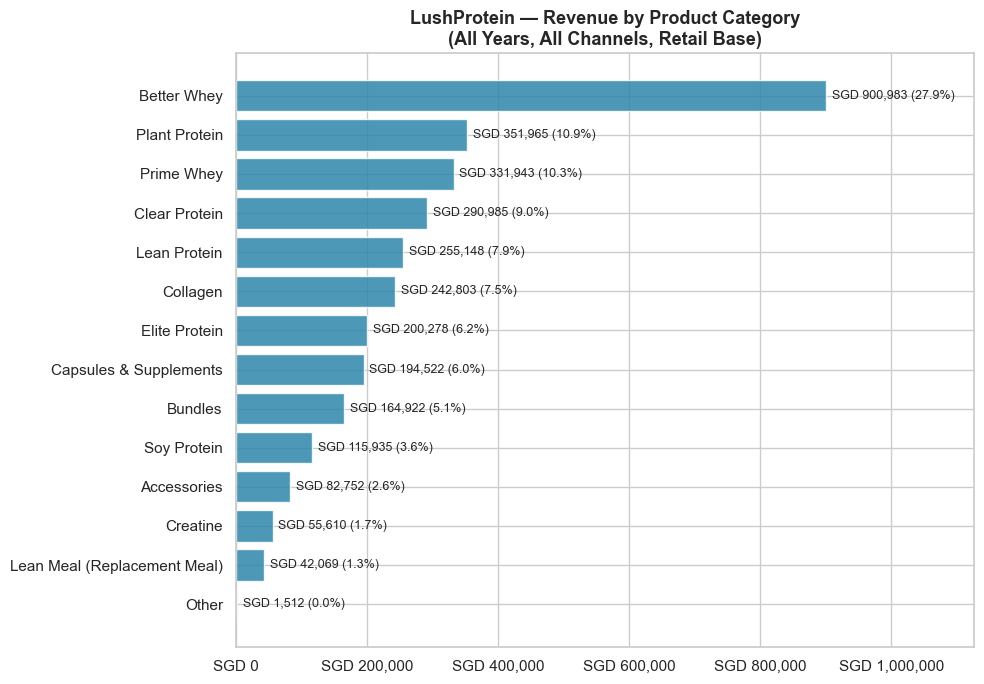

In [14]:
# ── Chart: Revenue by Category ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

cat_plot = category_total.sort_values('total_revenue', ascending=True)
bars = ax.barh(
    cat_plot['category'], cat_plot['total_revenue'],
    color=COLORS['primary'], alpha=0.85, edgecolor='white'
)
for bar, (_, row) in zip(bars, cat_plot.iterrows()):
    ax.text(
        bar.get_width() + cat_plot['total_revenue'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"SGD {row['total_revenue']:,.0f} ({row['pct_revenue']:.1%})",
        va='center', fontsize=9
    )

ax.set_title('LushProtein — Revenue by Product Category\n(All Years, All Channels, Retail Base)',
              fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
ax.set_xlim(0, cat_plot['total_revenue'].max() * 1.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_revenue_overall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Top 10 Categories - Revenue Trend by Year

In [15]:
# ── Revenue by Category × Year for top 10 categories ─────────────────────────
category_year = (
    so_retail[so_retail['category'].isin(top10_categories)]
    .groupby(['category', 'order_year'])
    .agg(
        revenue    =('line_revenue', 'sum'),
        qty        =('Line: Quantity', 'sum'),
        n_customers=('Customer: ID', 'nunique'),
    )
    .reset_index()
)

# Pivot for heatmap/table
category_year_pivot = category_year.pivot(
    index='category', columns='order_year', values='revenue'
).fillna(0)

# Sort rows by total revenue (descending) to match top10 order
category_year_pivot = category_year_pivot.loc[top10_categories]

# ── Build display table with value + YoY % change (color-coded) ─────────────
def pct_change_html(prev, curr):
    if prev == 0:
        if curr == 0:
            return '<span style="font-size:0.8em;color:gray;">(n/a)</span>'
        else:
            return '<span style="font-size:0.8em;color:green;">(new)</span>'
    pct = (curr - prev) / prev * 100
    color = 'green' if pct >= 0 else 'red'
    sign = '+' if pct >= 0 else ''
    return f'<span style="font-size:0.8em;color:{color};">({sign}{pct:.1f}%)</span>'

years_sorted = sorted(category_year_pivot.columns)
display_df = pd.DataFrame(index=category_year_pivot.index, columns=years_sorted, dtype=object)

for cat in category_year_pivot.index:
    for i, yr in enumerate(years_sorted):
        val = category_year_pivot.loc[cat, yr]
        cell_text = f'{val:,.0f}'
        if i > 0:
            prev_val = category_year_pivot.loc[cat, years_sorted[i-1]]
            cell_text += f'<br>{pct_change_html(prev_val, val)}'
        display_df.loc[cat, yr] = cell_text

print('Revenue by Category × Year, with YoY % change:')
display(
    display_df.style
    .set_caption('All values in SGD')
)

Revenue by Category × Year, with YoY % change:


,2019,2020,2021,2022,2023,2024,2025,2026
category,,,,,,,,
Better Whey,0,"139,686(new)","282,119(+102.0%)","335,963(+19.1%)","83,416(-75.2%)","44,455(-46.7%)","15,343(-65.5%)",0(-100.0%)
Plant Protein,0,"62,988(new)","117,881(+87.2%)","100,947(-14.4%)","16,087(-84.1%)","27,171(+68.9%)","23,603(-13.1%)","3,288(-86.1%)"
Prime Whey,0,"59,113(new)","107,717(+82.2%)","96,863(-10.1%)","39,124(-59.6%)","28,410(-27.4%)",715(-97.5%),0(-100.0%)
Clear Protein,0,0(n/a),0(n/a),0(n/a),"1,140(new)","82,807(+7164.6%)","166,654(+101.3%)","40,384(-75.8%)"
Lean Protein,0,0(n/a),0(n/a),0(n/a),0(n/a),"31,189(new)","166,259(+433.1%)","57,700(-65.3%)"
Collagen,0,0(n/a),"76,344(new)","75,233(-1.5%)","18,904(-74.9%)","28,451(+50.5%)","32,575(+14.5%)","11,297(-65.3%)"
Elite Protein,0,"7,661(new)","2,948(-61.5%)","37,087(+1157.9%)","7,307(-80.3%)","52,828(+623.0%)","51,388(-2.7%)","41,058(-20.1%)"
Capsules & Supplements,0,"56,953(new)","58,990(+3.6%)","39,767(-32.6%)","7,666(-80.7%)","10,983(+43.3%)","16,479(+50.0%)","3,683(-77.7%)"
Bundles,0,"81,491(new)","62,573(-23.2%)","10,118(-83.8%)",0(-100.0%),0(n/a),"7,470(new)","3,270(-56.2%)"


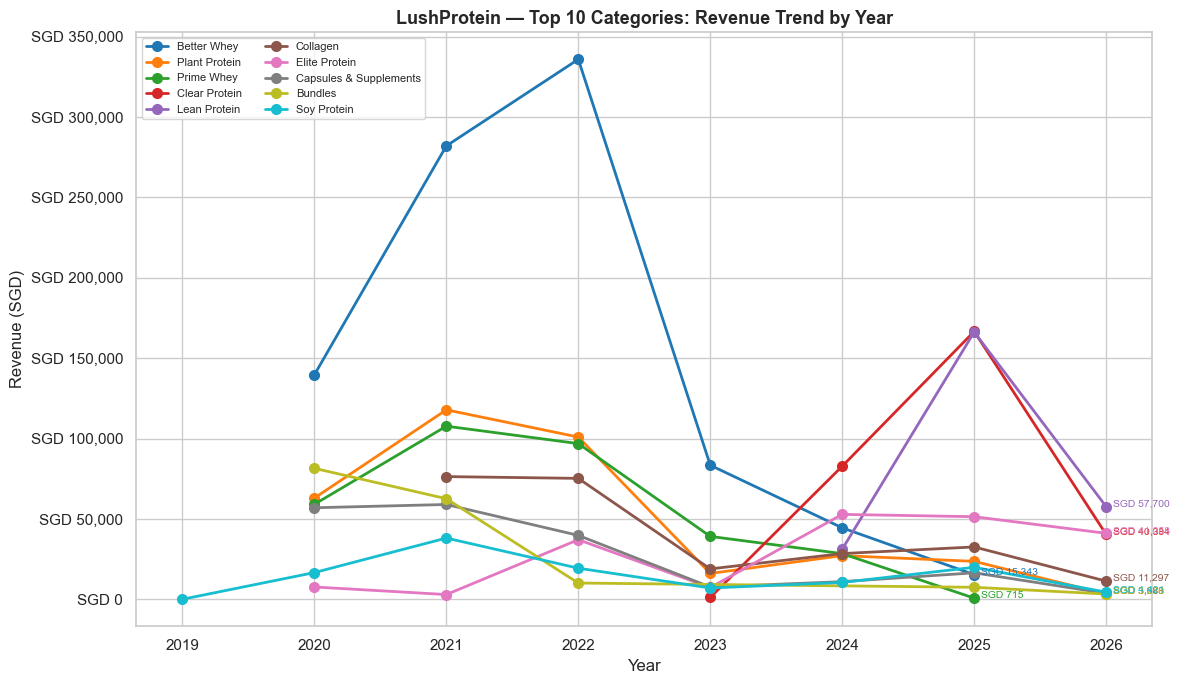

In [16]:
# ── Chart: Multi-line trend for top 10 categories ─────────────────────────────
years = sorted(category_year['order_year'].unique())
palette = sns.color_palette('tab10', len(top10_categories))

fig, ax1 = plt.subplots(figsize=(12, 7))

for i, cat in enumerate(top10_categories):
    sub = category_year[category_year['category'] == cat].sort_values('order_year')
    ax1.plot(
        sub['order_year'], sub['revenue'],
        marker='o', linewidth=2, markersize=7,
        label=cat, color=palette[i]
    )
    if len(sub) > 0:
        last = sub.iloc[-1]
        ax1.annotate(
            f"SGD {last['revenue']:,.0f}",
            xy=(last['order_year'], last['revenue']),
            xytext=(5, 0), textcoords='offset points',
            fontsize=7.5, color=palette[i]
        )

ax1.set_title('LushProtein — Top 10 Categories: Revenue Trend by Year',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
ax1.set_xticks(years)
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Check negative Line: Quantity by Line: Type (raw silver_orders) ──────────
print('Line: Quantity sign by Line: Type (all silver_orders):')
print(so.groupby('Line: Type')['Line: Quantity'].agg(
    n_negative = lambda x: (x < 0).sum(),
    n_positive = lambda x: (x > 0).sum(),
    n_zero     = lambda x: (x == 0).sum(),
    min_qty    = 'min',
    max_qty    = 'max'
).to_string())

# ── Check our so_retail (already filtered to Line Item only) ─────────────────
print(f'\nLine: Quantity in so_retail (Line Item only):')
print(f'Negative quantities: {(so_retail["Line: Quantity"] < 0).sum():,}')
print(f'Zero quantities: {(so_retail["Line: Quantity"] == 0).sum():,}')
print(f'Min: {so_retail["Line: Quantity"].min()}, Max: {so_retail["Line: Quantity"].max()}')

Line: Quantity sign by Line: Type (all silver_orders):
                  n_negative  n_positive  n_zero  min_qty  max_qty
Line: Type                                                        
Fulfillment Line       49920           0       0  -283.00    -1.00
Line Item                  0       51220       0     1.00   700.00
Refund Line             1138           0       0  -700.00    -1.00

Line: Quantity in so_retail (Line Item only):
Negative quantities: 0
Zero quantities: 0
Min: 1.0, Max: 283.0


In [18]:
# ── Quantify total refund amount ──────────────────────────────────────────────
refunds = so[
    so['Customer: ID'].isin(retail_customers) &
    (so['Line: Type'] == 'Refund Line')
].copy()

refunds['Line: Price']    = pd.to_numeric(refunds['Line: Price'], errors='coerce')
refunds['Line: Quantity'] = pd.to_numeric(refunds['Line: Quantity'], errors='coerce')
refunds['refund_amount']  = refunds['Line: Price'] * refunds['Line: Quantity'].abs()

print(f'Total refund line items: {len(refunds):,}')
print(f'Total refund amount: SGD {refunds["refund_amount"].sum():,.2f}')
print(f'Unique orders with refunds: {refunds["ID"].nunique():,}')

# As % of our analysis revenue (47,136 line items)
total_revenue = so_retail['line_revenue'].sum()
print(f'\nTotal revenue (Line Item, our analysis): SGD {total_revenue:,.2f}')
print(f'Refunds as % of total revenue: {refunds["refund_amount"].sum() / total_revenue:.2%}')

Total refund line items: 1,217
Total refund amount: SGD 71,733.97
Unique orders with refunds: 801

Total revenue (Line Item, our analysis): SGD 3,231,427.69
Refunds as % of total revenue: 2.22%


## Data Notes & Limitations — Refunds Not Netted Out

This analysis uses only `Line: Type == 'Line Item'` rows from `silver_orders` (47,094 line items, post-2019 exclusion and B2B account exclusion). Two other line types exist in the source data but are **excluded entirely**:

| Line: Type | Rows | Quantity Range | Description |
|---|---|---|---|
| Line Item | 51,220 | 1 to 700 (positive) | Actual ordered items — used in this analysis |
| Fulfillment Line | 49,920 | -1 to -283 (negative) | Fulfillment/shipment records, mirrors Line Item quantities |
| Refund Line | 1,138 | -1 to -700 (negative) | Returns/refunds |

**Implication:** Reported revenue figures represent **gross ordered amounts**, not net-of-refunds. Refunds total **SGD 71,734 across 1,217 line items (801 unique orders)** — equivalent to **2.22% of gross revenue (SGD 3,231,404)**. Reported category/SKU revenue figures are therefore overstated by approximately this margin.

#### Revenue Trend by Quarters

In [19]:
# ── Cost Map Setup (for margin trend analyses below) ─────────────────────────
sku_cost_map = (
    pm[pm['Cost per item'].notna()]
    .assign(sku_clean=lambda x: x['Variant SKU'].str.strip().str.upper())
    .set_index('sku_clean')['Cost per item']
    .to_dict()
)

bundle_map = {
    'CLEAR-GRA-500G-2BL-V2': ('CLEAR-GRA-500G-V2', 2),
    'CLEAR-GRA-500G-4BL-V2': ('CLEAR-GRA-500G-V2', 4),
    'CLEAR-PEA-500G-2BL-V2': ('CLEAR-PEA-500G-V2', 2),
    'CLEAR-PEA-500G-4BL-V2': ('CLEAR-PEA-500G-V2', 4),
    'COL-UNF-300G-2BL-V1': ('COL-UNF-300G-V1', 2),
    'COL-UNF-300G-4BL-V1': ('COL-UNF-300G-V1', 4),
    'CRE-UNF-250G-2BL-V1': ('CRE-UNF-250G-V1', 2),
    'CRE-UNF-250G-4BL-V1': ('CRE-UNF-250G-V1', 4),
    'LEAN-TAR-1KG-2BL-V1': ('LEAN-TAR-1KG-V1', 2),
    'LEAN-TAR-1KG-4BL-V1': ('LEAN-TAR-1KG-V1', 4),
    'LEAN-THA-1KG-2BL-V1': ('LEAN-THA-1KG-V1', 2),
    'LEAN-THA-1KG4BL-V1':  ('LEAN-THA-1KG-V1', 4),
    'SOY-UNF-1KG-2BL-V1': ('SOY-UNF-1KG-V1', 2),
    'SOY-UNF-1KG-4BL-V1': ('SOY-UNF-1KG-V1', 4),
}
for bundle_sku, (base_sku, mult) in bundle_map.items():
    if base_sku in sku_cost_map and bundle_sku not in sku_cost_map:
        sku_cost_map[bundle_sku] = sku_cost_map[base_sku] * mult

# ── Apply cost map to so_retail (so so_13q inherits cost columns) ─────────────
so_retail['unit_cost'] = so_retail['sku'].map(sku_cost_map)
so_retail['line_cost'] = so_retail['unit_cost'] * so_retail['Line: Quantity']

has_cost = so_retail['line_cost'].notna()
category_margin_proxy_global = (
    so_retail[has_cost]
    .groupby('category')
    .apply(lambda g: 1 - g['line_cost'].sum()/g['line_revenue'].sum())
)
overall_margin_global = 1 - so_retail.loc[has_cost,'line_cost'].sum() / so_retail.loc[has_cost,'line_revenue'].sum()

def _fill_cost(row):
    if pd.notna(row['line_cost']):
        return row['line_cost']
    proxy = category_margin_proxy_global.get(row['category'], overall_margin_global)
    if pd.isna(proxy):
        proxy = overall_margin_global
    return row['line_revenue'] * (1 - proxy)

so_retail['line_cost_final'] = so_retail.apply(_fill_cost, axis=1)
so_retail['gross_profit'] = so_retail['line_revenue'] - so_retail['line_cost_final']

print(f'Cost map entries: {len(sku_cost_map)}')
print(f'Rows with direct/bundle cost: {has_cost.sum():,} ({has_cost.sum()/len(so_retail):.1%})')

Cost map entries: 66
Rows with direct/bundle cost: 34,720 (73.7%)


Top 10 categories (2023 Q1 - 2026 Q1):
     category  total_revenue
Clear Protein     290,984.74
 Lean Protein     255,147.71
Elite Protein     152,581.66
  Better Whey     143,214.79
     Collagen      91,226.37
Plant Protein      70,149.53
   Prime Whey      68,249.00
     Creatine      43,796.24
  Soy Protein      41,839.26
  Accessories      41,549.35

Quarters: ['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']
Total quarters: 13


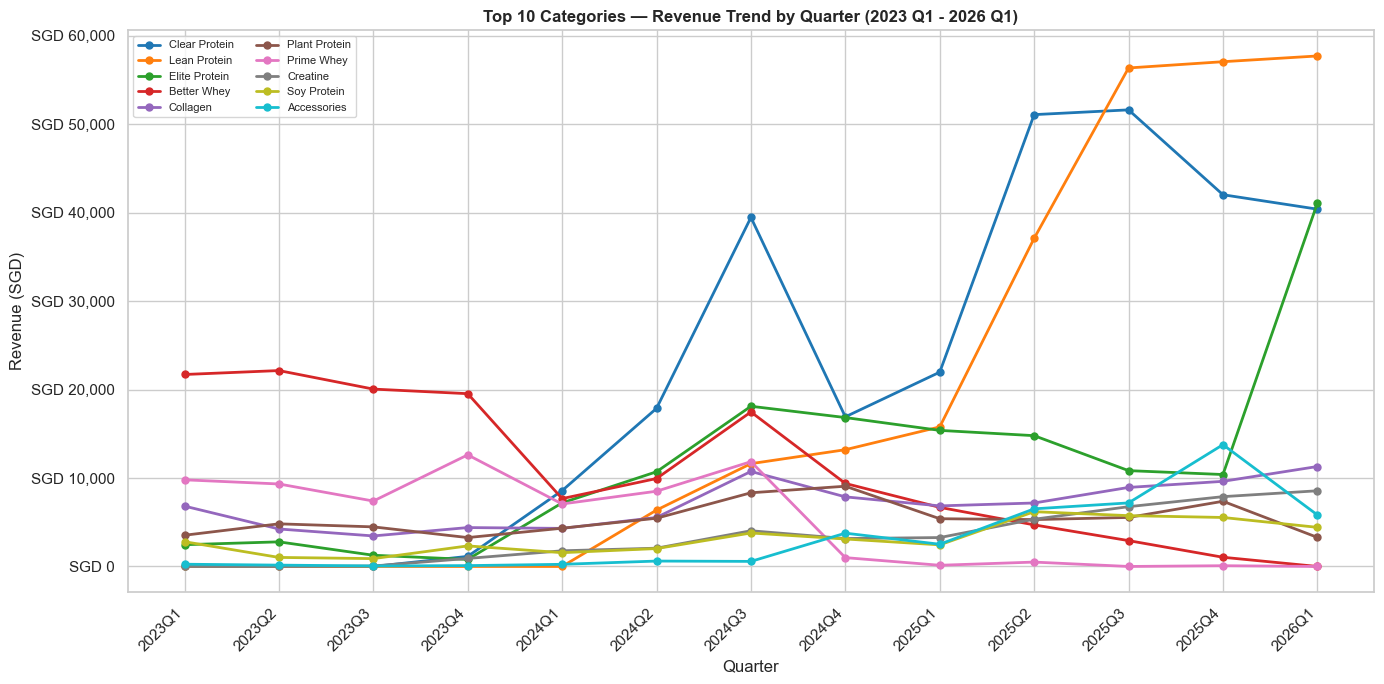

In [20]:
# ── Top 10 Categories Revenue Trend by Quarter (2023 Q1 - 2026 Q1, 13 quarters) ──
so_13q = so_retail[
    ((so_retail['order_year'] == 2023)) |
    ((so_retail['order_year'] == 2024)) |
    ((so_retail['order_year'] == 2025)) |
    ((so_retail['order_year'] == 2026))
].copy()
so_13q['year_quarter'] = so_13q['Processed At'].dt.to_period('Q').astype(str)

# Recompute top 10 categories for this 13-quarter window
category_total_13q = (
    so_13q.groupby('category')
    .agg(total_revenue=('line_revenue', 'sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
top10_categories_13q = category_total_13q.head(10)['category'].tolist()

print('Top 10 categories (2023 Q1 - 2026 Q1):')
print(category_total_13q.head(10).to_string(index=False))

# Quarterly revenue by category
category_quarter = (
    so_13q[so_13q['category'].isin(top10_categories_13q)]
    .groupby(['category', 'year_quarter'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

category_quarter_pivot = category_quarter.pivot(
    index='category', columns='year_quarter', values='revenue'
).fillna(0)
category_quarter_pivot = category_quarter_pivot.loc[top10_categories_13q]

quarters_sorted = sorted(category_quarter_pivot.columns)
category_quarter_pivot = category_quarter_pivot[quarters_sorted]

print(f'\nQuarters: {quarters_sorted}')
print(f'Total quarters: {len(quarters_sorted)}')

# ── Chart: Multi-line quarterly trend for top 10 categories ─────────────────
palette = sns.color_palette('tab10', len(top10_categories_13q))
fig, ax1 = plt.subplots(figsize=(14, 7))

for i, cat in enumerate(top10_categories_13q):
    values = category_quarter_pivot.loc[cat]
    ax1.plot(quarters_sorted, values.values, marker='o', linewidth=2, markersize=5, label=cat, color=palette[i])

ax1.set_title('Top 10 Categories — Revenue Trend by Quarter (2023 Q1 - 2026 Q1)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
plt.xticks(rotation=45, ha='right')
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_revenue_trend_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


Top 10 Categories — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1):


year_quarter,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
category,,,,,,,,,,,,,
Clear Protein,0.0%,0.0%,0.0%,54.8%,67.2%,67.2%,67.9%,71.6%,72.4%,73.8%,75.9%,72.7%,72.6%
Lean Protein,0.0%,0.0%,0.0%,0.0%,0.0%,63.5%,66.1%,68.5%,66.9%,68.2%,73.0%,67.2%,68.3%
Elite Protein,69.1%,65.4%,58.0%,52.4%,47.5%,49.6%,52.6%,53.6%,62.0%,59.4%,68.2%,74.1%,74.1%
Better Whey,56.9%,58.3%,51.8%,52.1%,50.6%,54.1%,55.5%,57.7%,61.5%,60.9%,63.2%,53.4%,0.0%
Collagen,63.8%,60.8%,60.5%,60.3%,61.7%,60.4%,62.8%,65.9%,67.1%,68.0%,75.1%,71.5%,74.2%
Plant Protein,79.1%,78.1%,78.0%,77.2%,75.8%,76.5%,77.2%,77.4%,76.9%,77.4%,77.5%,77.9%,78.8%
Prime Whey,54.8%,55.3%,51.5%,51.8%,46.5%,47.2%,52.8%,48.2%,52.0%,41.3%,0.0%,61.8%,0.0%
Creatine,0.0%,0.0%,71.1%,75.4%,75.4%,79.6%,77.3%,80.4%,79.2%,81.1%,81.1%,80.1%,79.4%
Soy Protein,86.5%,85.6%,83.9%,85.4%,84.4%,85.6%,86.0%,86.2%,86.7%,87.8%,88.5%,86.0%,86.0%


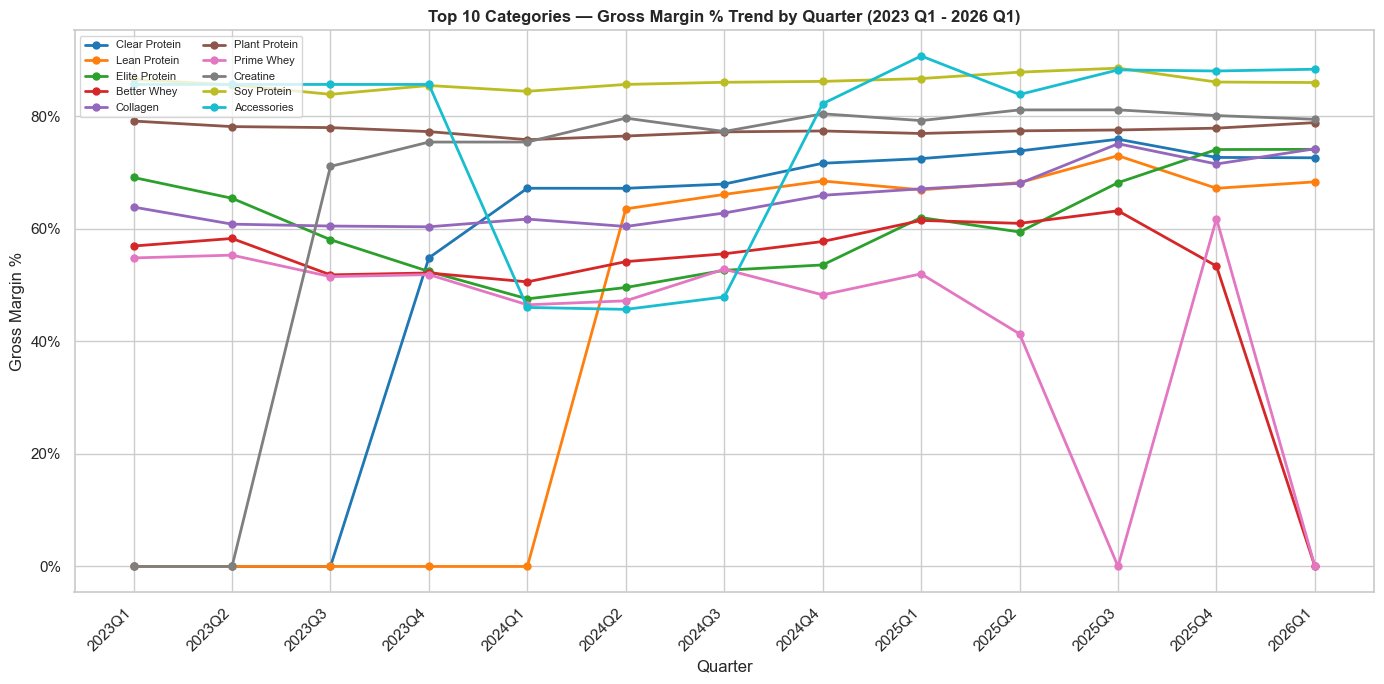

In [21]:
# ── Top 10 Categories Margin Trend by Quarter (2023 Q1 - 2026 Q1) ─────────────
category_quarter_margin = (
    so_13q[so_13q['category'].isin(top10_categories_13q)]
    .groupby(['category', 'year_quarter'])
    .agg(revenue=('line_revenue', 'sum'), cost=('line_cost_final', 'sum'))
    .reset_index()
)
category_quarter_margin['margin'] = (
    (category_quarter_margin['revenue'] - category_quarter_margin['cost'])
    / category_quarter_margin['revenue']
)

category_quarter_margin_pivot = category_quarter_margin.pivot(
    index='category', columns='year_quarter', values='margin'
).fillna(0)
category_quarter_margin_pivot = category_quarter_margin_pivot.loc[top10_categories_13q]
category_quarter_margin_pivot = category_quarter_margin_pivot[quarters_sorted]

print('Top 10 Categories — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1):')
display(category_quarter_margin_pivot.style.format('{:.1%}'))

# ── Chart: Multi-line quarterly margin trend for top 10 categories ───────────
palette = sns.color_palette('tab10', len(top10_categories_13q))
fig, ax1 = plt.subplots(figsize=(14, 7))

for i, cat in enumerate(top10_categories_13q):
    values = category_quarter_margin_pivot.loc[cat]
    ax1.plot(quarters_sorted, values.values, marker='o', linewidth=2, markersize=5, label=cat, color=palette[i])

ax1.set_title('Top 10 Categories — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Gross Margin %')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xticks(rotation=45, ha='right')
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_margin_trend_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Top 10 SKUs — Revenue Trend by Year

In [22]:
# ── Aggregate revenue by full SKU only (excludes category-fallback codes) ────
sku_total = (
    so_retail[so_retail['sku'].str.contains('-', na=False)]
    .groupby('sku')
    .agg(
        total_revenue  =('line_revenue', 'sum'),
        total_qty      =('Line: Quantity', 'sum'),
        n_orders       =('ID', 'nunique'),
        n_customers    =('Customer: ID', 'nunique'),
        avg_unit_price =('Line: Price', 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

sku_total['pct_revenue'] = sku_total['total_revenue'] / sku_total['total_revenue'].sum()

top10_skus = sku_total.head(10)['sku'].tolist()

print(f'Total full SKUs: {len(sku_total):,}')
print(f'\nTop 10 SKUs by total revenue:')
display(
    sku_total.head(10)[['sku','total_revenue','pct_revenue','total_qty','n_orders','n_customers','avg_unit_price']]
    .style.format({
        'total_revenue' : 'SGD {:,.0f}',
        'pct_revenue'   : '{:.1%}',
        'total_qty'     : '{:,.0f}',
        'n_orders'      : '{:,.0f}',
        'n_customers'   : '{:,.0f}',
        'avg_unit_price': 'SGD {:,.2f}',
    })
)

# ── Revenue by SKU × Year for top 10 SKUs ────────────────────────────────────
sku_year = (
    so_retail[so_retail['sku'].isin(top10_skus)]
    .groupby(['sku', 'order_year'])
    .agg(
        revenue    =('line_revenue', 'sum'),
        qty        =('Line: Quantity', 'sum'),
        n_customers=('Customer: ID', 'nunique'),
    )
    .reset_index()
)

# Pivot for heatmap
sku_year_pivot = sku_year.pivot(
    index='sku', columns='order_year', values='revenue'
).fillna(0)

# Sort rows by total revenue (descending) to match top10 order
sku_year_pivot = sku_year_pivot.loc[top10_skus]

# ── Build display table with value + YoY % change (color-coded) ─────────────
def pct_change_html(prev, curr):
    if prev == 0:
        if curr == 0:
            return '<span style="font-size:0.8em;color:gray;">(n/a)</span>'
        else:
            return '<span style="font-size:0.8em;color:green;">(new)</span>'
    pct = (curr - prev) / prev * 100
    color = 'green' if pct >= 0 else 'red'
    sign = '+' if pct >= 0 else ''
    return f'<span style="font-size:0.8em;color:{color};">({sign}{pct:.1f}%)</span>'

years_sorted = sorted(sku_year_pivot.columns)
display_df = pd.DataFrame(index=sku_year_pivot.index, columns=years_sorted, dtype=object)

for sku in sku_year_pivot.index:
    for i, yr in enumerate(years_sorted):
        val = sku_year_pivot.loc[sku, yr]
        cell_text = f'{val:,.0f}'
        if i > 0:
            prev_val = sku_year_pivot.loc[sku, years_sorted[i-1]]
            cell_text += f'<br>{pct_change_html(prev_val, val)}'
        display_df.loc[sku, yr] = cell_text

print('Revenue by SKU × Year, with YoY % change:')
display(
    display_df.style
    .set_caption('All values in SGD')
)

Total full SKUs: 70

Top 10 SKUs by total revenue:


,sku,total_revenue,pct_revenue,total_qty,n_orders,n_customers,avg_unit_price
15,BET-UNF-1KG-V1,"SGD 542,694",21.5%,"8,740","4,299","2,360",SGD 44.08
63,PLT-CHO-480G-V1,"SGD 329,439",13.1%,"7,957","3,786","2,289",SGD 26.11
66,PRI-UNF-1KG-V1,"SGD 311,967",12.4%,"3,095","1,661",815,SGD 76.09
36,COL-UNF-300G-V1,"SGD 238,199",9.4%,"5,268","2,916","1,526",SGD 37.64
31,CLEAR-PEA-500G-V2,"SGD 156,171",6.2%,"2,347","1,806","1,307",SGD 66.93
42,ELT-CHO-1KG-V1,"SGD 150,298",6.0%,"2,097",988,624,SGD 59.51
69,SOY-UNF-1KG-V1,"SGD 114,110",4.5%,"2,543","1,501",976,SGD 36.69
57,LEAN-THA-1KG-V1,"SGD 106,587",4.2%,"1,932","1,582","1,088",SGD 55.08
26,CLEAR-GRA-500G-V2,"SGD 102,624",4.1%,"1,616","1,319",999,SGD 63.31
51,LEAN-TAR-1KG-V1,"SGD 92,959",3.7%,"1,620","1,185",852,SGD 59.09


Revenue by SKU × Year, with YoY % change:


,2019,2020,2021,2022,2023,2024,2025,2026
sku,,,,,,,,
BET-UNF-1KG-V1,0,0(n/a),"65,079(new)","334,570(+414.1%)","83,416(-75.1%)","44,285(-46.9%)","15,343(-65.4%)",0(-100.0%)
PLT-CHO-480G-V1,0,"62,988(new)","117,881(+87.2%)","96,673(-18.0%)","16,087(-83.4%)","19,346(+20.3%)","13,784(-28.7%)","2,681(-80.6%)"
PRI-UNF-1KG-V1,0,"59,113(new)","107,717(+82.2%)","87,851(-18.4%)","39,124(-55.5%)","17,770(-54.6%)",391(-97.8%),0(-100.0%)
COL-UNF-300G-V1,0,0(n/a),"76,344(new)","75,233(-1.5%)","18,904(-74.9%)","28,451(+50.5%)","29,192(+2.6%)","10,075(-65.5%)"
CLEAR-PEA-500G-V2,0,0(n/a),0(n/a),0(n/a),"1,140(new)","45,280(+3872.4%)","88,565(+95.6%)","21,187(-76.1%)"
ELT-CHO-1KG-V1,0,0(n/a),0(n/a),"29,797(new)","7,307(-75.5%)","37,423(+412.1%)","41,688(+11.4%)","34,083(-18.2%)"
SOY-UNF-1KG-V1,24,"16,623(+69162.2%)","38,106(+129.2%)","19,342(-49.2%)","7,032(-63.6%)","10,471(+48.9%)","18,557(+77.2%)","3,955(-78.7%)"
LEAN-THA-1KG-V1,0,0(n/a),0(n/a),0(n/a),0(n/a),"27,316(new)","56,662(+107.4%)","22,609(-60.1%)"
CLEAR-GRA-500G-V2,0,0(n/a),0(n/a),0(n/a),0(n/a),"37,527(new)","50,810(+35.4%)","14,287(-71.9%)"


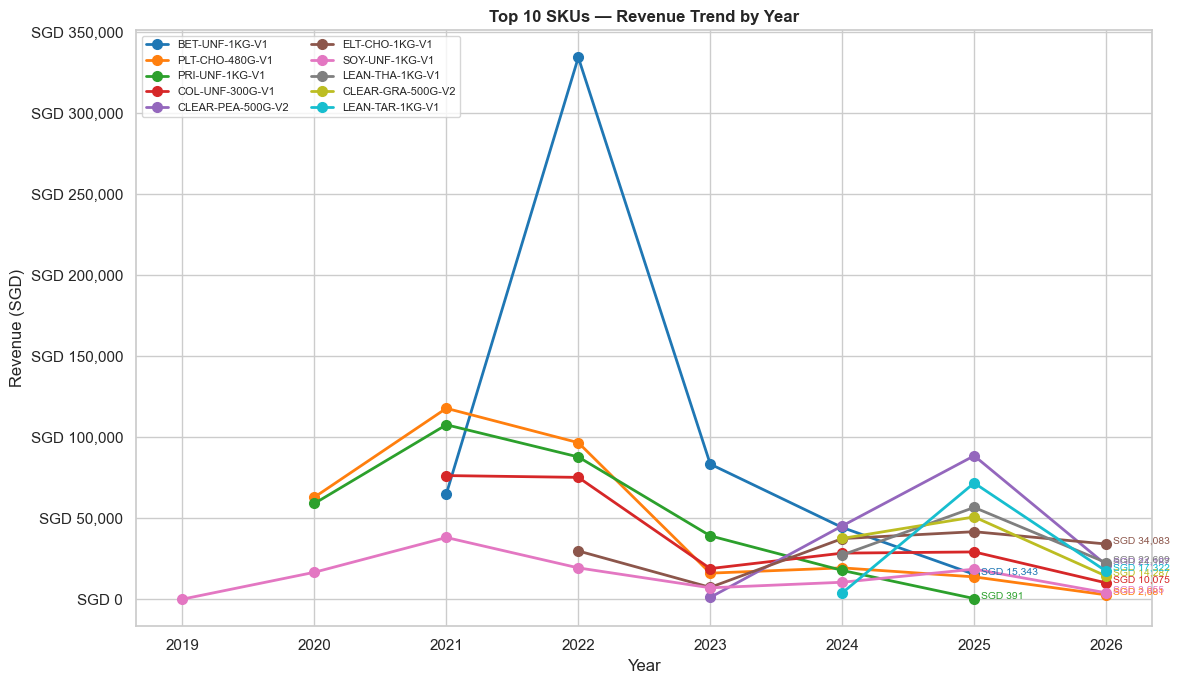

In [23]:
# ── Chart: Multi-line trend for top 10 SKUs ───────────────────────────────────
years = sorted(sku_year['order_year'].unique())
palette = sns.color_palette('tab10', TOP_N)

fig, ax1 = plt.subplots(figsize=(12, 7))

for i, sku in enumerate(top10_skus):
    sub = sku_year[sku_year['sku'] == sku].sort_values('order_year')
    ax1.plot(
        sub['order_year'], sub['revenue'],
        marker='o', linewidth=2, markersize=7,
        label=sku, color=palette[i]
    )
    if len(sub) > 0:
        last = sub.iloc[-1]
        ax1.annotate(
            f"SGD {last['revenue']:,.0f}",
            xy=(last['order_year'], last['revenue']),
            xytext=(5, 0), textcoords='offset points',
            fontsize=7.5, color=palette[i]
        )

ax1.set_title(f'Top {TOP_N} SKUs — Revenue Trend by Year',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
ax1.set_xticks(years)
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sku_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Focus the analysis from 2023 onwards to 2025, as Clear Protein (one of the Hero products) started from 2023.

Total full SKUs (2023-2025): 66

Top 10 SKUs by total revenue (2023-2025):


,sku,total_revenue,pct_revenue,total_qty,n_orders,n_customers,avg_unit_price
13,BET-UNF-1KG-V1,"SGD 143,045",13.4%,"3,014","1,798",997,SGD 47.72
29,CLEAR-PEA-500G-V2,"SGD 134,984",12.7%,"2,028","1,561","1,120",SGD 67.04
24,CLEAR-GRA-500G-V2,"SGD 88,337",8.3%,"1,404","1,141",872,SGD 62.71
40,ELT-CHO-1KG-V1,"SGD 86,418",8.1%,"1,394",765,460,SGD 56.15
54,LEAN-THA-1KG-V1,"SGD 83,978",7.9%,"1,527","1,263",873,SGD 54.85
34,COL-UNF-300G-V1,"SGD 76,547",7.2%,"2,224","1,419",712,SGD 35.51
48,LEAN-TAR-1KG-V1,"SGD 75,637",7.1%,"1,290",957,709,SGD 60.03
62,PRI-UNF-1KG-V1,"SGD 57,286",5.4%,856,498,225,SGD 67.11
59,PLT-CHO-480G-V1,"SGD 49,217",4.6%,"1,786",837,488,SGD 27.94
65,SOY-UNF-1KG-V1,"SGD 36,060",3.4%,"1,109",748,474,SGD 32.99



Revenue by SKU × Year (2023-2025), with YoY % change:


,2023,2024,2025
sku,,,
BET-UNF-1KG-V1,"83,416","44,285(-46.9%)","15,343(-65.4%)"
CLEAR-PEA-500G-V2,"1,140","45,280(+3872.4%)","88,565(+95.6%)"
CLEAR-GRA-500G-V2,0,"37,527(new)","50,810(+35.4%)"
ELT-CHO-1KG-V1,"7,307","37,423(+412.1%)","41,688(+11.4%)"
LEAN-THA-1KG-V1,0,"27,316(new)","56,662(+107.4%)"
COL-UNF-300G-V1,"18,904","28,451(+50.5%)","29,192(+2.6%)"
LEAN-TAR-1KG-V1,0,"3,873(new)","71,764(+1752.8%)"
PRI-UNF-1KG-V1,"39,124","17,770(-54.6%)",391(-97.8%)
PLT-CHO-480G-V1,"16,087","19,346(+20.3%)","13,784(-28.7%)"


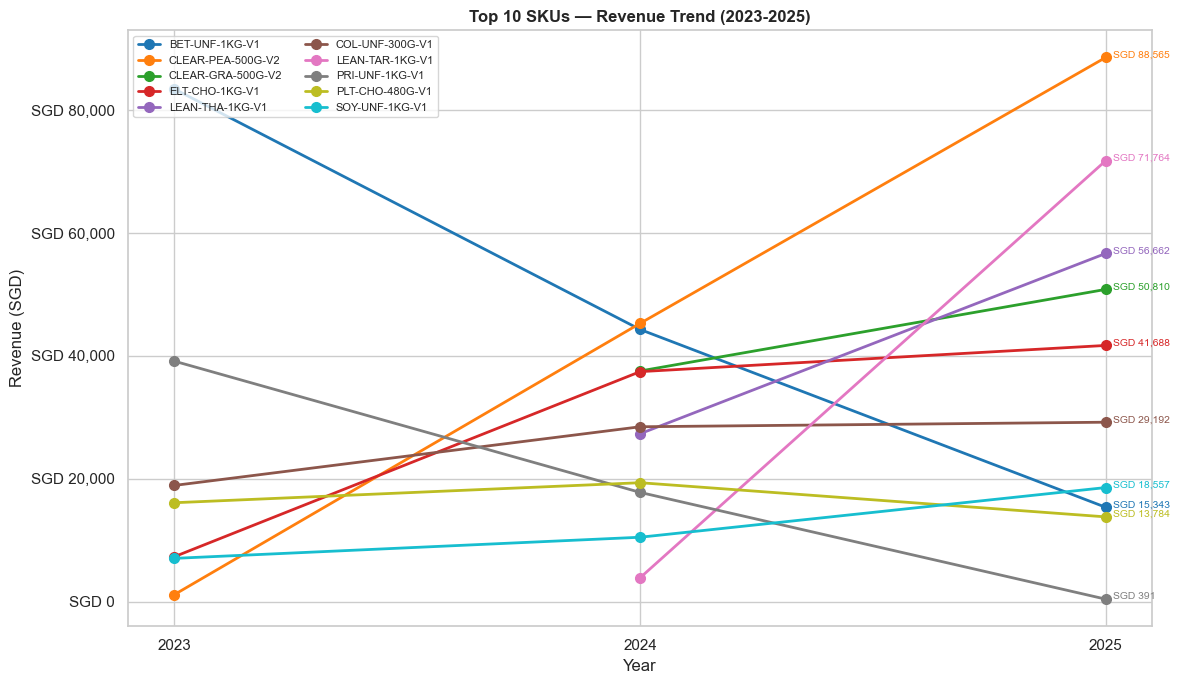

In [24]:
# ── SKU-level analysis: 2023-2025 only ────────────────────────────────────────
so_recent = so_retail[so_retail['order_year'].isin([2023, 2024, 2025])]

# Top SKUs by total revenue (2023-2025), full SKUs only
sku_total_recent = (
    so_recent[so_recent['sku'].str.contains('-', na=False)]
    .groupby('sku')
    .agg(
        total_revenue  =('line_revenue', 'sum'),
        total_qty      =('Line: Quantity', 'sum'),
        n_orders       =('ID', 'nunique'),
        n_customers    =('Customer: ID', 'nunique'),
        avg_unit_price =('Line: Price', 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
sku_total_recent['pct_revenue'] = sku_total_recent['total_revenue'] / sku_total_recent['total_revenue'].sum()

top10_skus_recent = sku_total_recent.head(10)['sku'].tolist()

print(f'Total full SKUs (2023-2025): {len(sku_total_recent):,}')
print(f'\nTop 10 SKUs by total revenue (2023-2025):')
display(
    sku_total_recent.head(10)[['sku','total_revenue','pct_revenue','total_qty','n_orders','n_customers','avg_unit_price']]
    .style.format({
        'total_revenue' : 'SGD {:,.0f}',
        'pct_revenue'   : '{:.1%}',
        'total_qty'     : '{:,.0f}',
        'n_orders'      : '{:,.0f}',
        'n_customers'   : '{:,.0f}',
        'avg_unit_price': 'SGD {:,.2f}',
    })
)

# ── Revenue by SKU × Year (2023-2025) for top 10 SKUs ────────────────────────
sku_year_recent = (
    so_recent[so_recent['sku'].isin(top10_skus_recent)]
    .groupby(['sku', 'order_year'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

sku_year_pivot_recent = sku_year_recent.pivot(
    index='sku', columns='order_year', values='revenue'
).fillna(0)
sku_year_pivot_recent = sku_year_pivot_recent.loc[top10_skus_recent]

# ── Display table with value + YoY % change ──────────────────────────────────
def pct_change_html(prev, curr):
    if prev == 0:
        return '<span style="font-size:0.8em;color:gray;">(n/a)</span>' if curr == 0 else '<span style="font-size:0.8em;color:green;">(new)</span>'
    pct = (curr - prev) / prev * 100
    color = 'green' if pct >= 0 else 'red'
    sign = '+' if pct >= 0 else ''
    return f'<span style="font-size:0.8em;color:{color};">({sign}{pct:.1f}%)</span>'

years_recent = sorted(sku_year_pivot_recent.columns)
display_df_recent = pd.DataFrame(index=sku_year_pivot_recent.index, columns=years_recent, dtype=object)

for sku in sku_year_pivot_recent.index:
    for i, yr in enumerate(years_recent):
        val = sku_year_pivot_recent.loc[sku, yr]
        cell_text = f'{val:,.0f}'
        if i > 0:
            prev_val = sku_year_pivot_recent.loc[sku, years_recent[i-1]]
            cell_text += f'<br>{pct_change_html(prev_val, val)}'
        display_df_recent.loc[sku, yr] = cell_text

print('\nRevenue by SKU × Year (2023-2025), with YoY % change:')
display(display_df_recent.style.set_caption('All values in SGD'))

# ── Chart: Multi-line trend (2023-2025) ──────────────────────────────────────
palette = sns.color_palette('tab10', len(top10_skus_recent))
fig, ax1 = plt.subplots(figsize=(12, 7))

for i, sku in enumerate(top10_skus_recent):
    sub = sku_year_recent[sku_year_recent['sku'] == sku].sort_values('order_year')
    ax1.plot(sub['order_year'], sub['revenue'], marker='o', linewidth=2, markersize=7, label=sku, color=palette[i])
    if len(sub) > 0:
        last = sub.iloc[-1]
        ax1.annotate(f"SGD {last['revenue']:,.0f}", xy=(last['order_year'], last['revenue']),
                      xytext=(5, 0), textcoords='offset points', fontsize=7.5, color=palette[i])

ax1.set_title('Top 10 SKUs — Revenue Trend (2023-2025)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
ax1.set_xticks(years_recent)
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sku_revenue_trend_2023_2025.png', dpi=150, bbox_inches='tight')
plt.show()

#### Revenue Trend by Quarters

Top 10 SKUs (2023 Q1 - 2026 Q1):
              sku  total_revenue
CLEAR-PEA-500G-V2     156,171.29
   BET-UNF-1KG-V1     143,045.09
   ELT-CHO-1KG-V1     120,501.06
  LEAN-THA-1KG-V1     106,587.05
CLEAR-GRA-500G-V2     102,623.95
  LEAN-TAR-1KG-V1      92,959.38
  COL-UNF-300G-V1      86,621.93
   PRI-UNF-1KG-V1      57,285.51
  PLT-CHO-480G-V1      51,897.61
   SOY-UNF-1KG-V1      40,014.59

Quarters: ['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']


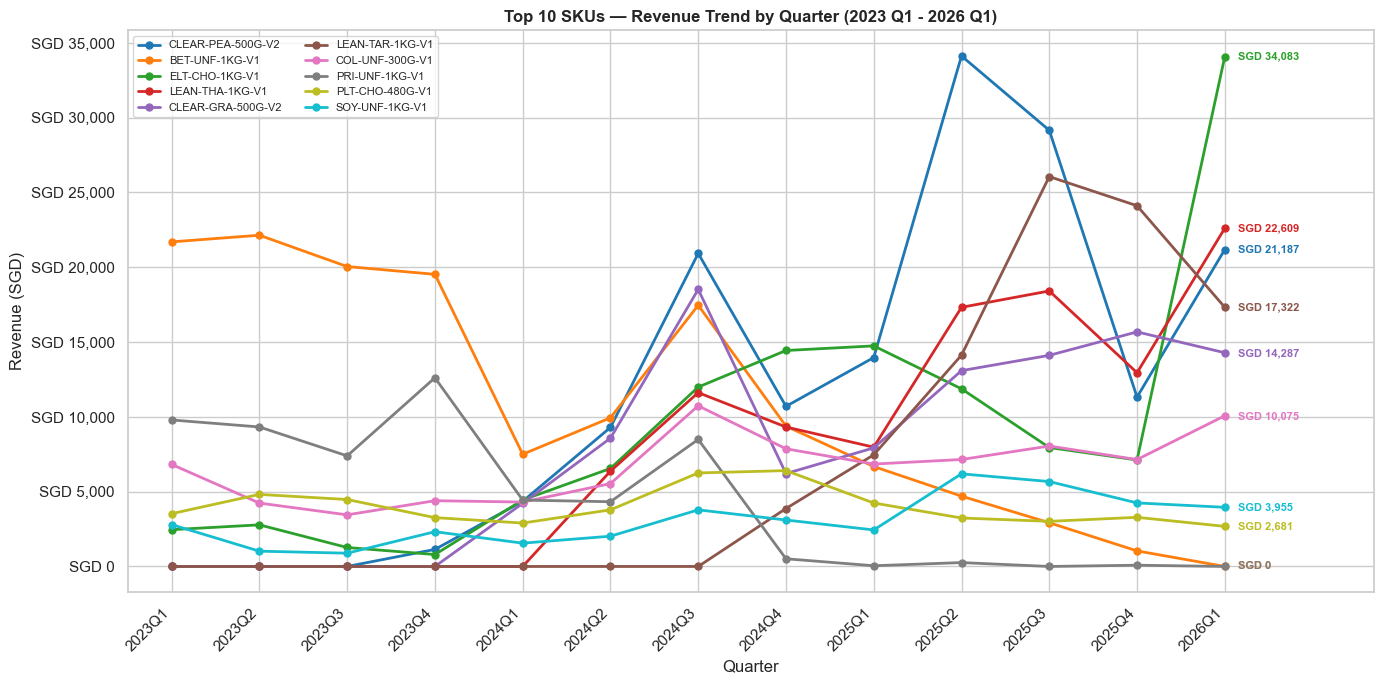

In [25]:
# ── Top 10 SKUs Revenue Trend by Quarter (2023 Q1 - 2026 Q1, 13 quarters) ──────
# Recompute top 10 SKUs for this 13-quarter window (full SKUs only)
sku_total_13q = (
    so_13q[so_13q['sku'].str.contains('-', na=False)]
    .groupby('sku')
    .agg(total_revenue=('line_revenue', 'sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
top10_skus_13q = sku_total_13q.head(10)['sku'].tolist()

print('Top 10 SKUs (2023 Q1 - 2026 Q1):')
print(sku_total_13q.head(10).to_string(index=False))

# Quarterly revenue by SKU
sku_quarter = (
    so_13q[so_13q['sku'].isin(top10_skus_13q)]
    .groupby(['sku', 'year_quarter'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

sku_quarter_pivot = sku_quarter.pivot(
    index='sku', columns='year_quarter', values='revenue'
).fillna(0)
sku_quarter_pivot = sku_quarter_pivot.loc[top10_skus_13q]
sku_quarter_pivot = sku_quarter_pivot[quarters_sorted]

print(f'\nQuarters: {quarters_sorted}')

# ── Chart: Multi-line quarterly trend for top 10 SKUs ────────────────────────
palette = sns.color_palette('tab10', len(top10_skus_13q))
fig, ax1 = plt.subplots(figsize=(14, 7))

# Define target quarter and find its horizontal index position
target_quarter = '2026Q1'
x_idx = quarters_sorted.index(target_quarter)

for i, sku in enumerate(top10_skus_13q):
    values = sku_quarter_pivot.loc[sku]
    ax1.plot(quarters_sorted, values.values, marker='o', linewidth=2, markersize=5, label=sku, color=palette[i])
    
    # 1. Get the revenue value for the target quarter
    y_val = values[target_quarter]
    
    # 2. Annotate the value next to the marker
    ax1.text(
        x_idx + 0.15,  # Shift text slightly to the right of the point
        y_val, 
        f'SGD {y_val:,.0f}', 
        fontsize=8, 
        fontweight='bold', 
        color=palette[i], 
        va='center'
    )

ax1.set_title('Top 10 SKUs — Revenue Trend by Quarter (2023 Q1 - 2026 Q1)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))

# 3. Extend the right margin of the x-axis so the labels aren't clipped
ax1.set_xlim(-0.5, len(quarters_sorted) - 0.5 + 1.2)

plt.xticks(rotation=45, ha='right')
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sku_revenue_trend_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 SKUs — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1):


year_quarter,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
sku,,,,,,,,,,,,,
CLEAR-PEA-500G-V2,0.0%,0.0%,0.0%,54.8%,67.0%,67.0%,68.1%,71.8%,72.5%,73.7%,77.4%,71.9%,72.3%
BET-UNF-1KG-V1,56.9%,58.3%,51.8%,52.1%,50.2%,54.1%,55.5%,57.7%,61.5%,60.9%,63.2%,53.4%,0.0%
ELT-CHO-1KG-V1,69.1%,65.4%,58.0%,52.4%,47.0%,50.9%,52.0%,53.5%,62.7%,59.3%,68.8%,74.4%,74.3%
LEAN-THA-1KG-V1,0.0%,0.0%,0.0%,0.0%,0.0%,63.5%,66.1%,67.9%,66.7%,67.1%,67.8%,67.7%,67.5%
CLEAR-GRA-500G-V2,0.0%,0.0%,0.0%,0.0%,67.3%,67.4%,67.7%,71.3%,72.4%,72.7%,72.5%,72.9%,72.7%
LEAN-TAR-1KG-V1,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,69.9%,66.7%,65.8%,73.8%,69.1%,66.4%
COL-UNF-300G-V1,63.8%,60.8%,60.5%,60.3%,61.7%,60.4%,62.8%,65.9%,67.1%,68.0%,74.2%,71.9%,74.6%
PRI-UNF-1KG-V1,54.8%,55.3%,51.5%,51.8%,44.7%,44.7%,52.8%,43.5%,31.6%,25.3%,0.0%,61.8%,0.0%
PLT-CHO-480G-V1,79.1%,78.1%,78.0%,77.2%,76.5%,77.3%,77.6%,77.9%,77.5%,78.2%,78.4%,79.1%,79.3%


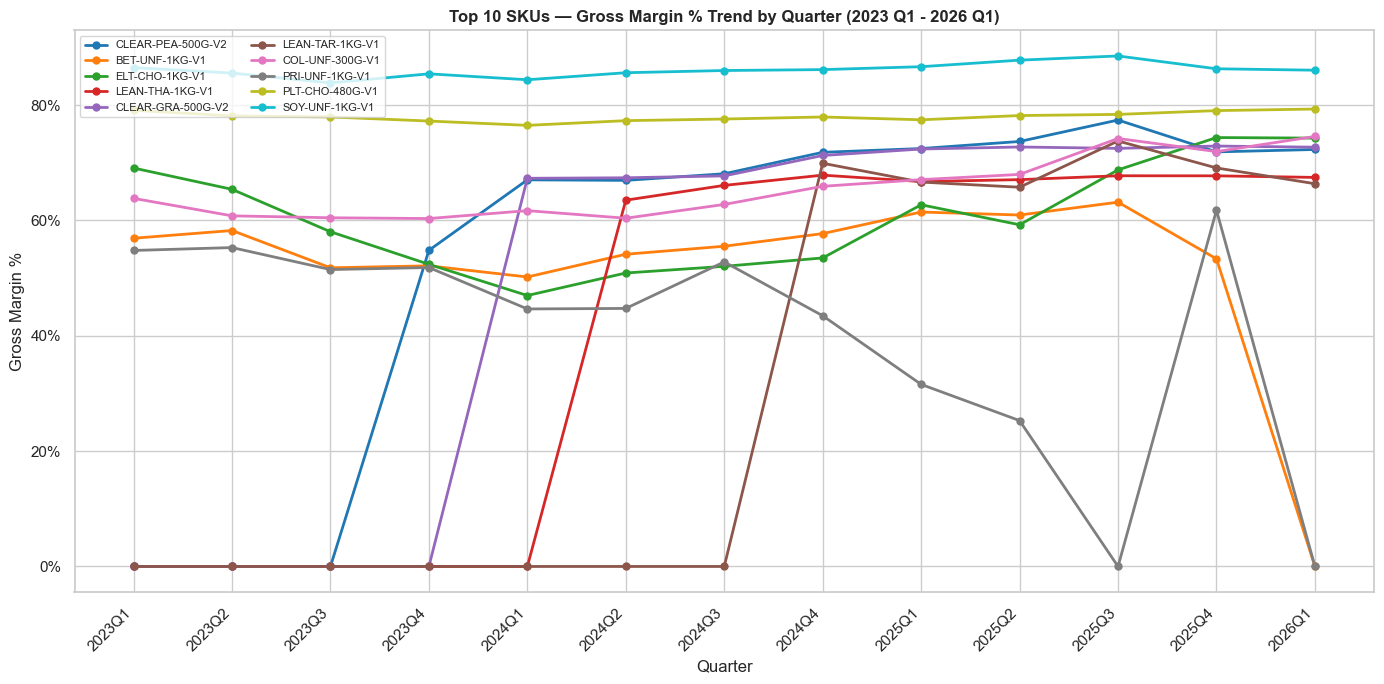

In [26]:
# ── Top 10 SKUs Margin Trend by Quarter (2023 Q1 - 2026 Q1) ───────────────────
sku_quarter_margin = (
    so_13q[so_13q['sku'].isin(top10_skus_13q)]
    .groupby(['sku', 'year_quarter'])
    .agg(revenue=('line_revenue', 'sum'), cost=('line_cost_final', 'sum'))
    .reset_index()
)
sku_quarter_margin['margin'] = (
    (sku_quarter_margin['revenue'] - sku_quarter_margin['cost'])
    / sku_quarter_margin['revenue']
)

sku_quarter_margin_pivot = sku_quarter_margin.pivot(
    index='sku', columns='year_quarter', values='margin'
).fillna(0)
sku_quarter_margin_pivot = sku_quarter_margin_pivot.loc[top10_skus_13q]
sku_quarter_margin_pivot = sku_quarter_margin_pivot[quarters_sorted]

print('Top 10 SKUs — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1):')
display(sku_quarter_margin_pivot.style.format('{:.1%}'))

# ── Chart: Multi-line quarterly margin trend for top 10 SKUs ─────────────────
palette = sns.color_palette('tab10', len(top10_skus_13q))
fig, ax1 = plt.subplots(figsize=(14, 7))

for i, sku in enumerate(top10_skus_13q):
    values = sku_quarter_margin_pivot.loc[sku]
    ax1.plot(quarters_sorted, values.values, marker='o', linewidth=2, markersize=5, label=sku, color=palette[i])

ax1.set_title('Top 10 SKUs — Gross Margin % Trend by Quarter (2023 Q1 - 2026 Q1)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Gross Margin %')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xticks(rotation=45, ha='right')
ax1.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sku_margin_trend_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── Step 1: Direct cost map from product master ──────────────────────────────
sku_cost_map = (
    pm[pm['Cost per item'].notna()]
    .assign(sku_clean=lambda x: x['Variant SKU'].str.strip().str.upper())
    .set_index('sku_clean')['Cost per item']
    .to_dict()
)
print(f'Direct cost map entries: {len(sku_cost_map)}')

# ── Step 2: Bundle cost inference (2BL/4BL = N x base SKU cost) ──────────────
bundle_map = {
    'CLEAR-GRA-500G-2BL-V2': ('CLEAR-GRA-500G-V2', 2),
    'CLEAR-GRA-500G-4BL-V2': ('CLEAR-GRA-500G-V2', 4),
    'CLEAR-PEA-500G-2BL-V2': ('CLEAR-PEA-500G-V2', 2),
    'CLEAR-PEA-500G-4BL-V2': ('CLEAR-PEA-500G-V2', 4),
    'COL-UNF-300G-2BL-V1': ('COL-UNF-300G-V1', 2),
    'COL-UNF-300G-4BL-V1': ('COL-UNF-300G-V1', 4),
    'CRE-UNF-250G-2BL-V1': ('CRE-UNF-250G-V1', 2),
    'CRE-UNF-250G-4BL-V1': ('CRE-UNF-250G-V1', 4),
    'LEAN-TAR-1KG-2BL-V1': ('LEAN-TAR-1KG-V1', 2),
    'LEAN-TAR-1KG-4BL-V1': ('LEAN-TAR-1KG-V1', 4),
    'LEAN-THA-1KG-2BL-V1': ('LEAN-THA-1KG-V1', 2),
    'LEAN-THA-1KG4BL-V1':  ('LEAN-THA-1KG-V1', 4),
    'SOY-UNF-1KG-2BL-V1': ('SOY-UNF-1KG-V1', 2),
    'SOY-UNF-1KG-4BL-V1': ('SOY-UNF-1KG-V1', 4),
}

bundle_inferred = 0
for bundle_sku, (base_sku, mult) in bundle_map.items():
    if base_sku in sku_cost_map and bundle_sku not in sku_cost_map:
        sku_cost_map[bundle_sku] = sku_cost_map[base_sku] * mult
        bundle_inferred += 1
    elif base_sku not in sku_cost_map:
        print(f'  WARNING: base SKU {base_sku} (for {bundle_sku}) not found in cost map')

print(f'Bundle-inferred entries added: {bundle_inferred}')
print(f'Total cost map entries: {len(sku_cost_map)}')

# ── Step 3: Apply cost map to so_recent ──────────────────────────────────────
so_recent2 = so_recent.copy()
so_recent2['unit_cost'] = so_recent2['sku'].map(sku_cost_map)
so_recent2['line_cost'] = so_recent2['unit_cost'] * so_recent2['Line: Quantity']

has_cost = so_recent2['line_cost'].notna()
print(f'\nRows with direct/bundle-inferred cost: {has_cost.sum():,} ({has_cost.sum()/len(so_recent2):.1%})')
print(f'Revenue covered: SGD {so_recent2.loc[has_cost,"line_revenue"].sum():,.2f} '
      f'({so_recent2.loc[has_cost,"line_revenue"].sum()/so_recent2["line_revenue"].sum():.1%})')

# ── Step 4: Category-average margin proxy for remaining rows ────────────────
category_margin_proxy = (
    so_recent2[has_cost]
    .groupby('category')
    .apply(lambda g: 1 - g['line_cost'].sum()/g['line_revenue'].sum())
)
print(f'\nCategory margin proxies (from known-cost rows):')
print((category_margin_proxy * 100).round(1).to_string())

overall_margin = 1 - so_recent2.loc[has_cost,'line_cost'].sum() / so_recent2.loc[has_cost,'line_revenue'].sum()
print(f'\nOverall margin (fallback for categories with no direct cost data): {overall_margin:.1%}')

def fill_cost(row):
    if pd.notna(row['line_cost']):
        return row['line_cost']
    proxy_margin = category_margin_proxy.get(row['category'], overall_margin)
    if pd.isna(proxy_margin):
        proxy_margin = overall_margin
    return row['line_revenue'] * (1 - proxy_margin)

so_recent2['line_cost_final'] = so_recent2.apply(fill_cost, axis=1)
so_recent2['gross_profit'] = so_recent2['line_revenue'] - so_recent2['line_cost_final']

still_missing = so_recent2['line_cost_final'].isna()
print(f'\nRows still missing cost after all fallbacks: {still_missing.sum():,}')

# ── Category-level margin table ──────────────────────────────────────────────
category_margin = (
    so_recent2.groupby('category')
    .agg(revenue=('line_revenue','sum'), cost=('line_cost_final','sum'))
    .assign(
        gross_profit=lambda x: x['revenue']-x['cost'],
        margin_pct=lambda x: (x['revenue']-x['cost'])/x['revenue']
    )
    .sort_values('revenue', ascending=False)
)

print(f'\nCategory-level Gross Margin (2023-2025):')
display(category_margin.style.format({
    'revenue':'SGD {:,.0f}', 'cost':'SGD {:,.0f}',
    'gross_profit':'SGD {:,.0f}', 'margin_pct':'{:.1%}'
}))

Direct cost map entries: 52
Bundle-inferred entries added: 14
Total cost map entries: 66

Rows with direct/bundle-inferred cost: 19,928 (97.4%)
Revenue covered: SGD 1,061,994.55 (98.6%)

Category margin proxies (from known-cost rows):
category
Accessories              85.10
Better Whey              55.50
Bundles                  84.20
Capsules & Supplements   72.90
Clear Protein            72.10
Collagen                 65.90
Creatine                 79.70
Elite Protein            58.60
Lean Protein             68.90
Plant Protein            77.40
Prime Whey               51.60
Soy Protein              86.60

Overall margin (fallback for categories with no direct cost data): 67.7%

Rows still missing cost after all fallbacks: 0

Category-level Gross Margin (2023-2025):


,revenue,cost,gross_profit,margin_pct
category,,,,
Clear Protein,"SGD 250,601","SGD 70,003","SGD 180,598",72.1%
Lean Protein,"SGD 197,448","SGD 61,410","SGD 136,038",68.9%
Better Whey,"SGD 143,215","SGD 63,671","SGD 79,544",55.5%
Elite Protein,"SGD 111,524","SGD 46,206","SGD 65,318",58.6%
Collagen,"SGD 79,929","SGD 27,269","SGD 52,661",65.9%
Prime Whey,"SGD 68,249","SGD 33,021","SGD 35,228",51.6%
Plant Protein,"SGD 66,861","SGD 15,123","SGD 51,738",77.4%
Soy Protein,"SGD 37,418","SGD 5,013","SGD 32,405",86.6%
Accessories,"SGD 35,724","SGD 5,306","SGD 30,418",85.1%


## Top 10 Categories & SKUs — Quarterly Revenue Trend Insights (2023 Q1 - 2026 Q1)

**1. Clear Protein's recent trend has softened** Annually, 2025 (~SGD 167k) looks like strong growth vs. 2024 (~SGD 83k). But quarterly shows Clear Protein **peaked around 2025 Q2-Q3 (~SGD 51-52k, essentially flat between the two quarters) and has since declined for 2 consecutive quarters to ~SGD 40-41k by 2026 Q1** (- ~21% from peak). The annual comparison hides this softening — it's comparing a "ramp-up year" to a "year that already passed its peak." 

**2. Lean Protein has plateaued after strong growth — not stalled, but no longer accelerating.** Lean Protein grew steadily through 2025 (2025 Q1 ~SGD 15.5k → Q2 ~SGD 37k → Q3 ~SGD 56k), then **plateaued at ~SGD 56-58k for the last 3 quarters** (2025 Q3, Q4, 2026 Q1). This is a strong absolute level, but the rapid 2025 H1 growth has clearly leveled off.

**3. Elite Protein's 2026 Q1 spike (~SGD 41k, up from ~SGD 10-11k in 2025 Q3/Q4) is a dramatic single-quarter jump (~+270-290%)** that the annual view can't contextualize (as 2026 is an ongoing year). At SKU level, this is **driven almost entirely by `ELT-CHO-1KG-V1`** (Elite Chocolate), which shows an even sharper spike (~SGD 7.2k → SGD 34k, +~370%). Understood that this product is for Singapore's professional athletes.

**4. Clear Protein's Peach flavor shows a V-shaped pattern, not a steady decline — with a notable 2026 Q1 rebound.** `CLEAR-PEA-500G-V2` peaked at ~SGD 34k in 2025 Q2, then **dropped sharply to ~SGD 11k in 2025 Q4** (-~67% from peak) — but **rebounded to ~SGD 21k in 2026 Q1** (nearly doubling quarter-over-quarter). This is a meaningfully different pattern than a simple sustained decline. Meanwhile, `CLEAR-GRA-500G-V2` (Grape) has been **relatively stable-to-growing** over the same period (~SGD 6.3k in 2024 Q4 → ~SGD 14-15k in 2025 Q4/2026 Q1). The category-level softening in #1 appears to be **a Peach-flavor-specific volatility issue**, not broad demand erosion — and even Peach shows signs of recovery in the latest quarter.

**5. Within Lean Protein, the two flavors show diverging recent trajectories.** `LEAN-TAR-1KG-V1` (Taro) peaked at ~SGD 26k in 2025 Q3 and has since declined for 2 consecutive quarters to ~SGD 17.3k by 2026 Q1 (-~33% from peak). `LEAN-THA-1KG-V1` (Thai Milk Tea), in contrast, dipped to ~SGD 13k in 2025 Q4 but **rebounded to ~SGD 22.6k in 2026 Q1** (+~74%). The two flavors are now moving in **opposite directions** quarter-over-quarter — Taro losing momentum while Thai Milk Tea recovers — could be a flavor-preference shift.

---

**Overall**: Clear Protein's softening (#1) is more moderate (~21% off peak vs. the one with outlier whale ~47%), and the Peach flavor's decline (#4) now shows a **2026 Q1 rebound** rather than a 4-quarter slide. Combined with Lean Protein's healthy plateau (#2) and the Elite Protein Chocolate spike (#3), the overall portfolio trend looks **stable-to-positive** rather than signaling a broad downturn — though the Q4 2025 dip across multiple SKUs (CLEAR-PEA, LEAN-THA, Elite Protein) is a pattern worth investigating on its own (seasonal? year-end inventory/ordering cycle?).

---
## 6. Customers' cross-buying behaviour (Categories)

In [28]:
# ── Cross-Category Purchase Behaviour (customer lifetime) ────────────────────
from collections import Counter

# Build customer → set of categories ever purchased
cust_categories = so_retail.groupby('Customer: ID')['category'].apply(set)

results = []
for cat in top10_categories:
    buyers = cust_categories[cust_categories.apply(lambda s: cat in s)]
    n_buyers = len(buyers)

    sole_buyers = sum(1 for s in buyers if s == {cat})
    sole_pct = sole_buyers / n_buyers

    avg_cats = sum(len(s) for s in buyers) / n_buyers

    # Count co-occurring categories
    cooccur = Counter()
    for s in buyers:
        for c in s:
            if c != cat:
                cooccur[c] += 1

    if cooccur:
        most_common_cat, most_common_n = cooccur.most_common(1)[0]
        pct_also = most_common_n / n_buyers
    else:
        most_common_cat, pct_also = 'N/A', 0

    results.append({
        'Category': cat,
        'n_buyers': n_buyers,
        '% Sole Cat Buyers': sole_pct,
        'Avg # Categories': avg_cats,
        'Most Common Additional Cat': most_common_cat,
        '% Also Buying': pct_also,
    })

cross_cat_df = pd.DataFrame(results)

print('Cross-Category Purchase Behaviour (customer lifetime, top 10 categories):')
display(
    cross_cat_df.style.format({
        '% Sole Cat Buyers': '{:.1%}',
        'Avg # Categories': '{:.1f}',
        '% Also Buying': '{:.0%}',
        'n_buyers': '{:,.0f}',
    })
)

Cross-Category Purchase Behaviour (customer lifetime, top 10 categories):


,Category,n_buyers,% Sole Cat Buyers,Avg # Categories,Most Common Additional Cat,% Also Buying
0,Better Whey,"4,132",35.0%,2.5,Accessories,38%
1,Plant Protein,"2,411",32.4%,2.6,Accessories,39%
2,Prime Whey,864,24.4%,3.1,Better Whey,42%
3,Clear Protein,"2,401",35.3%,2.4,Accessories,39%
4,Lean Protein,"2,578",34.7%,2.3,Accessories,41%
5,Collagen,"1,588",26.0%,3.1,Accessories,39%
6,Elite Protein,"1,000",26.6%,3.2,Better Whey,45%
7,Capsules & Supplements,"1,178",22.9%,3.2,Better Whey,38%
8,Bundles,"1,872",11.9%,3.3,Accessories,61%
9,Soy Protein,986,40.3%,2.6,Plant Protein,25%


#### Zooming in to Year 2023 to Year 2025

In [29]:
# ── Cross-Category Purchase Behaviour (2023-2025, 3 years) ───────────────────
from collections import Counter

# Recompute category ranking for 2023-2025
category_total_recent = (
    so_recent.groupby('category')
    .agg(total_revenue=('line_revenue', 'sum'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
top10_categories_recent = category_total_recent.head(10)['category'].tolist()

print('Top 10 categories (2023-2025):')
print(category_total_recent.head(10).to_string(index=False))

# Build customer → set of categories purchased (2023-2025 only)
cust_categories_recent = so_recent.groupby('Customer: ID')['category'].apply(set)

results = []
for cat in top10_categories_recent:
    buyers = cust_categories_recent[cust_categories_recent.apply(lambda s: cat in s)]
    n_buyers = len(buyers)

    sole_buyers = sum(1 for s in buyers if s == {cat})
    sole_pct = sole_buyers / n_buyers

    avg_cats = sum(len(s) for s in buyers) / n_buyers

    cooccur = Counter()
    for s in buyers:
        for c in s:
            if c != cat:
                cooccur[c] += 1

    if cooccur:
        most_common_cat, most_common_n = cooccur.most_common(1)[0]
        pct_also = most_common_n / n_buyers
    else:
        most_common_cat, pct_also = 'N/A', 0

    results.append({
        'Category': cat,
        'n_buyers': n_buyers,
        '% Sole Cat Buyers': sole_pct,
        'Avg # Categories': avg_cats,
        'Most Common Additional Cat': most_common_cat,
        '% Also Buying': pct_also,
    })

cross_cat_df_recent = pd.DataFrame(results)

print('\nCross-Category Purchase Behaviour (2023-2025, top 10 categories):')
display(
    cross_cat_df_recent.style.format({
        '% Sole Cat Buyers': '{:.1%}',
        'Avg # Categories': '{:.1f}',
        '% Also Buying': '{:.0%}',
        'n_buyers': '{:,.0f}',
    })
)

Top 10 categories (2023-2025):
     category  total_revenue
Clear Protein     250,600.83
 Lean Protein     197,447.96
  Better Whey     143,214.79
Elite Protein     111,524.00
     Collagen      79,929.39
   Prime Whey      68,249.00
Plant Protein      66,861.23
  Soy Protein      37,417.83
  Accessories      35,724.09
     Creatine      35,241.79

Cross-Category Purchase Behaviour (2023-2025, top 10 categories):


,Category,n_buyers,% Sole Cat Buyers,Avg # Categories,Most Common Additional Cat,% Also Buying
0,Clear Protein,"2,059",34.7%,2.3,Accessories,40%
1,Lean Protein,"2,155",32.9%,2.3,Accessories,43%
2,Better Whey,998,44.5%,2.3,Accessories,25%
3,Elite Protein,695,29.9%,2.7,Accessories,35%
4,Collagen,761,30.5%,2.8,Accessories,33%
5,Prime Whey,264,27.7%,2.8,Accessories,37%
6,Plant Protein,604,48.3%,2.1,Accessories,22%
7,Soy Protein,481,43.5%,2.4,Accessories,25%
8,Accessories,"1,949",3.2%,2.8,Lean Protein,48%
9,Creatine,754,25.3%,3.0,Accessories,36%


In [30]:
# ── Same-Order Basket Analysis: Clear Protein & Lean Protein ─────────────────
from collections import Counter

# Build order → set of categories purchased in that order
order_categories = so_retail.groupby('ID')['category'].apply(set)

for target_cat in ['Clear Protein', 'Lean Protein']:
    print(f'\n{"="*60}')
    print(f'{target_cat} — Same-Order Basket Analysis')
    print(f'{"="*60}')

    orders_with_cat = order_categories[order_categories.apply(lambda s: target_cat in s)]
    n_orders = len(orders_with_cat)
    print(f'\nOrders containing {target_cat}: {n_orders:,}')

    solo_orders = sum(1 for s in orders_with_cat if s == {target_cat})
    print(f'Orders with ONLY {target_cat} (no other category): {solo_orders:,} ({solo_orders/n_orders:.1%})')

    cooccur = Counter()
    for s in orders_with_cat:
        for c in s:
            if c != target_cat:
                cooccur[c] += 1

    cooccur_df = pd.DataFrame(cooccur.most_common(), columns=['Category', 'n_orders'])
    cooccur_df['% of orders'] = cooccur_df['n_orders'] / n_orders
    print(f'\nCo-occurring categories in same order:')
    display(cooccur_df.style.format({'% of orders': '{:.1%}'}))


Clear Protein — Same-Order Basket Analysis

Orders containing Clear Protein: 3,461
Orders with ONLY Clear Protein (no other category): 1,741 (50.3%)

Co-occurring categories in same order:


,Category,n_orders,% of orders
0,Accessories,842,24.3%
1,Lean Protein,732,21.1%
2,Creatine,302,8.7%
3,Collagen,241,7.0%
4,Elite Protein,106,3.1%
5,Capsules & Supplements,95,2.7%
6,Bundles,66,1.9%
7,Better Whey,54,1.6%
8,Plant Protein,54,1.6%
9,Other,36,1.0%



Lean Protein — Same-Order Basket Analysis

Orders containing Lean Protein: 3,921
Orders with ONLY Lean Protein (no other category): 1,981 (50.5%)

Co-occurring categories in same order:


,Category,n_orders,% of orders
0,Accessories,1011,25.8%
1,Clear Protein,732,18.7%
2,Creatine,286,7.3%
3,Collagen,250,6.4%
4,Elite Protein,115,2.9%
5,Capsules & Supplements,114,2.9%
6,Plant Protein,83,2.1%
7,Better Whey,52,1.3%
8,Soy Protein,46,1.2%
9,Bundles,39,1.0%


In [31]:
# ── Which Accessory SKUs co-occur with Clear/Lean Protein in same order? ─────
for target_cat in ['Clear Protein', 'Lean Protein']:
    print(f'\n{"="*60}')
    print(f'{target_cat} + Accessories — SKU breakdown')
    print(f'{"="*60}')

    # Orders containing target category
    orders_with_target = order_categories[order_categories.apply(lambda s: target_cat in s)].index

    # Accessory line items within those orders
    acc_in_basket = so_retail[
        (so_retail['ID'].isin(orders_with_target)) &
        (so_retail['category'] == 'Accessories')
    ]

    print(f'\nAccessory SKU breakdown (n={len(acc_in_basket):,} line items):')
    print(acc_in_basket.groupby('sku').agg(
        n_rows=('sku','count'),
        n_orders=('ID','nunique'),
        avg_price=('Line: Price','mean'),
        total_revenue=('line_revenue','sum')
    ).sort_values('n_rows', ascending=False).to_string())


Clear Protein + Accessories — SKU breakdown

Accessory SKU breakdown (n=880 line items):
                n_rows  n_orders  avg_price  total_revenue
sku                                                       
ACC-SHK-V2         822       813       9.87       9,978.82
ACC-SQB-V1          22        21      19.60       6,302.24
ACC-TOTE-V1         13        13      13.39         174.07
ACC-THB-V1          10        10      16.63         166.29
ACC-HAT-V1           9         9       5.73          51.56
ACC-GFB-V1           2         2       0.00           0.00
ACC-SWEATER-V1       1         1       0.00           0.00
ACC-SWEATER-V2       1         1       0.00           0.00

Lean Protein + Accessories — SKU breakdown

Accessory SKU breakdown (n=1,068 line items):
                n_rows  n_orders  avg_price  total_revenue
sku                                                       
ACC-SHK-V2         992       983      10.07      12,728.37
ACC-TOTE-V1         33        33      22.71         

#### Note: Clear Protein and Lean Protein — LushProtein's two fastest-growing categories (2023-2025) — are frequently purchased together: 737 orders (18-21% of either category's order base) contain both products. The dominant cross-sell item for both is the Classic Shaker (ACC-SHK-V2), appearing in ~93% of Accessory attachments at a discounted ~SGD 10, suggesting a checkout upsell mechanic. Creatine and Collagen are secondary cross-sell categories (6-9% attach rate) for both product lines.

---
## 7. D1 vs All Customers: Full Category Decomposition (Year 2023 - 2025)

In [32]:
# ── Verify Cost per item in silver_products ───────────────────────────────────
print(f'Total rows in pm: {len(pm):,}')
print(f'Non-null Cost per item: {pm["Cost per item"].notna().sum():,}')
print(f'\nSample:')
print(pm[['Variant SKU','Variant Price','Cost per item']].dropna(subset=['Cost per item']).head(10).to_string())

# Coverage for our analysis SKUs (full SKUs in so_recent)
our_skus = set(so_recent[so_recent['sku'].str.contains('-', na=False)]['sku'].unique())
pm_skus_with_cost = set(pm[pm['Cost per item'].notna()]['Variant SKU'].str.strip().str.upper())
print(f'\nFull SKUs in our 2023-2025 data: {len(our_skus)}')
print(f'Of which have Cost per item in pm: {len(our_skus & pm_skus_with_cost)}')
print(f'\nSKUs missing cost data:')
print(our_skus - pm_skus_with_cost)

Total rows in pm: 56
Non-null Cost per item: 52

Sample:
                  Variant SKU  Variant Price  Cost per item
0             LEAN-POL-1KG-V1          59.90          17.65
1  CLEAR-PEA-25G-CTN20-5PK-V2           0.00          83.00
2  CLEAR-GRA-25G-CTN20-5PK-V2           0.00          83.00
3       CLEAR-PEA-25G-20PK-V2           0.00          21.00
4       CLEAR-GRA-25G-20PK-V2           0.00          21.00
5        LEAN-THA-40G-15PK-V1           0.00          12.45
6        LEAN-TAR-40G-15PK-V1           0.00          12.45
7            ACC-SWEATER-S-V1          80.00          19.00
8            ACC-SWEATER-M-V1          80.00          19.00
9            ACC-SWEATER-L-V1          80.00          19.00

Full SKUs in our 2023-2025 data: 66
Of which have Cost per item in pm: 42

SKUs missing cost data:
{'BND-SS-MIX6-SHK-V1', 'CLEAR-GRA-500G-2BL-V2', 'ACC-GFB-V1', 'ACC-SWEATER-V2', 'COL-UNF-300G-2BL-V1', 'CRE-UNF-250G-2BL-V1', 'ACC-SWEATER-V3', '0724999807999-1', 'ACC-SWEATER-V1', 'H

In [33]:
# ── Revenue-weighted cost coverage ────────────────────────────────────────────
full_sku_data = so_recent[so_recent['sku'].str.contains('-', na=False)]
total_full_sku_revenue = full_sku_data['line_revenue'].sum()

missing_skus = {'ACC-SWEATER-V2', 'ACC-THB-V1', '0724999807999-1', 'BND-SS-MIX6-SHK-V1',
                 'CRE-UNF-250G-2BL-V1', 'HS00834-S', 'LEAN-TAR-1KG-4BL-V1', 'SOY-UNF-1KG-2BL-V1',
                 'ACC-SWEATER-V3', 'ACC-GFB-V1', 'COL-UNF-300G-2BL-V1', 'SOY-UNF-1KG-4BL-V1',
                 'CLEAR-PEA-500G-4BL-V2', 'HS00833-XL', 'CLEAR-GRA-500G-4BL-V2', 'COL-UNF-300G-4BL-V1',
                 'CRE-UNF-250G-4BL-V1', 'LEAN-THA-1KG4BL-V1', 'LEAN-THA-1KG-2BL-V1', 'ACC-SWEATER-V4',
                 'LEAN-TAR-1KG-2BL-V1', 'ACC-SWEATER-V1', 'CLEAR-GRA-500G-2BL-V2', 'CLEAR-PEA-500G-2BL-V2'}

missing_revenue = full_sku_data[full_sku_data['sku'].isin(missing_skus)]['line_revenue'].sum()
print(f'Total full-SKU revenue (2023-2025): SGD {total_full_sku_revenue:,.2f}')
print(f'Revenue from SKUs missing cost: SGD {missing_revenue:,.2f} ({missing_revenue/total_full_sku_revenue:.1%})')

# Category-fallback rows (26% of all rows) have no SKU-level cost match at all
fallback_revenue = so_recent[~so_recent['sku'].str.contains('-', na=False)]['line_revenue'].sum()
total_revenue = so_recent['line_revenue'].sum()
print(f'\nCategory-fallback revenue (no SKU match possible): SGD {fallback_revenue:,.2f} ({fallback_revenue/total_revenue:.1%})')

# Pattern check: are missing SKUs mostly bulk bundle variants (2BL/4BL/sweaters)?
print(f'\nMissing SKU breakdown:')
for sku in sorted(missing_skus):
    rev = full_sku_data[full_sku_data['sku']==sku]['line_revenue'].sum()
    print(f'  {sku}: SGD {rev:,.2f}')

Total full-SKU revenue (2023-2025): SGD 1,064,614.92
Revenue from SKUs missing cost: SGD 37,132.99 (3.5%)

Category-fallback revenue (no SKU match possible): SGD 12,412.56 (1.2%)

Missing SKU breakdown:
  0724999807999-1: SGD 711.24
  ACC-GFB-V1: SGD 0.00
  ACC-SWEATER-V1: SGD 0.00
  ACC-SWEATER-V2: SGD 0.00
  ACC-SWEATER-V3: SGD 0.00
  ACC-SWEATER-V4: SGD 0.00
  ACC-THB-V1: SGD 1,408.73
  BND-SS-MIX6-SHK-V1: SGD 477.58
  CLEAR-GRA-500G-2BL-V2: SGD 6,191.90
  CLEAR-GRA-500G-4BL-V2: SGD 1,245.00
  CLEAR-PEA-500G-2BL-V2: SGD 4,680.10
  CLEAR-PEA-500G-4BL-V2: SGD 1,225.28
  COL-UNF-300G-2BL-V1: SGD 1,116.01
  COL-UNF-300G-4BL-V1: SGD 899.67
  CRE-UNF-250G-2BL-V1: SGD 1,186.93
  CRE-UNF-250G-4BL-V1: SGD 472.89
  HS00833-XL: SGD 11.41
  HS00834-S: SGD 11.41
  LEAN-TAR-1KG-2BL-V1: SGD 5,259.50
  LEAN-TAR-1KG-4BL-V1: SGD 1,685.88
  LEAN-THA-1KG-2BL-V1: SGD 6,248.28
  LEAN-THA-1KG4BL-V1: SGD 2,943.15
  SOY-UNF-1KG-2BL-V1: SGD 451.68
  SOY-UNF-1KG-4BL-V1: SGD 906.35


In [34]:
# ── Compute customer-level total revenue (2023-2025) and assign deciles ──────
# Exclude non-representative "customers" from customer-level/decile analysis only
# (category/SKU-level totals using so_recent/so_recent2 are unaffected — these
# customers' revenue remains in product-level analyses)
EXCLUDED_FROM_CUSTOMER_ANALYSIS = {
    '7888450879743',  # Guest-checkout placeholder (666 orders, 1 year, 3 countries)
}

so_recent_cust = so_recent[~so_recent['Customer: ID'].isin(EXCLUDED_FROM_CUSTOMER_ANALYSIS)]
print(f'Customers excluded from decile analysis: {len(EXCLUDED_FROM_CUSTOMER_ANALYSIS)}')

customer_revenue = (
    so_recent_cust.groupby('Customer: ID')
    .agg(total_revenue=('line_revenue', 'sum'))
    .reset_index()
)

print(f'Customers with activity in 2023-2025: {len(customer_revenue):,}')
print(f'Total revenue: SGD {customer_revenue["total_revenue"].sum():,.2f}')
print(f'\nRevenue distribution:')
print(customer_revenue['total_revenue'].describe())

# Assign deciles (D1 = top 10% by revenue)
customer_revenue['decile'] = pd.qcut(
    customer_revenue['total_revenue'].rank(method='first', ascending=False),
    10, labels=[f'D{i}' for i in range(1, 11)]
)

print(f'\nDecile sizes:')
print(customer_revenue['decile'].value_counts().sort_index())

print(f'\nRevenue by decile:')
print(customer_revenue.groupby('decile', observed=True)['total_revenue'].agg(['count','sum','mean']).to_string())

# ── Full Decile Table (2023-2025) ─────────────────────────────────────────────

# 1. Customer-level stats
cust_stats = (
    so_recent.groupby('Customer: ID')
    .agg(
        n_orders     =('ID', 'nunique'),
        n_categories =('category', 'nunique'),
        n_skus       =('sku', 'nunique'),
    )
    .reset_index()
)
cust_stats = cust_stats.merge(customer_revenue[['Customer: ID','total_revenue','decile']], on='Customer: ID')

# 2. Order-level stats (for Units/Tx, $/Unit, Cats/Tx, Units/Cat)
order_stats = (
    so_recent.groupby(['Customer: ID', 'ID'])
    .agg(
        order_qty      =('Line: Quantity', 'sum'),
        order_revenue  =('line_revenue', 'sum'),
        order_n_cats   =('category', 'nunique'),
    )
    .reset_index()
)
order_stats = order_stats.merge(customer_revenue[['Customer: ID','decile']], on='Customer: ID')

# 3. Decile-level aggregation
total_customers = len(customer_revenue)

decile_summary = []
for d in [f'D{i}' for i in range(1,11)]:
    cust_d = cust_stats[cust_stats['decile']==d]
    ord_d  = order_stats[order_stats['decile']==d]

    n_cust       = len(cust_d)
    pct_cust     = n_cust / total_customers
    avg_revenue  = cust_d['total_revenue'].mean()
    aof          = cust_d['n_orders'].mean()
    total_rev    = cust_d['total_revenue'].sum()
    total_orders = ord_d.shape[0]
    aov          = total_rev / total_orders

    avg_cats  = cust_d['n_categories'].mean()
    avg_prods = cust_d['n_skus'].mean()

    total_qty   = ord_d['order_qty'].sum()
    units_per_tx = total_qty / total_orders
    per_unit     = total_rev / total_qty
    cats_per_tx  = ord_d['order_n_cats'].mean()
    units_per_cat = units_per_tx / cats_per_tx

    decile_summary.append({
        'Decile': d,
        '%Cust': pct_cust,
        'Avg Revenue': avg_revenue,
        'AOF': aof,
        'AOV': aov,
        'Avg Cats': avg_cats,
        'Avg Prods': avg_prods,
        'Units/Tx': units_per_tx,
        '$/Unit': per_unit,
        'Units/Cat': units_per_cat,
        'Cats/Tx': cats_per_tx,
    })

decile_df = pd.DataFrame(decile_summary)

# ── Add margin to decile table ────────────────────────────────────────────────
cust_profit = (
    so_recent2.groupby('Customer: ID')
    .agg(total_cost=('line_cost_final','sum'))
    .reset_index()
)
cust_profit = cust_profit.merge(customer_revenue[['Customer: ID','total_revenue','decile']], on='Customer: ID')
cust_profit['gross_profit'] = cust_profit['total_revenue'] - cust_profit['total_cost']

margin_by_decile = (
    cust_profit.groupby('decile', observed=True)
    .apply(lambda g: pd.Series({
        'Avg Gross Profit': g['gross_profit'].mean(),
        'Margin %': g['gross_profit'].sum() / g['total_revenue'].sum()
    }))
    .reset_index()
    .rename(columns={'decile': 'Decile'})
)
decile_df_with_margin = decile_df.merge(margin_by_decile, on='Decile')

print('\nDecile Summary with Margin (2023-2025):')
display(decile_df_with_margin.style.format({
    '%Cust': '{:.1%}', 'Avg Revenue': 'SGD {:,.0f}', 'AOF': '{:.1f}', 'AOV': 'SGD {:.0f}',
    'Avg Cats': '{:.1f}', 'Avg Prods': '{:.1f}', 'Units/Tx': '{:.1f}', '$/Unit': 'SGD {:.0f}',
    'Units/Cat': '{:.1f}', 'Cats/Tx': '{:.1f}',
    'Avg Gross Profit': 'SGD {:,.0f}', 'Margin %': '{:.1%}'
}))

Customers excluded from decile analysis: 1
Customers with activity in 2023-2025: 6,316
Total revenue: SGD 1,030,399.28

Revenue distribution:
count    6,316.00
mean       163.14
std        461.42
min          0.00
25%         39.90
50%         69.81
75%        147.38
max     21,601.80
Name: total_revenue, dtype: float64

Decile sizes:
decile
D1     632
D2     632
D3     631
D4     632
D5     631
D6     632
D7     631
D8     632
D9     631
D10    632
Name: count, dtype: int64

Revenue by decile:
        count        sum   mean
decile                         
D1        632 536,748.04 849.28
D2        632 148,081.71 234.31
D3        631  93,887.10 148.79
D4        632  71,336.03 112.87
D5        631  51,970.82  82.36
D6        632  41,029.80  64.92
D7        631  36,663.59  58.10
D8        632  26,218.10  41.48
D9        631  17,152.40  27.18
D10       632   7,311.69  11.57

Decile Summary with Margin (2023-2025):


,Decile,%Cust,Avg Revenue,AOF,AOV,Avg Cats,Avg Prods,Units/Tx,$/Unit,Units/Cat,Cats/Tx,Avg Gross Profit,Margin %
0,D1,10.0%,SGD 849,5.7,SGD 150,3.4,4.7,3.8,SGD 39,2.4,1.6,SGD 563,66.2%
1,D2,10.0%,SGD 234,2.6,SGD 89,2.5,3.2,2.2,SGD 40,1.5,1.5,SGD 156,66.5%
2,D3,10.0%,SGD 149,1.7,SGD 89,2.1,2.5,2.2,SGD 41,1.4,1.6,SGD 104,69.7%
3,D4,10.0%,SGD 113,1.4,SGD 80,1.7,2.0,2.1,SGD 38,1.4,1.5,SGD 77,68.1%
4,D5,10.0%,SGD 82,1.3,SGD 64,1.8,2.0,2.1,SGD 31,1.3,1.5,SGD 57,69.4%
5,D6,10.0%,SGD 65,1.1,SGD 60,1.3,1.4,1.4,SGD 45,1.1,1.2,SGD 46,70.4%
6,D7,10.0%,SGD 58,1.1,SGD 54,1.2,1.2,1.4,SGD 38,1.2,1.2,SGD 40,68.4%
7,D8,10.0%,SGD 41,1.1,SGD 39,1.3,1.5,1.6,SGD 24,1.2,1.3,SGD 29,70.4%
8,D9,10.0%,SGD 27,1.0,SGD 26,1.2,1.3,1.4,SGD 19,1.2,1.1,SGD 20,74.9%
9,D10,10.0%,SGD 12,1.0,SGD 11,1.7,2.5,2.8,SGD 4,1.6,1.7,SGD 7,63.5%


<table style="border-collapse: collapse; width: 100%; font-family: 'Segoe UI', Calibri, Arial, sans-serif; font-size: 13px; color: #333333; border: 1px solid #d0d0d0;">
  <thead>
    <tr style="background-color: #1F4E79; color: #ffffff;">
      <th style="font-weight: bold; padding: 10px 12px; text-align: center; border: 1px solid #d0d0d0;">Decile</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">% Cust</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Avg Revenue</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">AOF</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">AOV</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Avg Cats</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Avg Prods</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Units/Tx</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">$/Unit</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Units/Cat</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Cats/Tx</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Avg Gross Profit</th>
      <th style="font-weight: bold; padding: 10px 12px; text-align: right; border: 1px solid #d0d0d0;">Margin %</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 849</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">5.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 150</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">3.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">4.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">3.8</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 39</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 563</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">66.2%</td>
    </tr>
    <tr style="background-color: #f9fbfd;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 234</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 89</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">3.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 40</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 156</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">66.5%</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 149</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 89</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 41</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 104</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">69.7%</td>
    </tr>
    <tr style="background-color: #f9fbfd;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 113</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 80</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.0</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 38</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 77</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">68.1%</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 82</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 64</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.8</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.0</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 31</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 57</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">69.4%</td>
    </tr>
    <tr style="background-color: #f9fbfd;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 65</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 60</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 45</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 46</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">70.4%</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 58</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 54</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 38</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 40</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">68.4%</td>
    </tr>
    <tr style="background-color: #f9fbfd;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D8</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 41</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 39</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 24</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 29</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">70.4%</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D9</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 27</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.0</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 26</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.3</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 19</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.2</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.1</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 20</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">74.9%</td>
    </tr>
    <tr style="background-color: #f9fbfd;">
      <td style="padding: 8px 12px; text-align: center; border: 1px solid #e0e0e0; font-weight: bold; background-color: #f7f9fb;">D10</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">10.0%</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold; color: #1F4E79;">SGD 12</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.0</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 11</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.5</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">2.8</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">SGD 4</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.6</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0;">1.7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; color: #2E7D32;">SGD 7</td>
      <td style="padding: 8px 12px; text-align: right; border: 1px solid #e0e0e0; font-weight: bold;">63.5%</td>
    </tr>
  </tbody>
</table>


## Decile Summary Insights (2023-2025)

**1. Revenue and gross profit are heavily concentrated in D1.** D1 (top 10% of customers, ~631 people) generates an average of **SGD 923 revenue / SGD 618 gross profit per customer** — roughly **31x more profit than D9** (SGD 20/customer) and nearly **4x the next decile (D2, SGD 156)**. D1 alone accounts for **~54% of total 2023-2025 revenue**.

**2. Order frequency (`AOF`) is the steepest gradient across deciles.** D1 customers place an average of **5.7 orders** in the 3-year window vs. **1.0-1.1 orders** for D6-D9 — a **~6x difference**. From D6 onward, `AOF` flattens to near-1.0, indicating these customers are essentially **one-time or near-one-time purchasers**. **AOF is the primary driver.**

**3. Category and product breadth scale with spend (D1-D9).** `Avg Cats` declines from **3.5 (D1) to 1.2 (D7)**, and `Avg Prods` from **4.8 to 1.2** — top spenders explore significantly more of the product catalog, consistent with the cross-category findings from the D1 vs All analysis (D1 customers are active across Lean Protein, Clear Protein, Accessories, *and* premium niches like Prime Whey/Elite/Collagen).

**4. `$/Unit` declines from D1 to D9 (SGD 39 → SGD 19), suggesting top spenders aren't paying premium prices** — consistent with our earlier finding that D1's revenue advantage comes from frequency and breadth, not price. The modest D6 uptick (SGD 45) is likely decile-boundary noise given sample sizes (~631-632 customers each).

**5. Gross margin % is essentially flat across deciles (66.5%-74.9%) — and D1 sits near the lower end (67.0%), not the highest.** D1's margin (67.0%) is only marginally above D2's (66.5%, now the lowest), while D9 remains the highest at 74.9%. This is consistent with D1's behavioral profile: bulk bundle purchases (lower `$/Unit` via 2BL/4BL packs) and premium-category exploration (Prime Whey, Elite Protein) likely carry marginally higher cost ratios than D9's simpler, smaller, full-price single-pack purchases. **Despite this slight margin disadvantage, D1's sheer volume (6.7x the orders, ~3x the category breadth) more than compensates** — D1's absolute gross profit (SGD 618) still dwarfs D9's (SGD 20) by ~31x. This reinforces the core finding: **D1's profitability advantage is driven entirely by behavior (frequency × breadth), not by paying higher margins** — margin is, if anything, a very slight headwind for D1.

---

**Overall narrative**: The data shows a clear **frequency-and-breadth-driven revenue ladder** from D9 to D1 — top spenders aren't distinguished by paying more per item or generating fatter margins (their margin is, if anything, marginally thinner than most deciles), but by buying **far more often, across more categories and products, including larger bulk packs**. Volume and engagement, not pricing or margin advantage, are the entire story behind D1's outsized contribution to LushProtein's bottom line.

In [35]:
# ── D1 vs All: Category Decomposition (2023-2025, profit-based Index/Share) ──
all_customers = customer_revenue['Customer: ID']
d1_customers  = customer_revenue[customer_revenue['decile'] == 'D1']['Customer: ID']

segments = {'All': all_customers, 'D1': d1_customers}

results = []
for cat in top10_categories_recent:
    row = {'Category': cat}
    for seg_name, cust_ids in segments.items():
        n_seg = len(cust_ids)
        seg_data = so_recent2[so_recent2['Customer: ID'].isin(cust_ids)]
        cat_data = seg_data[seg_data['category'] == cat]

        active     = cat_data['Customer: ID'].nunique()
        n_orders   = cat_data['ID'].nunique()
        revenue    = cat_data['line_revenue'].sum()
        cost       = cat_data['line_cost_final'].sum()
        profit     = revenue - cost
        qty        = cat_data['Line: Quantity'].sum()
        seg_total_revenue = seg_data['line_revenue'].sum()
        seg_total_profit  = seg_data['line_revenue'].sum() - seg_data['line_cost_final'].sum()

        row[f'%Active_{seg_name}']  = active / n_seg
        row[f'ACOF_{seg_name}']     = n_orders / active if active > 0 else 0
        row[f'ACOV_{seg_name}']     = revenue / n_orders if n_orders > 0 else 0
        row[f'UnitsOrder_{seg_name}'] = qty / n_orders if n_orders > 0 else 0
        row[f'$PerUnit_{seg_name}']  = revenue / qty if qty > 0 else 0
        row[f'$PerCust_{seg_name}']  = revenue / n_seg
        row[f'Margin_{seg_name}']   = profit / revenue if revenue > 0 else 0
        row[f'PerCustProfit_{seg_name}'] = profit / n_seg
        row[f'Share_{seg_name}']    = profit / seg_total_profit

    row['Index'] = (row['PerCustProfit_D1'] / row['PerCustProfit_All'] * 100) if row['PerCustProfit_All'] > 0 else np.nan
    results.append(row)

decomp_df = pd.DataFrame(results)
decomp_df = decomp_df.sort_values('%Active_D1', ascending=False)

# ── Reorder columns: All/D1 side-by-side per metric ──────────────────────────
col_order = ['Category']
for metric in ['%Active', 'ACOF', 'ACOV', 'UnitsOrder', '$PerUnit', '$PerCust', 'Margin', 'PerCustProfit']:
    col_order += [f'{metric}_All', f'{metric}_D1']
col_order += ['Index', 'Share_All', 'Share_D1']

decomp_df = decomp_df[col_order]

print(f'D1: {len(d1_customers):,} customers | All: {len(all_customers):,} customers')
print(f'\nD1 vs All — Category Decomposition (Index/Share now profit-based):')
display(decomp_df.style.format({
    '%Active_All':'{:.1%}', '%Active_D1':'{:.1%}',
    'ACOF_All':'{:.1f}', 'ACOF_D1':'{:.1f}',
    'ACOV_All':'SGD {:.0f}', 'ACOV_D1':'SGD {:.0f}',
    'UnitsOrder_All':'{:.1f}', 'UnitsOrder_D1':'{:.1f}',
    '$PerUnit_All':'SGD {:.2f}', '$PerUnit_D1':'SGD {:.2f}',
    '$PerCust_All':'SGD {:.0f}', '$PerCust_D1':'SGD {:.0f}',
    'Margin_All':'{:.1%}', 'Margin_D1':'{:.1%}',
    'PerCustProfit_All':'SGD {:.0f}', 'PerCustProfit_D1':'SGD {:.0f}',
    'Share_All':'{:.1%}', 'Share_D1':'{:.1%}',
    'Index':'{:.0f}',
}))

D1: 632 customers | All: 6,316 customers

D1 vs All — Category Decomposition (Index/Share now profit-based):


,Category,%Active_All,%Active_D1,ACOF_All,ACOF_D1,ACOV_All,ACOV_D1,UnitsOrder_All,UnitsOrder_D1,$PerUnit_All,$PerUnit_D1,$PerCust_All,$PerCust_D1,Margin_All,Margin_D1,PerCustProfit_All,PerCustProfit_D1,Index,Share_All,Share_D1
8,Accessories,30.8%,56.5%,1.2,1.6,SGD 16,SGD 34,1.3,2.3,SGD 11.57,SGD 14.78,SGD 6,SGD 30,85.1%,86.9%,SGD 5,SGD 26,549,4.3%,4.6%
0,Clear Protein,32.6%,44.5%,1.3,2.5,SGD 85,SGD 146,1.9,3.0,SGD 45.76,SGD 49.43,SGD 37,SGD 159,71.8%,72.1%,SGD 27,SGD 115,432,24.2%,20.4%
1,Lean Protein,34.1%,39.9%,1.4,2.8,SGD 62,SGD 113,2.0,3.0,SGD 31.06,SGD 37.30,SGD 29,SGD 125,68.5%,68.2%,SGD 20,SGD 85,431,18.0%,15.2%
2,Better Whey,15.8%,39.2%,1.8,3.2,SGD 80,SGD 99,1.7,2.1,SGD 47.37,SGD 47.35,SGD 22,SGD 126,55.4%,55.4%,SGD 12,SGD 70,560,11.3%,12.4%
3,Elite Protein,11.0%,32.1%,1.6,2.4,SGD 99,SGD 151,1.8,2.5,SGD 55.39,SGD 60.21,SGD 17,SGD 117,58.6%,60.7%,SGD 10,SGD 71,702,9.2%,12.7%
4,Collagen,12.0%,30.4%,1.9,3.5,SGD 53,SGD 64,1.6,2.1,SGD 32.45,SGD 30.96,SGD 12,SGD 68,65.6%,63.9%,SGD 8,SGD 44,539,7.4%,7.8%
9,Creatine,11.9%,28.2%,1.4,2.0,SGD 31,SGD 39,1.4,1.9,SGD 21.37,SGD 20.52,SGD 5,SGD 21,79.4%,79.6%,SGD 4,SGD 17,416,3.7%,3.0%
5,Prime Whey,4.2%,18.0%,2.3,3.5,SGD 113,SGD 130,1.7,1.9,SGD 66.78,SGD 66.62,SGD 11,SGD 81,51.6%,51.5%,SGD 6,SGD 42,747,5.1%,7.4%
7,Soy Protein,7.6%,15.2%,1.5,2.3,SGD 49,SGD 60,1.5,1.9,SGD 32.37,SGD 31.45,SGD 5,SGD 21,86.3%,85.6%,SGD 5,SGD 18,384,4.3%,3.2%
6,Plant Protein,9.5%,13.9%,1.7,4.4,SGD 62,SGD 98,2.2,3.6,SGD 27.60,SGD 26.90,SGD 10,SGD 60,77.3%,76.8%,SGD 8,SGD 46,585,7.2%,8.2%


## Decile Summary Insights (2023-2025)

**1. Revenue and gross profit are heavily concentrated in D1.** D1 (top 10% of customers, ~631 people) generates an average of **SGD 849 revenue / SGD 563 gross profit per customer** — roughly **28x more profit than D9** (SGD 20/customer) and over **3.6x the next decile (D2, SGD 156)**. D1 alone accounts for **~52% of total 2023-2025 revenue**.

**2. Order frequency (`AOF`) is the steepest gradient across deciles.** D1 customers place an average of **5.7 orders** in the 3-year window vs. **1.0-1.1 orders** for D6-D9 — a **~5-6x difference**. From D6 onward, `AOF` flattens to near-1.0, indicating these customers are essentially **one-time or near-one-time purchasers**. **AOF is the primary driver.**

**3. Category and product breadth scale with spend (D1-D9).** `Avg Cats` declines from **3.4 (D1) to 1.2 (D7)**, and `Avg Prods` from **4.7 to 1.2** — top spenders explore significantly more of the product catalog, consistent with the cross-category findings from the D1 vs All analysis (D1 customers are active across Lean Protein, Clear Protein, Accessories, *and* premium niches like Prime Whey/Elite/Collagen).

**4. `$/Unit` declines from D1 to D9 (SGD 39 → SGD 19), suggesting top spenders aren't paying premium prices** — consistent with our earlier finding that D1's revenue advantage comes from frequency and breadth, not price. The modest D6 uptick (SGD 45) is likely decile-boundary noise given sample sizes (~631-632 customers each).

**5. Gross margin % is essentially flat across deciles (66.2%-74.9%) — and D1 is now the *lowest* of all deciles (66.2%).** D1's margin (66.2%) is marginally below D2's (66.5%), while D9 remains the highest at 74.9%. This is consistent with D1's behavioral profile: bulk bundle purchases (lower `$/Unit` via 2BL/4BL packs) and premium-category exploration (Prime Whey, Elite Protein) likely carry marginally higher cost ratios than D9's simpler, smaller, full-price single-pack purchases. **Despite this slight margin disadvantage, D1's sheer volume (~5.7x the orders, ~3x the category breadth) more than compensates** — D1's absolute gross profit (SGD 563) still dwarfs D9's (SGD 20) by ~28x. This reinforces the core finding: **D1's profitability advantage is driven entirely by behavior (frequency × breadth), not by paying higher margins** — margin is, if anything, a very slight headwind for D1.

---

**Overall narrative**: The data shows a clear **frequency-and-breadth-driven revenue ladder** from D9 to D1 — top spenders aren't distinguished by paying more per item or generating fatter margins (D1 now has the *lowest* margin of any decile), but by buying **far more often, across more categories and products, including larger bulk packs**. Volume and engagement, not pricing or margin advantage, are the entire story behind D1's outsized contribution to LushProtein's bottom line.

---
## 8. Categories per Year (Active Customers from Year 2023 to 2025)

In [36]:
# ── Active Categories per Year (Active Customers Only, by Decile) ────────────
years_list = [2023, 2024, 2025]

active_cats_by_year = {}
for yr in years_list:
    yr_data = so_recent[so_recent['order_year'] == yr]
    cust_yr_cats = (
        yr_data.groupby('Customer: ID')['category']
        .nunique()
        .reset_index(name='n_categories')
    )
    cust_yr_cats = cust_yr_cats.merge(customer_revenue[['Customer: ID','decile']], on='Customer: ID')
    avg_by_decile = cust_yr_cats.groupby('decile', observed=True)['n_categories'].mean()
    active_cats_by_year[yr] = avg_by_decile

active_cats_df = pd.DataFrame(active_cats_by_year)
active_cats_df = active_cats_df.reindex([f'D{i}' for i in range(1,11)])
active_cats_df['Trend'] = active_cats_df[2025] - active_cats_df[2023]

print('Active Categories per Year (Active Customers Only, by Decile):')
display(active_cats_df.style.format({
    2023: '{:.1f}', 2024: '{:.1f}', 2025: '{:.1f}', 'Trend': '{:+.1f}'
}))

Active Categories per Year (Active Customers Only, by Decile):


,2023,2024,2025,Trend
decile,,,,
D1,1.8,2.9,2.6,+0.8
D2,1.6,2.3,2.2,+0.6
D3,1.6,1.9,2.0,+0.4
D4,1.5,1.7,1.7,+0.2
D5,1.3,1.7,1.8,+0.5
D6,1.3,1.2,1.2,-0.0
D7,1.2,1.2,1.1,-0.1
D8,1.0,1.1,1.5,+0.5
D9,1.0,1.1,1.2,+0.2


In [37]:
# ── Active customer counts per decile per year ────────────────────────────────
active_counts_by_year = {}
for yr in years_list:
    yr_data = so_recent[so_recent['order_year'] == yr]
    cust_yr_cats = (
        yr_data.groupby('Customer: ID')['category']
        .nunique()
        .reset_index(name='n_categories')
    )
    cust_yr_cats = cust_yr_cats.merge(customer_revenue[['Customer: ID','decile']], on='Customer: ID')
    active_counts_by_year[yr] = cust_yr_cats.groupby('decile', observed=True).size()

active_counts_df = pd.DataFrame(active_counts_by_year)
active_counts_df = active_counts_df.reindex([f'D{i}' for i in range(1,11)])

print('Active customer counts per decile per year:')
print(active_counts_df.to_string())

Active customer counts per decile per year:
        2023  2024  2025
decile                  
D1       286   421   390
D2       142   296   386
D3       127   198   389
D4       102   247   322
D5       144   141   396
D6        59   219   360
D7        58   143   434
D8       154   115   368
D9        70   138   425
D10        1    19   612


In [38]:
# ── Active Category Penetration per Year: All vs D1 (2023-2025) ──────────────
years_list = [2023, 2024, 2025]

results = []
for cat in top10_categories_recent:
    row = {'Category': cat}
    for yr in years_list:
        yr_data = so_recent[so_recent['order_year'] == yr]
        for seg_name, cust_ids in segments.items():
            seg_yr_data = yr_data[yr_data['Customer: ID'].isin(cust_ids)]
            active_seg = seg_yr_data['Customer: ID'].nunique()
            cat_active = seg_yr_data[seg_yr_data['category'] == cat]['Customer: ID'].nunique()
            row[f'{seg_name}_{yr}'] = cat_active / active_seg if active_seg > 0 else 0
    for seg_name in segments.keys():
        row[f'Change_{seg_name}'] = row[f'{seg_name}_2025'] - row[f'{seg_name}_2023']
    results.append(row)

active_pen_df = pd.DataFrame(results)
active_pen_df = active_pen_df.sort_values('All_2025', ascending=False)

# Reorder columns: All/D1 side-by-side per year
col_order = ['Category']
for yr in years_list:
    col_order += [f'All_{yr}', f'D1_{yr}']
col_order += ['Change_All', 'Change_D1']
active_pen_df = active_pen_df[col_order]

print('Active Category Penetration per Year — All vs D1 (2023-2025):')
fmt = {c: '{:.0%}' for c in active_pen_df.columns if c != 'Category'}
display(active_pen_df.style.format(fmt))

Active Category Penetration per Year — All vs D1 (2023-2025):


,Category,All_2023,D1_2023,All_2024,D1_2024,All_2025,D1_2025,Change_All,Change_D1
1,Lean Protein,0%,0%,15%,20%,47%,53%,47%,53%
0,Clear Protein,1%,3%,37%,37%,35%,44%,34%,41%
8,Accessories,12%,19%,30%,51%,32%,36%,20%,18%
9,Creatine,3%,6%,13%,22%,13%,27%,10%,21%
4,Collagen,16%,21%,16%,29%,9%,25%,-7%,4%
7,Soy Protein,8%,9%,8%,12%,7%,11%,-1%,1%
3,Elite Protein,3%,4%,23%,36%,7%,21%,4%,17%
6,Plant Protein,14%,11%,12%,13%,6%,10%,-8%,-1%
2,Better Whey,55%,58%,19%,34%,3%,11%,-52%,-47%
5,Prime Whey,16%,30%,7%,17%,0%,1%,-15%,-29%


In [39]:
# ── Denominators: total active customers per segment per year ───────────────
for yr in years_list:
    yr_data = so_recent[so_recent['order_year'] == yr]
    n_all = yr_data[yr_data['Customer: ID'].isin(all_customers)]['Customer: ID'].nunique()
    n_d1  = yr_data[yr_data['Customer: ID'].isin(d1_customers)]['Customer: ID'].nunique()
    print(f'{yr}: All active = {n_all:,}, D1 active = {n_d1:,}')

2023: All active = 1,143, D1 active = 286
2024: All active = 1,937, D1 active = 421
2025: All active = 4,082, D1 active = 390


## Active Category Penetration per Year — All vs D1 (2023-2025) Insights

**1. The active customer base exploded for "All" (1,143→1,937→4,082, +257%) while D1's active count stayed roughly stable (286→421→390).** This confirms massive **new-customer acquisition in 2024-2025** is diluting the "All" denominator, while D1 (defined by 3-year total revenue) represents a more consistent core of repeat high-value customers.

**2. Better Whey and Prime Whey are in steep, universal decline.** Better Whey: All 55%→19%→3% (-52pp), D1 58%→34%→11% (-47pp); Prime Whey: All 16%→7%→0%, D1 30%→17%→1% (-29pp). Even D1 — which had ~2x the penetration of All in 2023 for both categories — has essentially abandoned them by 2025. This is the clearest **"sunset category"** signal in the data.

**3. Lean and Clear Protein are the new core, with D1 leading adoption.** Lean Protein: 0%→15%/20%→47%/53% — by 2025, **over half of active D1 customers buy Lean Protein** (vs 47% of All), with the gap *widening* (Change: All +47pp vs D1 +53pp). Clear Protein shows a similar pattern, with D1 pulling ahead by 2025 (44% vs 35%).

**4. D1 is increasingly differentiated by "premium niche" categories — Creatine, Collagen, and Elite Protein.** Creatine: D1 penetration nearly doubles All's by 2025 (27% vs 13%, gap +14pp). Collagen *diverges*: All declines (16%→9%, -7pp) while D1 *grows* (21%→25%, +4pp) — D1 customers sustain Collagen interest even as the general base loses it. Elite Protein spikes for both in 2024 (23%/36%, likely launch-related) but fades for All by 2025 (7%) while **D1 retains much higher penetration (22%)**.

**5. Accessories shows a 2024 peak that didn't hold.** D1 hit 51% penetration in 2024 (likely the shaker-upsell promo at its strongest) but fell back to 36% in 2025 — still above All's 32%, but well off its peak.

---

**Overall narrative**: This table tells a **portfolio transition story** — Better Whey and Prime Whey are being abandoned by the entire customer base, Lean and Clear Protein have become the new core (with D1 adopting fastest), and **D1 customers are increasingly distinguished by sustained or growing engagement with premium niches (Creatine, Collagen, Elite Protein)** even as the broader (now much larger, newer) customer base shows flat or declining interest in these. Combined with the earlier finding that D1's profit `Index` is highest for Prime Whey, Elite Protein, Collagen, and Creatine, this suggests **D1 retention strategy should lean into these premium categories** — they are where D1's loyalty is most differentiated from the general customer base.

In [40]:
# ── Lean & Clear Protein: Flavor/Format Mix — All vs D1 (2023-2025) ──────────
import re

def parse_flavor_format(sku, prefix):
    m_flavor = re.search(rf'{prefix}-([A-Z]{{3}})-', sku)
    flavor = m_flavor.group(1) if m_flavor else 'N/A'

    m_size = re.search(r'-(\d+(?:KG|G))', sku)
    size = m_size.group(1) if m_size else 'N/A'

    if re.search(r'(\d)BL', sku):
        bl = re.search(r'(\d)BL', sku).group(1)
        fmt = f'{bl}-Bottle Bundle'
    elif 'PK' in sku:
        pk = re.search(r'(\d+)PK', sku)
        fmt = f'{pk.group(1)}-Pack' if pk else 'Multi-pack'
    else:
        fmt = 'Single'

    return flavor, size, fmt

def reorder_side_by_side(df, id_cols, metrics):
    col_order = id_cols.copy()
    for m in metrics:
        col_order += [f'{m}_All', f'{m}_D1']
    return df[col_order]

for cat, prefix in [('Lean Protein', 'LEAN'), ('Clear Protein', 'CLEAR')]:
    print(f'\n{"="*70}')
    print(f'{cat} — SKU Breakdown: All vs D1 (2023-2025)')
    print(f'{"="*70}')

    cat_data = so_recent2[so_recent2['category'] == cat]
    cat_data = cat_data[cat_data['sku'].str.contains('-', na=False)]

    rows = []
    for sku in cat_data['sku'].unique():
        sku_data = cat_data[cat_data['sku'] == sku]
        flavor, size, fmt = parse_flavor_format(sku, prefix)

        row = {'SKU': sku, 'Flavor': flavor, 'Size': size, 'Format': fmt}
        for seg_name, cust_ids in segments.items():
            seg_sku_data = sku_data[sku_data['Customer: ID'].isin(cust_ids)]
            rev  = seg_sku_data['line_revenue'].sum()
            cost = seg_sku_data['line_cost_final'].sum()
            row[f'Revenue_{seg_name}'] = rev
            row[f'Qty_{seg_name}'] = seg_sku_data['Line: Quantity'].sum()
            row[f'Profit_{seg_name}'] = rev - cost
            row[f'Margin_{seg_name}'] = (rev - cost) / rev if rev > 0 else 0
        rows.append(row)

    sku_df = pd.DataFrame(rows)
    cat_total_all = sku_df['Revenue_All'].sum()
    cat_total_d1  = sku_df['Revenue_D1'].sum()
    sku_df['Share_All'] = sku_df['Revenue_All'] / cat_total_all
    sku_df['Share_D1']  = sku_df['Revenue_D1'] / cat_total_d1
    sku_df = sku_df.sort_values('Revenue_All', ascending=False)

    sku_df = reorder_side_by_side(sku_df, ['SKU','Flavor','Size','Format'],
                                   ['Revenue','Qty','Profit','Margin','Share'])

    display(sku_df.style.format({
        'Revenue_All':'SGD {:,.0f}', 'Revenue_D1':'SGD {:,.0f}',
        'Qty_All':'{:,.0f}', 'Qty_D1':'{:,.0f}',
        'Profit_All':'SGD {:,.0f}', 'Profit_D1':'SGD {:,.0f}',
        'Margin_All':'{:.1%}', 'Margin_D1':'{:.1%}',
        'Share_All':'{:.1%}', 'Share_D1':'{:.1%}',
    }))

    # Aggregate by Flavor
    print(f'\n{cat} — By Flavor:')
    flavor_agg = sku_df.groupby('Flavor')[['Revenue_All','Revenue_D1','Profit_All','Profit_D1']].sum()
    flavor_agg['Share_All']  = flavor_agg['Revenue_All'] / cat_total_all
    flavor_agg['Share_D1']   = flavor_agg['Revenue_D1'] / cat_total_d1
    flavor_agg['Margin_All'] = flavor_agg['Profit_All'] / flavor_agg['Revenue_All']
    flavor_agg['Margin_D1']  = flavor_agg['Profit_D1'] / flavor_agg['Revenue_D1']
    flavor_agg = flavor_agg.sort_values('Revenue_All', ascending=False).reset_index()
    flavor_agg = reorder_side_by_side(flavor_agg, ['Flavor'], ['Revenue','Profit','Margin','Share'])
    display(flavor_agg.style.format({
        'Revenue_All':'SGD {:,.0f}','Revenue_D1':'SGD {:,.0f}',
        'Profit_All':'SGD {:,.0f}','Profit_D1':'SGD {:,.0f}',
        'Margin_All':'{:.1%}','Margin_D1':'{:.1%}',
        'Share_All':'{:.1%}','Share_D1':'{:.1%}',
    }))

    # Aggregate by Format
    print(f'\n{cat} — By Format:')
    format_agg = sku_df.groupby('Format')[['Revenue_All','Revenue_D1','Profit_All','Profit_D1']].sum()
    format_agg['Share_All']  = format_agg['Revenue_All'] / cat_total_all
    format_agg['Share_D1']   = format_agg['Revenue_D1'] / cat_total_d1
    format_agg['Margin_All'] = format_agg['Profit_All'] / format_agg['Revenue_All']
    format_agg['Margin_D1']  = format_agg['Profit_D1'] / format_agg['Revenue_D1']
    format_agg = format_agg.sort_values('Revenue_All', ascending=False).reset_index()
    format_agg = reorder_side_by_side(format_agg, ['Format'], ['Revenue','Profit','Margin','Share'])
    display(format_agg.style.format({
        'Revenue_All':'SGD {:,.0f}','Revenue_D1':'SGD {:,.0f}',
        'Profit_All':'SGD {:,.0f}','Profit_D1':'SGD {:,.0f}',
        'Margin_All':'{:.1%}','Margin_D1':'{:.1%}',
        'Share_All':'{:.1%}','Share_D1':'{:.1%}',
    }))


Lean Protein — SKU Breakdown: All vs D1 (2023-2025)


,SKU,Flavor,Size,Format,Revenue_All,Revenue_D1,Qty_All,Qty_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,Share_All,Share_D1
0,LEAN-THA-1KG-V1,THA,1KG,Single,"SGD 79,186","SGD 32,292","1,447",596,"SGD 52,908","SGD 21,468",66.8%,66.5%,43.4%,40.9%
1,LEAN-TAR-1KG-V1,TAR,1KG,Single,"SGD 71,199","SGD 32,200","1,223",517,"SGD 49,613","SGD 23,075",69.7%,71.7%,39.0%,40.8%
3,LEAN-THA-40G-V1,THA,40G,Single,"SGD 5,909","SGD 1,962","1,451",415,"SGD 4,705","SGD 1,618",79.6%,82.4%,3.2%,2.5%
2,LEAN-TAR-40G-V1,TAR,40G,Single,"SGD 5,371","SGD 1,868","1,299",387,"SGD 4,293","SGD 1,546",79.9%,82.8%,2.9%,2.4%
7,LEAN-THA-1KG-2BL-V1,THA,1KG,2-Bottle Bundle,"SGD 5,118","SGD 2,467",47,23,"SGD 3,411","SGD 1,632",66.6%,66.1%,2.8%,3.1%
4,LEAN-TAR-40G-5PK-V1,TAR,40G,5-Pack,"SGD 4,678","SGD 2,527",204,108,"SGD 3,831","SGD 2,079",81.9%,82.3%,2.6%,3.2%
6,LEAN-TAR-1KG-2BL-V1,TAR,1KG,2-Bottle Bundle,"SGD 4,582","SGD 2,313",44,22,"SGD 3,028","SGD 1,537",66.1%,66.4%,2.5%,2.9%
5,LEAN-THA-40G-5PK-V1,THA,40G,5-Pack,"SGD 2,572",SGD 426,118,19,"SGD 2,082",SGD 348,81.0%,81.5%,1.4%,0.5%
8,LEAN-THA-1KG4BL-V1,THA,1KG,4-Bottle Bundle,"SGD 2,083","SGD 1,653",10,8,"SGD 1,357","SGD 1,072",65.1%,64.8%,1.1%,2.1%
9,LEAN-TAR-1KG-4BL-V1,TAR,1KG,4-Bottle Bundle,"SGD 1,686","SGD 1,256",8,6,"SGD 1,121",SGD 832,66.5%,66.3%,0.9%,1.6%



Lean Protein — By Flavor:


,Flavor,Revenue_All,Revenue_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,Share_All,Share_D1
0,THA,"SGD 94,869","SGD 38,801","SGD 63,800","SGD 25,474",67.3%,65.7%,52.0%,49.1%
1,TAR,"SGD 87,515","SGD 40,164","SGD 61,135","SGD 28,405",69.9%,70.7%,48.0%,50.9%



Lean Protein — By Format:


...

,SKU,Flavor,Size,Format,Revenue_All,Revenue_D1,Qty_All,Qty_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,Share_All,Share_D1
0,CLEAR-PEA-500G-V2,PEA,500G,Single,"SGD 126,263","SGD 56,369","1,919",839,"SGD 90,973","SGD 40,940",72.1%,72.6%,53.9%,56.0%
1,CLEAR-GRA-500G-V2,GRA,500G,Single,"SGD 83,507","SGD 33,648","1,334",544,"SGD 58,975","SGD 23,643",70.6%,70.3%,35.7%,33.4%
8,CLEAR-GRA-500G-2BL-V2,GRA,500G,2-Bottle Bundle,"SGD 5,676","SGD 2,456",44,19,"SGD 4,058","SGD 1,757",71.5%,71.5%,2.4%,2.4%
3,CLEAR-GRA-25G-V2,GRA,25G,Single,"SGD 3,882","SGD 1,717",791,298,"SGD 3,052","SGD 1,404",78.6%,81.8%,1.7%,1.7%
2,CLEAR-PEA-25G-V2,PEA,25G,Single,"SGD 3,840","SGD 1,410",764,235,"SGD 3,038","SGD 1,163",79.1%,82.5%,1.6%,1.4%
6,CLEAR-PEA-500G-2BL-V2,PEA,500G,2-Bottle Bundle,"SGD 3,519","SGD 1,241",28,10,"SGD 2,489",SGD 873,70.7%,70.4%,1.5%,1.2%
5,CLEAR-PEA-25G-5PK-V2,PEA,25G,5-Pack,"SGD 2,698","SGD 1,110",123,49,"SGD 2,052",SGD 852,76.1%,76.8%,1.2%,1.1%
4,CLEAR-GRA-25G-5PK-V2,GRA,25G,5-Pack,"SGD 2,338",SGD 830,105,36,"SGD 1,787",SGD 641,76.4%,77.2%,1.0%,0.8%
9,CLEAR-GRA-500G-4BL-V2,GRA,500G,4-Bottle Bundle,"SGD 1,245","SGD 1,245",5,5,SGD 877,SGD 877,70.5%,70.5%,0.5%,1.2%
7,CLEAR-PEA-500G-4BL-V2,PEA,500G,4-Bottle Bundle,"SGD 1,225",SGD 722,5,3,SGD 857,SGD 501,70.0%,69.4%,0.5%,0.7%



Clear Protein — By Flavor:


,Flavor,Revenue_All,Revenue_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,Share_All,Share_D1
0,PEA,"SGD 137,546","SGD 60,851","SGD 99,410","SGD 44,330",72.3%,72.8%,58.7%,60.4%
1,GRA,"SGD 96,648","SGD 39,895","SGD 68,748","SGD 28,323",71.1%,71.0%,41.3%,39.6%



Clear Protein — By Format:


,Format,Revenue_All,Revenue_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,Share_All,Share_D1
0,Single,"SGD 217,493","SGD 93,144","SGD 156,038","SGD 67,150",71.7%,72.1%,92.9%,92.5%
1,2-Bottle Bundle,"SGD 9,195","SGD 3,696","SGD 6,547","SGD 2,630",71.2%,71.1%,3.9%,3.7%
2,5-Pack,"SGD 5,036","SGD 1,940","SGD 3,839","SGD 1,493",76.2%,77.0%,2.2%,1.9%
3,4-Bottle Bundle,"SGD 2,470","SGD 1,967","SGD 1,735","SGD 1,379",70.2%,70.1%,1.1%,2.0%


## Lean & Clear Protein — Flavor & Format Mix Insights (2023-2025)

**1. Lean Protein's two flavors — Taro (TAR) and Thai Milk Tea (THA) — very close to 50/50 split between Taro and Thai Milk Tea with D1 and All.** For All customers, THA now leads, while TAR leads in D1 customers (All: THA 52.0% vs. TAR 48.0%; D1: TAR 50.9% vs. THA 49.1%).

**2. Clear Protein remains Peach (PEA) dominated**, holding 58.7% revenue share for All and **60.4% for D1**, vs. Grape (GRA) at 41.3%/39.6%. D1 continues to skew *even more* toward PEA, consistent with PEA's slightly higher margin (72.3%/72.8% vs. GRA's 71.1%/71.0%).

**3. Both categories remain overwhelmingly Single-format, with D1 still showing modestly higher bundle adoption, but the small revenue contribution from higher bundle adoption shows unreliability.** For Lean Protein, Single format is 88.6% of All revenue vs. **86.5% for D1**. D1 over-indexes on 2-Bottle Bundles (6.1%) and 4-Bottle Bundles (3.7%), though 5-Pack share is *lower* for D1 (3.7%). Clear Protein shows the same modest pattern: Single 92.9% (All) vs. **92.5% (D1)**, with 2-Bottle Bundle roughly flat (3.7%) and 4-Bottle Bundle elevated for D1 (2.0%). **One signal**: Lean Protein's 5-Pack format margin **diverges sharply by segment** — 63.2% for All vs. just **37.2% for D1** — a meaningfully lower margin for D1. Given 5-Pack is still a small share of revenue (4.0%/3.7%), this is just a point to take note.

In [41]:
def sku_breakdown_all_d1(category_name, so_recent2, d1_customers, all_customers):
    seg_data_all = so_recent2[
        (so_recent2['category'] == category_name)
        & (so_recent2['Customer: ID'].isin(all_customers))
    ]
    seg_data_d1 = so_recent2[
        (so_recent2['category'] == category_name)
        & (so_recent2['Customer: ID'].isin(d1_customers))
    ]

    def agg_sku(df):
        g = df.groupby('sku').agg(
            revenue=('line_revenue', 'sum'),
            qty=('Line: Quantity', 'sum'),
            cost=('line_cost_final', 'sum'),
            n_customers=('Customer: ID', 'nunique'),
            n_orders=('ID', 'nunique'),
        )
        g['profit'] = g['revenue'] - g['cost']
        g['margin'] = g['profit'] / g['revenue']
        g['aof'] = g['n_orders'] / g['n_customers']
        return g

    all_agg = agg_sku(seg_data_all)
    d1_agg = agg_sku(seg_data_d1)

    total_profit_all = all_agg['profit'].sum()
    total_profit_d1 = d1_agg['profit'].sum()

    sku_df = pd.DataFrame({
        'Revenue_All': all_agg['revenue'], 'Revenue_D1': d1_agg['revenue'],
        'Qty_All': all_agg['qty'], 'Qty_D1': d1_agg['qty'],
        'Profit_All': all_agg['profit'], 'Profit_D1': d1_agg['profit'],
        'Margin_All': all_agg['margin'], 'Margin_D1': d1_agg['margin'],
        'AOF_All': all_agg['aof'], 'AOF_D1': d1_agg['aof'],
    }).fillna(0)

    sku_df['Share_All'] = sku_df['Profit_All'] / total_profit_all
    sku_df['Share_D1'] = sku_df['Profit_D1'] / total_profit_d1

    return sku_df.sort_values('Revenue_All', ascending=False).reset_index()

# ── Collagen ───────────────────────────────────────────────────────────────
collagen_sku_df = sku_breakdown_all_d1('Collagen', so_recent2, d1_customers, all_customers)
print('Collagen — SKU Breakdown, All vs D1 (2023-2025):')
display(collagen_sku_df.style.format({
    'Revenue_All':'SGD {:,.0f}', 'Revenue_D1':'SGD {:,.0f}',
    'Qty_All':'{:,.0f}', 'Qty_D1':'{:,.0f}',
    'Profit_All':'SGD {:,.0f}', 'Profit_D1':'SGD {:,.0f}',
    'Margin_All':'{:.1%}', 'Margin_D1':'{:.1%}',
    'AOF_All':'{:.2f}', 'AOF_D1':'{:.2f}',
    'Share_All':'{:.1%}', 'Share_D1':'{:.1%}',
}))

# ── Creatine ───────────────────────────────────────────────────────────────
creatine_sku_df = sku_breakdown_all_d1('Creatine', so_recent2, d1_customers, all_customers)
print('\nCreatine — SKU Breakdown, All vs D1 (2023-2025):')
display(creatine_sku_df.style.format({
    'Revenue_All':'SGD {:,.0f}', 'Revenue_D1':'SGD {:,.0f}',
    'Qty_All':'{:,.0f}', 'Qty_D1':'{:,.0f}',
    'Profit_All':'SGD {:,.0f}', 'Profit_D1':'SGD {:,.0f}',
    'Margin_All':'{:.1%}', 'Margin_D1':'{:.1%}',
    'AOF_All':'{:.2f}', 'AOF_D1':'{:.2f}',
    'Share_All':'{:.1%}', 'Share_D1':'{:.1%}',
}))

Collagen — SKU Breakdown, All vs D1 (2023-2025):


,sku,Revenue_All,Revenue_D1,Qty_All,Qty_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,AOF_All,AOF_D1,Share_All,Share_D1
0,COL-UNF-300G-V1,"SGD 74,869","SGD 41,070","2,189","1,267","SGD 48,908","SGD 26,043",65.3%,63.4%,1.95,3.54,95.5%,94.3%
1,COL-UNF-300G-2BL-V1,SGD 966,SGD 674,14,10,SGD 634,SGD 437,65.6%,64.8%,1.27,1.43,1.2%,1.6%
2,COL-UNF-300G-4BL-V1,SGD 900,SGD 649,7,5,SGD 568,SGD 412,63.1%,63.4%,1.00,1.00,1.1%,1.5%
3,COL-UNF-10G-V1,SGD 699,SGD 406,163,93,SGD 609,SGD 354,87.2%,87.4%,1.02,1.10,1.2%,1.3%
4,COL-UNF-10G-7PK-V1,SGD 569,SGD 421,31,21,SGD 483,SGD 363,85.0%,86.3%,1.14,1.40,0.9%,1.3%



Creatine — SKU Breakdown, All vs D1 (2023-2025):


,sku,Revenue_All,Revenue_D1,Qty_All,Qty_D1,Profit_All,Profit_D1,Margin_All,Margin_D1,AOF_All,AOF_D1,Share_All,Share_D1
0,CRE-UNF-250G-V1,"SGD 30,062","SGD 12,339","1,235",507,"SGD 23,801","SGD 9,769",79.2%,79.2%,1.42,1.95,91.6%,90.5%
1,CRE-UNF-250G-2BL-V1,"SGD 1,019",SGD 375,22,7,SGD 796,SGD 304,78.1%,81.1%,1.05,1.00,3.1%,2.8%
2,CRE-UNF-5G-10PK-V1,SGD 820,SGD 238,69,16,SGD 675,SGD 204,82.3%,85.9%,1.12,1.12,2.6%,1.9%
3,CRE-UNF-5G-V1,SGD 459,SGD 321,198,128,SGD 418,SGD 294,90.9%,91.6%,1.16,1.20,1.6%,2.7%
4,CRE-UNF-250G-4BL-V1,SGD 365,SGD 289,4,3,SGD 284,SGD 228,77.8%,78.9%,1.00,1.00,1.1%,2.1%
5,CRE,SGD 0,SGD 0,3,0,SGD 0,SGD 0,0.0%,0.0%,1.00,0.00,0.0%,0.0%


## Collagen & Creatine — Reorder Frequency (AOF) Insights, All vs D1 (2023-2025)

**1. Both flagship SKUs show D1 reordering substantially more frequently than All — Collagen especially.** `COL-UNF-300G-V1`'s AOF jumps from **1.95 (All) → 3.54 (D1)**, an **82% increase** — D1 customers buying Collagen reorder it nearly twice as often as the average buyer. `CRE-UNF-250G-V1` shows a similar but smaller pattern: **1.42 → 1.95 (+37%)**. This directly explains the earlier active-penetration finding (D1 sustains/grows Collagen and Creatine engagement while "All" flattens or declines) — it's not just that D1 customers are more likely to *try* these products, they're meaningfully more likely to **become repeat buyers**.

**2. Collagen shows the stronger reorder-loyalty signal of the two.** A +82% AOF lift for Collagen vs. +37% for Creatine suggests Collagen may function more as a **subscription-like staple** for D1 customers (consistent with "repeat self-care/wellness purchase" behavior), while Creatine's reorder lift, though still positive, is more modest.

In [42]:
# ── SKU x Channel (grouped) — Top 10 SKUs, 2023-2025 ───────────────────────────
def detail_channel(row):
    if row['channel_grouped'] != 'Others':
        return row['channel_grouped']
    src = row['Source']
    if src in ['subscription_contract', 'subscription_contract_checkout_one']:
        return 'Subscription'
    elif src == 'shopify_draft_order':
        return 'Draft Order'
    elif src == 'pos':
        return 'POS'
    elif src == 'matrixify app':
        return 'Migrated/Imported'
    elif src == 'tiktok':
        return 'TikTok'
    else:
        return 'Other'

so_recent['channel_detailed'] = so_recent.apply(detail_channel, axis=1)

channel_group_map = {
    'DTC': 'DTC',
    'Draft Order': 'Draft Order',
    'Subscription': 'Subscription',
    'Shopee': 'Shopee',
    'POS': 'POS',
    'Other': 'Other/Misc',
    'TikTok': 'Other/Misc',
    'Migrated/Imported': 'Other/Misc',
}
so_recent['channel_final'] = so_recent['channel_detailed'].map(channel_group_map)

channel_order = ['DTC', 'Draft Order', 'Subscription', 'Shopee', 'POS', 'Other/Misc']

sku_channel = (
    so_recent[so_recent['sku'].isin(top10_skus_recent)]
    .groupby(['sku', 'channel_final'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

sku_channel_pivot = sku_channel.pivot(
    index='sku', columns='channel_final', values='revenue'
).fillna(0)
sku_channel_pivot = sku_channel_pivot.loc[top10_skus_recent]
sku_channel_pivot = sku_channel_pivot[[c for c in channel_order if c in sku_channel_pivot.columns]]
sku_channel_pivot['Total'] = sku_channel_pivot.sum(axis=1)

print('Revenue by Channel for Top 10 SKUs (2023-2025):')
display(sku_channel_pivot.style.format('SGD {:,.0f}'))

channel_cols = [c for c in sku_channel_pivot.columns if c != 'Total']
sku_channel_pct = sku_channel_pivot[channel_cols].div(sku_channel_pivot['Total'], axis=0)
print('\n% Share by Channel:')
display(sku_channel_pct.style.format('{:.1%}'))

Revenue by Channel for Top 10 SKUs (2023-2025):


channel_final,DTC,Draft Order,Subscription,Shopee,POS,Other/Misc,Total
sku,,,,,,,
BET-UNF-1KG-V1,"SGD 45,677","SGD 11,962","SGD 17,563",SGD 237,SGD 419,"SGD 67,187","SGD 143,045"
CLEAR-PEA-500G-V2,"SGD 72,536","SGD 27,690","SGD 10,140","SGD 3,132","SGD 5,697","SGD 15,789","SGD 134,984"
CLEAR-GRA-500G-V2,"SGD 44,636","SGD 17,401","SGD 6,165","SGD 2,173","SGD 6,000","SGD 11,961","SGD 88,337"
ELT-CHO-1KG-V1,"SGD 31,612","SGD 31,907","SGD 7,935",SGD 0,SGD 120,"SGD 14,844","SGD 86,418"
LEAN-THA-1KG-V1,"SGD 41,757","SGD 14,680","SGD 7,315","SGD 2,655","SGD 4,133","SGD 13,438","SGD 83,978"
COL-UNF-300G-V1,"SGD 22,623","SGD 6,596","SGD 11,015","SGD 3,201","SGD 1,077","SGD 32,035","SGD 76,547"
LEAN-TAR-1KG-V1,"SGD 31,997","SGD 21,349","SGD 3,980","SGD 6,629","SGD 5,092","SGD 6,590","SGD 75,637"
PRI-UNF-1KG-V1,"SGD 13,335","SGD 6,392","SGD 10,724",SGD 85,SGD 559,"SGD 26,191","SGD 57,286"
PLT-CHO-480G-V1,"SGD 15,964","SGD 5,936","SGD 8,427",SGD 646,SGD 120,"SGD 18,125","SGD 49,217"



% Share by Channel:


channel_final,DTC,Draft Order,Subscription,Shopee,POS,Other/Misc
sku,,,,,,
BET-UNF-1KG-V1,31.9%,8.4%,12.3%,0.2%,0.3%,47.0%
CLEAR-PEA-500G-V2,53.7%,20.5%,7.5%,2.3%,4.2%,11.7%
CLEAR-GRA-500G-V2,50.5%,19.7%,7.0%,2.5%,6.8%,13.5%
ELT-CHO-1KG-V1,36.6%,36.9%,9.2%,0.0%,0.1%,17.2%
LEAN-THA-1KG-V1,49.7%,17.5%,8.7%,3.2%,4.9%,16.0%
COL-UNF-300G-V1,29.6%,8.6%,14.4%,4.2%,1.4%,41.9%
LEAN-TAR-1KG-V1,42.3%,28.2%,5.3%,8.8%,6.7%,8.7%
PRI-UNF-1KG-V1,23.3%,11.2%,18.7%,0.1%,1.0%,45.7%
PLT-CHO-480G-V1,32.4%,12.1%,17.1%,1.3%,0.2%,36.8%


In [43]:
# ── COL-UNF-300G-V1 & CRE-UNF-250G-V1 — Revenue by Channel, by Year (2023-2026) ──
def detail_channel(row):
    if row['channel_grouped'] != 'Others':
        return row['channel_grouped']
    src = row['Source']
    if src in ['subscription_contract', 'subscription_contract_checkout_one']:
        return 'Subscription'
    elif src == 'shopify_draft_order':
        return 'Draft Order'
    elif src == 'pos':
        return 'POS'
    elif src == 'matrixify app':
        return 'Migrated/Imported'
    elif src == 'tiktok':
        return 'TikTok'
    else:
        return 'Other'

channel_group_map = {
    'DTC': 'DTC', 'Draft Order': 'Draft Order', 'Subscription': 'Subscription',
    'Shopee': 'Shopee', 'POS': 'POS', 'Other': 'Other/Misc',
    'TikTok': 'Other/Misc', 'Migrated/Imported': 'Other/Misc',
}

target_skus = ['COL-UNF-300G-V1', 'CRE-UNF-250G-V1']
sku_data = so_retail[so_retail['sku'].isin(target_skus)].copy()
sku_data['channel_detailed'] = sku_data.apply(detail_channel, axis=1)
sku_data['channel_final'] = sku_data['channel_detailed'].map(channel_group_map)

sku_channel_year = (
    sku_data
    .groupby(['sku', 'channel_final', 'order_year'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

for sku in target_skus:
    print(f'{sku} — Revenue by Channel x Year:')
    pivot = sku_channel_year[sku_channel_year['sku'] == sku].pivot(
        index='channel_final', columns='order_year', values='revenue'
    ).fillna(0)
    pivot = pivot.reindex(columns=sorted(pivot.columns))
    pivot['Total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('Total', ascending=False)
    display(pivot.style.format('SGD {:,.0f}'))
    print()

COL-UNF-300G-V1 — Revenue by Channel x Year:


order_year,2021,2022,2023,2024,2025,2026,Total
channel_final,,,,,,,
DTC,"SGD 27,098","SGD 18,695","SGD 2,195","SGD 8,125","SGD 12,303","SGD 4,378","SGD 72,794"
Other/Misc,SGD 0,"SGD 5,796","SGD 12,963","SGD 14,122","SGD 4,950",SGD 77,"SGD 37,907"
Subscription,SGD 0,SGD 0,"SGD 2,709","SGD 4,206","SGD 4,100",SGD 831,"SGD 11,846"
Draft Order,SGD 0,SGD 0,"SGD 1,037","SGD 1,280","SGD 4,279","SGD 1,867","SGD 8,463"
Shopee,SGD 0,SGD 0,SGD 0,SGD 0,"SGD 3,201","SGD 2,669","SGD 5,870"
POS,SGD 0,SGD 0,SGD 0,SGD 718,SGD 359,SGD 0,"SGD 1,077"



CRE-UNF-250G-V1 — Revenue by Channel x Year:


order_year,2020,2021,2023,2024,2025,2026,Total
channel_final,,,,,,,
DTC,"SGD 2,334","SGD 4,171",SGD 256,"SGD 5,183","SGD 9,466","SGD 3,181","SGD 24,591"
Other/Misc,SGD 0,SGD 0,SGD 599,"SGD 2,973","SGD 3,544",SGD 177,"SGD 7,293"
Draft Order,SGD 0,SGD 0,SGD 60,"SGD 1,246","SGD 3,888","SGD 1,343","SGD 6,537"
Subscription,SGD 0,SGD 0,SGD 45,"SGD 1,420","SGD 1,592",SGD 803,"SGD 3,861"
Shopee,SGD 0,SGD 0,SGD 0,SGD 0,"SGD 1,514","SGD 1,430","SGD 2,943"
POS,SGD 0,SGD 0,SGD 0,SGD 209,SGD 239,SGD 0,SGD 448


Channel Revenue by Year (2023-2025):


order_year,2023,2024,2025
channel_final,,,
DTC,"SGD 43,302","SGD 136,597","SGD 266,807"
Draft Order,"SGD 19,140","SGD 42,320","SGD 146,853"
Subscription,"SGD 19,890","SGD 43,634","SGD 41,052"
Shopee,SGD 0,SGD 0,"SGD 25,568"
POS,SGD 0,"SGD 11,083","SGD 18,118"
Other/Misc,"SGD 106,118","SGD 101,314","SGD 55,230"



% Share by Year:


order_year,2023,2024,2025
channel_final,,,
DTC,23.0%,40.8%,48.2%
Draft Order,10.2%,12.6%,26.5%
Subscription,10.6%,13.0%,7.4%
Shopee,0.0%,0.0%,4.6%
POS,0.0%,3.3%,3.3%
Other/Misc,56.3%,30.2%,10.0%


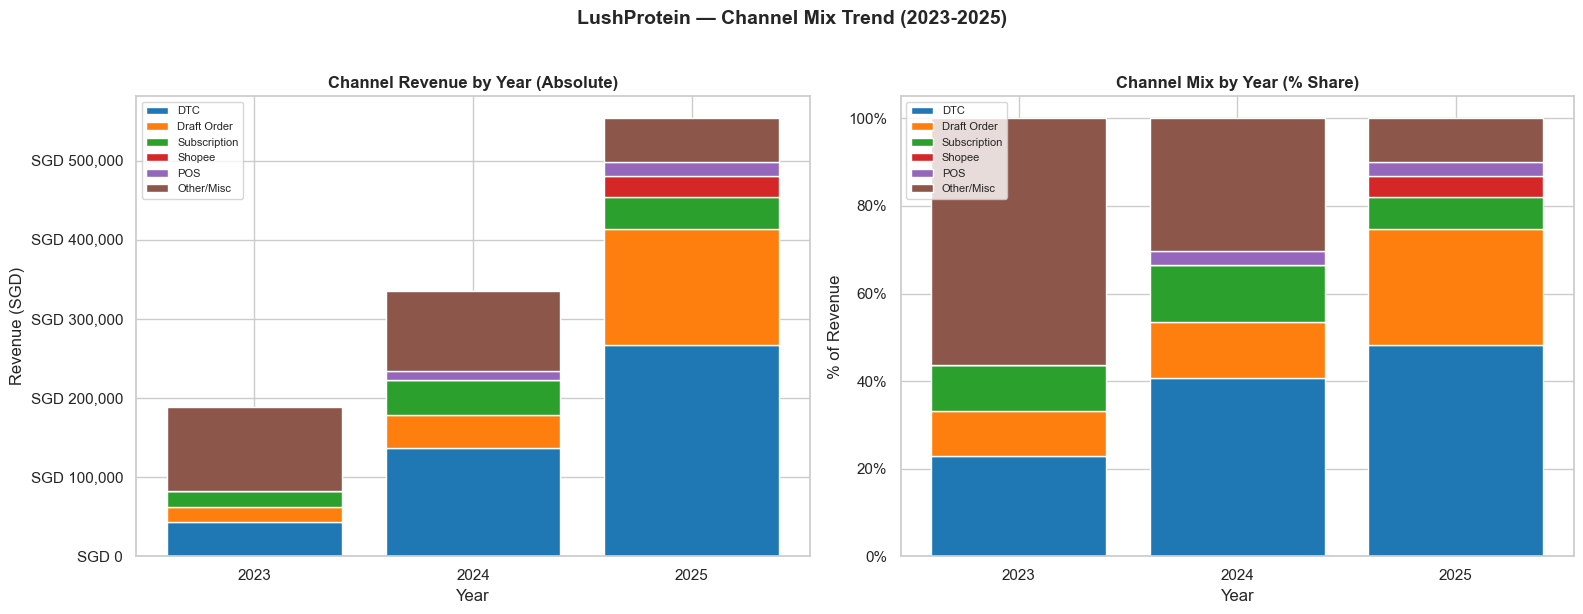

In [44]:
# ── Channel Mix Trend by Year (2023-2025, all SKUs) ───────────────────────────
channel_year = (
    so_recent.groupby(['channel_final', 'order_year'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

channel_year_pivot = channel_year.pivot(
    index='channel_final', columns='order_year', values='revenue'
).fillna(0)
channel_year_pivot = channel_year_pivot.loc[channel_order]

print('Channel Revenue by Year (2023-2025):')
display(channel_year_pivot.style.format('SGD {:,.0f}'))

# % share by year
channel_year_pct = channel_year_pivot.div(channel_year_pivot.sum(axis=0), axis=1)
print('\n% Share by Year:')
display(channel_year_pct.style.format('{:.1%}'))

# ── Chart: Channel mix trend (stacked bar, absolute + % share) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

years = channel_year_pivot.columns.tolist()
x_pos = range(len(years))
palette = sns.color_palette('tab10', len(channel_order))

# Panel 1: Absolute revenue (stacked bar)
ax1 = axes[0]
bottom = pd.Series(0, index=years)
for i, ch in enumerate(channel_order):
    ax1.bar(x_pos, channel_year_pivot.loc[ch], bottom=bottom, label=ch, color=palette[i])
    bottom += channel_year_pivot.loc[ch]
ax1.set_title('Channel Revenue by Year (Absolute)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue (SGD)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(y) for y in years])
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'SGD {x:,.0f}'))
ax1.legend(fontsize=8)

# Panel 2: % share (stacked bar, 100%)
ax2 = axes[1]
bottom = pd.Series(0, index=years)
for i, ch in enumerate(channel_order):
    vals = channel_year_pct.loc[ch] * 100
    ax2.bar(x_pos, vals, bottom=bottom, label=ch, color=palette[i])
    bottom += vals
ax2.set_title('Channel Mix by Year (% Share)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('% of Revenue')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(y) for y in years])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=8)

plt.suptitle('LushProtein — Channel Mix Trend (2023-2025)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'channel_mix_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**A note on the "Other/Misc" channel**: This category combines three minor sources from the original channel data — miscellaneous numeric `Source` codes that didn't match any identifiable platform (SGD 140,817, the largest component), `matrixify app` rows representing bulk-imported/migrated historical orders (SGD 121,198, concentrated in 2023-2024 and near-zero by 2025), and TikTok Shop orders (SGD 648, negligible). Together these account for roughly 24% of 2023-2025 revenue (SGD 262,662 of SGD 1,077,027). SKUs with unusually high `Other/Misc` shares — such as `PRI-UNF-1KG-V1` (45.7%) and `COL-UNF-300G-V1` (41.9%) — may warrant further investigation to confirm whether this reflects genuine sales through unidentified channels or residual data-migration artifacts.

---
## 10. Looking into Geographical Segments

In [45]:
# ── Category Revenue by Country (SG vs MY vs Others) ──────────────────────────
def country_group(c):
    if c == 'singapore':
        return 'Singapore'
    elif c == 'malaysia':
        return 'Malaysia'
    else:
        return 'Others'

so_recent['country_group'] = so_recent['Shipping: Country'].apply(country_group)

cat_country = (
    so_recent[so_recent['category'].isin(top10_categories_recent)]
    .groupby(['category', 'country_group'])
    .agg(revenue=('line_revenue', 'sum'))
    .reset_index()
)

cat_country_pivot = cat_country.pivot(
    index='category', columns='country_group', values='revenue'
).fillna(0)
cat_country_pivot = cat_country_pivot.loc[top10_categories_recent]
cat_country_pivot = cat_country_pivot[['Singapore','Malaysia','Others']]
cat_country_pivot['Total'] = cat_country_pivot.sum(axis=1)

for c in ['Singapore','Malaysia','Others']:
    cat_country_pivot[f'{c}_%'] = cat_country_pivot[c] / cat_country_pivot['Total']

print('Category Revenue by Country (2023-2025) — % of category total by country:')
display(cat_country_pivot.style.format({
    'Singapore':'{:,.0f}', 'Malaysia':'{:,.0f}', 'Others':'{:,.0f}', 'Total':'{:,.0f}',
    'Singapore_%':'{:.1%}', 'Malaysia_%':'{:.1%}', 'Others_%':'{:.1%}',
}).set_caption('Revenue values in SGD'))

Category Revenue by Country (2023-2025) — % of category total by country:


country_group,Singapore,Malaysia,Others,Total,Singapore_%,Malaysia_%,Others_%
category,,,,,,,
Clear Protein,"164,400","60,635","25,565","250,601",65.6%,24.2%,10.2%
Lean Protein,"105,703","60,692","31,052","197,448",53.5%,30.7%,15.7%
Better Whey,"90,644","50,033","2,537","143,215",63.3%,34.9%,1.8%
Elite Protein,"83,292","26,204","2,028","111,524",74.7%,23.5%,1.8%
Collagen,"30,591","45,746","3,593","79,929",38.3%,57.2%,4.5%
Prime Whey,"41,645","24,705","1,899","68,249",61.0%,36.2%,2.8%
Plant Protein,"39,698","25,298","1,866","66,861",59.4%,37.8%,2.8%
Soy Protein,"15,166","21,285",968,"37,418",40.5%,56.9%,2.6%
Accessories,"23,493","7,810","4,421","35,724",65.8%,21.9%,12.4%


In [46]:
# ── Clear Protein: Quarterly trend by Country (is the decline global?) ───────
def country_group(c):
    if c == 'singapore':
        return 'Singapore'
    elif c == 'malaysia':
        return 'Malaysia'
    else:
        return 'Others'

so_13q = so_retail[so_retail['order_year'].isin([2023, 2024, 2025, 2026])].copy()
so_13q['year_quarter'] = so_13q['Processed At'].dt.to_period('Q').astype(str)

clear_country_quarter = (
    so_13q[(so_13q['category']=='Clear Protein')]
    .assign(country_group=lambda d: d['Shipping: Country'].apply(country_group))
    .groupby(['country_group','year_quarter'])
    .agg(revenue=('line_revenue','sum'))
    .reset_index()
)

clear_country_pivot = clear_country_quarter.pivot(
    index='country_group', columns='year_quarter', values='revenue'
).fillna(0)

quarters_sorted = sorted(clear_country_pivot.columns)
clear_country_pivot = clear_country_pivot.reindex(['Singapore','Malaysia','Others'])

print('Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):')
display(clear_country_pivot.style.format('SGD {:,.0f}'))


Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):


year_quarter,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
country_group,,,,,,,,,,
Singapore,SGD 712,"SGD 7,883","SGD 13,992","SGD 20,536","SGD 12,661","SGD 14,512","SGD 42,244","SGD 31,081","SGD 20,779","SGD 20,056"
Malaysia,SGD 428,SGD 691,"SGD 3,878","SGD 9,912","SGD 2,730","SGD 6,479","SGD 7,763","SGD 15,381","SGD 13,374","SGD 17,843"
Others,SGD 0,SGD 0,SGD 0,"SGD 9,003","SGD 1,521",SGD 969,"SGD 1,063","SGD 5,146","SGD 7,863","SGD 2,485"


In [47]:
# ── Lean Protein: Quarterly trend by Country (is the decline global?) ───────
def country_group(c):
    if c == 'singapore':
        return 'Singapore'
    elif c == 'malaysia':
        return 'Malaysia'
    else:
        return 'Others'

so_13q = so_retail[so_retail['order_year'].isin([2023, 2024, 2025, 2026])].copy()
so_13q['year_quarter'] = so_13q['Processed At'].dt.to_period('Q').astype(str)

clear_country_quarter = (
    so_13q[(so_13q['category']=='Lean Protein')]
    .assign(country_group=lambda d: d['Shipping: Country'].apply(country_group))
    .groupby(['country_group','year_quarter'])
    .agg(revenue=('line_revenue','sum'))
    .reset_index()
)

clear_country_pivot = clear_country_quarter.pivot(
    index='country_group', columns='year_quarter', values='revenue'
).fillna(0)

quarters_sorted = sorted(clear_country_pivot.columns)
clear_country_pivot = clear_country_pivot.reindex(['Singapore','Malaysia','Others'])

print('Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):')
display(clear_country_pivot.style.format('SGD {:,.0f}'))


Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):


year_quarter,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
country_group,,,,,,,,
Singapore,"SGD 4,387","SGD 6,415","SGD 11,603","SGD 8,575","SGD 22,326","SGD 27,568","SGD 24,828","SGD 24,429"
Malaysia,"SGD 1,889","SGD 3,867","SGD 1,594","SGD 6,837","SGD 12,691","SGD 17,596","SGD 16,218","SGD 25,744"
Others,SGD 96,"SGD 1,338",SGD 0,SGD 361,"SGD 2,073","SGD 11,180","SGD 16,005","SGD 7,527"


In [48]:
# ── Collagen: Quarterly trend by Country (is the decline global?) ───────
def country_group(c):
    if c == 'singapore':
        return 'Singapore'
    elif c == 'malaysia':
        return 'Malaysia'
    else:
        return 'Others'

so_13q = so_retail[so_retail['order_year'].isin([2023, 2024, 2025, 2026])].copy()
so_13q['year_quarter'] = so_13q['Processed At'].dt.to_period('Q').astype(str)

clear_country_quarter = (
    so_13q[(so_13q['category']=='Collagen')]
    .assign(country_group=lambda d: d['Shipping: Country'].apply(country_group))
    .groupby(['country_group','year_quarter'])
    .agg(revenue=('line_revenue','sum'))
    .reset_index()
)

clear_country_pivot = clear_country_quarter.pivot(
    index='country_group', columns='year_quarter', values='revenue'
).fillna(0)

quarters_sorted = sorted(clear_country_pivot.columns)
clear_country_pivot = clear_country_pivot.reindex(['Singapore','Malaysia','Others'])

print('Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):')
display(clear_country_pivot.style.format('SGD {:,.0f}'))


Clear Protein Revenue by Country, Quarterly (2023 Q1 - 2026 Q1):


year_quarter,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
country_group,,,,,,,,,,,,,
Singapore,"SGD 3,008","SGD 1,542","SGD 1,351","SGD 1,389","SGD 1,986","SGD 1,810","SGD 3,521","SGD 4,192","SGD 2,939","SGD 2,838","SGD 3,485","SGD 2,531","SGD 2,318"
Malaysia,"SGD 3,726","SGD 2,478","SGD 1,991","SGD 2,890","SGD 2,320","SGD 3,730","SGD 6,401","SGD 3,212","SGD 3,588","SGD 4,093","SGD 5,030","SGD 6,287","SGD 7,812"
Others,SGD 88,SGD 216,SGD 108,SGD 117,SGD 0,SGD 0,SGD 817,SGD 462,SGD 319,SGD 243,SGD 417,SGD 804,"SGD 1,167"


## Category Revenue by Country — Insights (2023 Q1 - 2026 Q1)

**1. Collagen and Soy Protein remain the *only two* categories where Malaysia is the majority source of revenue — and Collagen's Malaysia lead has grown.** Collagen: **57.2% from Malaysia** (vs. 38.3% Singapore) — up from the earlier 53.7%/42.1% split. Soy Protein remains essentially unchanged: **56.9% Malaysia** vs. 40.5% Singapore. Every other category remains Singapore-majority.

**2. Elite Protein remains Singapore's *most* concentrated category** at **74.7% from Singapore** (unchanged) — vs. 65.6% for Clear Protein and 65.8% for Accessories. Elite Protein is almost exclusively a Singapore phenomenon — Malaysia (23.5%) and other markets (1.8%) barely register. Aligns with the narrative of the exclusive product for Singapore's professional athletes.

**3. Clear Protein's Singapore concentration (65.6%) continues to explain its boom-bust quarterly pattern** — Singapore peaked at SGD 42,244 in 2025 Q2 (down from the earlier-estimated ~SGD 47,764 once outliers were removed) before declining to SGD ~20k by 2025 Q4/2026 Q1. Malaysia's Clear Protein revenue, by contrast, has grown steadily to SGD 17,843 by 2026 Q1 — its highest quarter yet.

**4. Collagen is in a broad-based growth phase across *both* markets, and Malaysia has just overtaken Singapore in the latest quarter.** From 2024 Q2 to 2025 Q2, **both Singapore and Malaysia roughly 4-5x'd their Collagen revenue** (Singapore: SGD 4,387 → 22,326; Malaysia: SGD 1,889 → 12,691). By **2026 Q1, Malaysia (SGD 25,744) has edged ahead of Singapore (SGD 24,429)** for the first time — meaning Collagen's aggregate 57.2% Malaysia-majority isn't a static historical fact, but a **gap that's widening in Malaysia's favor in the most recent quarter**, even as Singapore's Collagen revenue also grows in absolute terms.

**5. Creatine's Malaysia-majority is driven by a sustained Malaysia growth trajectory, while Singapore has been flat.** Malaysia's Creatine revenue grew from SGD 2,320 (2024 Q1) to **SGD 7,812 (2026 Q1)** — a **+237% increase** over 9 quarters, with consistent quarter-on-quarter growth in 6 of the last 7 quarters. Singapore's Creatine revenue, meanwhile, has been **essentially flat** (SGD 1,986 → 2,318), peaking briefly at SGD 4,192 in 2024 Q4 before settling back down. As a result, **Malaysia's share of Creatine has been steadily *increasing* over time** — Malaysia already led in 2024 Q1 (54% vs. 46%) and by 2026 Q1 leads by more than 3:1.

---

**Overall narrative**: The aggregate country-mix table (#1-#3) tells only part of the story. The quarterly breakdowns reveal that **Collagen and Creatine — LushProtein's two "Malaysia-majority" categories — are following different growth patterns**: Collagen is growing in *both* markets with Malaysia just barely pulling ahead, while Creatine's Malaysia-majority reflects **sustained, compounding Malaysia-specific growth against a flat Singapore base**. Combined with Clear Protein's Singapore-driven boom-bust (#3) and Elite Protein's Singapore exclusivity (#2), there's a case that **Malaysia represents LushProtein's strongest underlying growth market for Collagen and Creatine specifically** — worth considering for targeted marketing/inventory investment in Malaysia for these two categories.

In [49]:
# ── Decile Composition by Country (2023-2025) ────────────────────────────────
# Determine each customer's primary shipping country (mode)
cust_country = (
    so_recent.groupby('Customer: ID')['Shipping: Country']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'Shipping: Country': 'primary_country'})
)
cust_country['country_group'] = cust_country['primary_country'].apply(country_group)

cust_decile_country = customer_revenue.merge(cust_country[['Customer: ID','country_group']], on='Customer: ID')

# # of Customers
decile_country_counts = (
    cust_decile_country.groupby(['decile','country_group'], observed=True)
    .size()
    .unstack(fill_value=0)[['Singapore','Malaysia','Others']]
)

# % of Customers
decile_country_pct = decile_country_counts.div(decile_country_counts.sum(axis=1), axis=0)

# % of Revenue
decile_country_revenue_sum = (
    cust_decile_country.groupby(['decile','country_group'], observed=True)['total_revenue']
    .sum()
    .unstack(fill_value=0)[['Singapore','Malaysia','Others']]
)
decile_country_revenue_pct = decile_country_revenue_sum.div(decile_country_revenue_sum.sum(axis=1), axis=0)

# Avg Revenue per Customer
avg_revenue_per_cust = decile_country_revenue_sum / decile_country_counts

# ── Combined View ──────────────────────────────────────────────────────────
combined = pd.concat(
    {
        '# Customers': decile_country_counts,
        '% of Customers': decile_country_pct,
        '% of Revenue': decile_country_revenue_pct,
        'Avg Revenue/Cust': avg_revenue_per_cust,
    },
    axis=1
)

print('Decile x Country — Combined View (2023-2025):')
display(combined.style.format({
    ('# Customers','Singapore'):'{:,.0f}', ('# Customers','Malaysia'):'{:,.0f}', ('# Customers','Others'):'{:,.0f}',
    ('% of Customers','Singapore'):'{:.1%}', ('% of Customers','Malaysia'):'{:.1%}', ('% of Customers','Others'):'{:.1%}',
    ('% of Revenue','Singapore'):'{:.1%}', ('% of Revenue','Malaysia'):'{:.1%}', ('% of Revenue','Others'):'{:.1%}',
    ('Avg Revenue/Cust','Singapore'):'SGD {:,.0f}', ('Avg Revenue/Cust','Malaysia'):'SGD {:,.0f}', ('Avg Revenue/Cust','Others'):'SGD {:,.0f}',
}))

Decile x Country — Combined View (2023-2025):


In [50]:
# ── D1: Revenue distribution by country (checking for whale concentration) ───
d1_data = cust_decile_country[cust_decile_country['decile'] == 'D1']
print(d1_data.groupby('country_group', observed=True)['total_revenue'].describe().to_string())

               count     mean      std    min    25%    50%      75%       max
country_group                                                                 
Malaysia      231.00   743.45   712.67 314.24 389.39 513.28   762.08  5,554.88
Others         17.00 1,239.48 2,024.71 311.72 318.65 480.19 1,307.76  8,756.81
Singapore     384.00   895.68 1,445.06 312.06 399.30 559.81   834.74 21,601.80


In [51]:
# ── AOV & Order Frequency by Country (2023-2025) ──────────────────────────────
so_recent_country = so_recent.copy()
so_recent_country['country_group'] = so_recent_country['Shipping: Country'].apply(country_group)

country_order_stats = (
    so_recent_country.groupby(['country_group', 'ID'])
    .agg(order_revenue=('line_revenue', 'sum'))
    .reset_index()
)

country_summary = (
    country_order_stats.groupby('country_group')
    .agg(
        n_orders=('ID', 'nunique'),
        total_revenue=('order_revenue', 'sum'),
    )
)
country_summary['AOV'] = country_summary['total_revenue'] / country_summary['n_orders']

# Order frequency: orders per customer
country_customer_orders = (
    so_recent_country.groupby(['country_group', 'Customer: ID'])
    .agg(n_orders=('ID', 'nunique'))
    .reset_index()
)
order_freq = (
    country_customer_orders.groupby('country_group')
    .agg(n_customers=('Customer: ID', 'nunique'), total_orders=('n_orders', 'sum'))
)
order_freq['AOF'] = order_freq['total_orders'] / order_freq['n_customers']

country_summary = country_summary.join(order_freq[['n_customers', 'AOF']])
country_summary = country_summary.reindex(['Singapore', 'Malaysia', 'Others'])

print('AOV & Order Frequency by Country (2023-2025):')
display(country_summary.style.format({
    'n_orders':'{:,.0f}', 'total_revenue':'SGD {:,.0f}', 'AOF':'SGD {:,.2f}',
    'n_customers':'{:,.0f}', 'AOF':'{:.2f}',
}))

AOV & Order Frequency by Country (2023-2025):


,n_orders,total_revenue,AOV,n_customers,AOF
country_group,,,,,
Singapore,"6,032","SGD 640,767",106.227926,"3,106",1.94
Malaysia,"5,044","SGD 356,052",70.589255,"2,527",2.00
Others,914,"SGD 80,208",87.755394,782,1.17


In [52]:
# ── AOV & AOF (Order Frequency) by Country (2023-2026) ────────────────────────
so_2023_26 = so_retail[so_retail['order_year'].isin([2023, 2024, 2025, 2026])].copy()
so_2023_26['country_group'] = so_2023_26['Shipping: Country'].apply(country_group)

country_order_stats = (
    so_2023_26.groupby(['country_group', 'ID'])
    .agg(order_revenue=('line_revenue', 'sum'))
    .reset_index()
)

country_summary = (
    country_order_stats.groupby('country_group')
    .agg(
        n_orders=('ID', 'nunique'),
        total_revenue=('order_revenue', 'sum'),
    )
)
country_summary['AOV'] = country_summary['total_revenue'] / country_summary['n_orders']

country_customer_orders = (
    so_2023_26.groupby(['country_group', 'Customer: ID'])
    .agg(n_orders=('ID', 'nunique'))
    .reset_index()
)
order_freq = (
    country_customer_orders.groupby('country_group')
    .agg(n_customers=('Customer: ID', 'nunique'), total_orders=('n_orders', 'sum'))
)
order_freq['AOF'] = order_freq['total_orders'] / order_freq['n_customers']

country_summary = country_summary.join(order_freq[['n_customers', 'AOF']])
country_summary = country_summary.reindex(['Singapore', 'Malaysia', 'Others'])

print('AOV & AOF by Country (2023-2026):')
display(country_summary.style.format({
    'n_orders':'{:,.0f}', 'total_revenue':'SGD {:,.0f}', 'AOV':'SGD {:,.2f}',
    'n_customers':'{:,.0f}', 'AOF':'{:.2f}',
}))

AOV & AOF by Country (2023-2026):


,n_orders,total_revenue,AOV,n_customers,AOF
country_group,,,,,
Singapore,"6,724","SGD 737,805",SGD 109.73,"3,399",1.98
Malaysia,"5,878","SGD 423,921",SGD 72.12,"3,055",1.92
Others,"1,059","SGD 94,782",SGD 89.50,870,1.22


## AOV & Order Frequency by Country (2023-2026)

**Singapore's average order value (SGD 109.73) is ~52% higher than Malaysia's (SGD 72.12), while order frequency (AOF) is nearly identical** (1.98 vs. 1.92 orders/customer). This confirms that the country differences identified earlier are primarily about **basket composition, not purchase frequency** — Singapore customers buy fewer, larger-value items per order (consistent with its concentration in premium categories like Elite Protein and Clear Protein), while Malaysia's lower AOV reflects its different category mix (Collagen, Soy, Creatine), not less-frequent shopping.

"Others" markets show the **lowest AOF (1.22)** — around 60% of Singapore/Malaysia's frequency — consistent with these smaller/newer markets having a higher proportion of one-time buyers. Including 2026 (partial year) left all figures essentially unchanged from the 2023-2025 baseline, confirming these patterns are stable rather than year-specific.

---
## 11. Product Bundling Analysis 

In [53]:
# ── Market Basket Analysis: Association Rules (2023-2025) ────────────────────
from mlxtend.frequent_patterns import apriori, association_rules

# Use full-SKU rows only (exclude category-fallback codes)
basket_data = so_recent2[so_recent2['sku'].str.contains('-', na=False)]

# Build order x SKU matrix (1 if SKU present in order, 0 otherwise)
basket = (
    basket_data.groupby(['ID', 'sku'])['Line: Quantity']
    .sum()
    .unstack(fill_value=0)
)
basket_bool = (basket > 0)

print(f'Orders in basket: {basket_bool.shape[0]:,}')
print(f'Unique SKUs: {basket_bool.shape[1]:,}')

# ── Apriori: find frequent itemsets ───────────────────────────────────────────
frequent_itemsets = apriori(basket_bool, min_support=0.01, use_colnames=True)
print(f'\nFrequent itemsets found: {len(frequent_itemsets):,}')

# ── Association rules (focus on lift) ─────────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

# Keep only 1-to-1 rules for readability, with reasonable support
rules_simple = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(len) == 1) &
    (rules['support'] >= 0.005)
].copy()

rules_simple['antecedent'] = rules_simple['antecedents'].apply(lambda x: list(x)[0])
rules_simple['consequent'] = rules_simple['consequents'].apply(lambda x: list(x)[0])

print(f'\nTop 15 SKU Pairs by Lift (support >= 0.5%):')
display(
    rules_simple[['antecedent', 'consequent', 'support', 'confidence', 'lift']]
    .head(15)
    .style.format({'support': '{:.2%}', 'confidence': '{:.1%}', 'lift': '{:.2f}'})
)

Orders in basket: 11,902
Unique SKUs: 66

Frequent itemsets found: 55

Top 15 SKU Pairs by Lift (support >= 0.5%):


,antecedent,consequent,support,confidence,lift
14,CLEAR-PEA-25G-V2,CLEAR-GRA-25G-V2,3.28%,83.3%,22.49
15,CLEAR-GRA-25G-V2,CLEAR-PEA-25G-V2,3.28%,88.4%,22.49
33,LEAN-TAR-40G-V1,LEAN-THA-40G-V1,5.83%,84.1%,11.46
32,LEAN-THA-40G-V1,LEAN-TAR-40G-V1,5.83%,79.4%,11.46
19,CLEAR-GRA-25G-V2,LEAN-THA-40G-V1,1.34%,36.3%,4.94
18,LEAN-THA-40G-V1,CLEAR-GRA-25G-V2,1.34%,18.3%,4.94
17,CLEAR-GRA-25G-V2,LEAN-TAR-40G-V1,1.25%,33.8%,4.87
16,LEAN-TAR-40G-V1,CLEAR-GRA-25G-V2,1.25%,18.1%,4.87
24,CLEAR-PEA-25G-V2,LEAN-TAR-40G-V1,1.28%,32.5%,4.69
25,LEAN-TAR-40G-V1,CLEAR-PEA-25G-V2,1.28%,18.4%,4.69


In [54]:
# ── Multi-item (2→1) Association Rules ────────────────────────────────────────
rules_multi = rules[
    (rules['antecedents'].apply(len) == 2) &
    (rules['consequents'].apply(len) == 1) &
    (rules['support'] >= 0.005)
].copy()

rules_multi['antecedent'] = rules_multi['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
rules_multi['consequent'] = rules_multi['consequents'].apply(lambda x: list(x)[0])

print(f'Top 15 (2-item antecedent → 1-item) Rules by Lift:')
display(
    rules_multi[['antecedent', 'consequent', 'support', 'confidence', 'lift']]
    .sort_values('lift', ascending=False)
    .head(15)
    .style.format({'support': '{:.2%}', 'confidence': '{:.1%}', 'lift': '{:.2f}'})
)

Top 15 (2-item antecedent → 1-item) Rules by Lift:


,antecedent,consequent,support,confidence,lift
34,ACC-SHK-V2 + CLEAR-PEA-25G-V2,CLEAR-GRA-25G-V2,2.15%,95.5%,25.78
36,ACC-SHK-V2 + CLEAR-GRA-25G-V2,CLEAR-PEA-25G-V2,2.15%,95.9%,24.38
46,CLEAR-PEA-25G-V2 + LEAN-TAR-40G-V1,CLEAR-GRA-25G-V2,1.15%,90.1%,24.33
52,CLEAR-PEA-25G-V2 + LEAN-THA-40G-V1,CLEAR-GRA-25G-V2,1.19%,89.3%,24.10
48,CLEAR-GRA-25G-V2 + LEAN-TAR-40G-V1,CLEAR-PEA-25G-V2,1.15%,91.9%,23.38
53,CLEAR-GRA-25G-V2 + LEAN-THA-40G-V1,CLEAR-PEA-25G-V2,1.19%,88.7%,22.57
41,ACC-SHK-V2 + LEAN-THA-40G-V1,LEAN-TAR-40G-V1,4.11%,92.1%,13.29
42,ACC-SHK-V2 + LEAN-TAR-40G-V1,LEAN-THA-40G-V1,4.11%,95.5%,13.01
60,CLEAR-GRA-25G-V2 + LEAN-TAR-40G-V1,LEAN-THA-40G-V1,1.12%,89.3%,12.16
59,CLEAR-GRA-25G-V2 + LEAN-THA-40G-V1,LEAN-TAR-40G-V1,1.12%,83.1%,11.99


In [55]:
# ── Verify: "Starter Kit" combination support ─────────────────────────────────
starter_kit_items = ['ACC-SHK-V2', 'CLEAR-PEA-25G-V2', 'CLEAR-GRA-25G-V2',
                      'LEAN-TAR-40G-V1', 'LEAN-THA-40G-V1']

combos_to_check = {
    'Shaker + both Lean sachets': ['ACC-SHK-V2', 'LEAN-TAR-40G-V1', 'LEAN-THA-40G-V1'],
    'Shaker + both Clear sachets': ['ACC-SHK-V2', 'CLEAR-PEA-25G-V2', 'CLEAR-GRA-25G-V2'],
    'Both Lean + both Clear sachets': ['LEAN-TAR-40G-V1', 'LEAN-THA-40G-V1', 'CLEAR-PEA-25G-V2', 'CLEAR-GRA-25G-V2'],
    'All 5 (Shaker + 2 Lean + 2 Clear sachets)': starter_kit_items,
}

n_total_orders = basket_bool.shape[0]
for name, items in combos_to_check.items():
    n_orders_with_combo = basket_bool[items].all(axis=1).sum()
    print(f'{name}: {n_orders_with_combo:,} orders ({n_orders_with_combo/n_total_orders:.2%})')

Shaker + both Lean sachets: 489 orders (4.11%)
Shaker + both Clear sachets: 256 orders (2.15%)
Both Lean + both Clear sachets: 126 orders (1.06%)
All 5 (Shaker + 2 Lean + 2 Clear sachets): 70 orders (0.59%)


In [56]:
# ── Sequential Analysis: Trial Sachet → Full-Size Upgrade ─────────────────────
sachet_skus = ['LEAN-THA-40G-V1', 'LEAN-TAR-40G-V1', 'CLEAR-PEA-25G-V2', 'CLEAR-GRA-25G-V2']
fullsize_skus = ['LEAN-THA-1KG-V1', 'LEAN-TAR-1KG-V1', 'CLEAR-PEA-500G-V2', 'CLEAR-GRA-500G-V2']

basket_data = so_recent2[so_recent2['sku'].str.contains('-', na=False)].copy()

# First order date per customer
first_order_date = (
    basket_data.groupby('Customer: ID')['Processed At'].min()
    .rename('first_order_date')
)

# SKUs purchased in each customer's FIRST order (by date)
order_dates = basket_data.groupby(['Customer: ID', 'ID'])['Processed At'].min().reset_index()
order_dates = order_dates.merge(first_order_date, on='Customer: ID')
first_orders = order_dates[order_dates['Processed At'] == order_dates['first_order_date']]

first_order_skus = (
    basket_data[basket_data['ID'].isin(first_orders['ID'])]
    .groupby('Customer: ID')['sku'].apply(set)
)

# Customers whose FIRST order contained at least one trial sachet
sachet_first_buyers = first_order_skus[first_order_skus.apply(lambda s: bool(s & set(sachet_skus)))].index

# Customers whose FIRST order did NOT contain a sachet (comparison group)
non_sachet_first_buyers = first_order_skus[~first_order_skus.apply(lambda s: bool(s & set(sachet_skus)))].index

# Did the customer EVER (any order) buy a full-size SKU?
customer_skus = basket_data.groupby('Customer: ID')['sku'].apply(set)
bought_fullsize = customer_skus.apply(lambda s: bool(s & set(fullsize_skus)))

# For sachet-first buyers: did they buy full-size in a LATER order (not the first)?
later_order_skus = (
    basket_data[~basket_data['ID'].isin(first_orders['ID'])]
    .groupby('Customer: ID')['sku'].apply(set)
)
bought_fullsize_later = later_order_skus.reindex(sachet_first_buyers).apply(
    lambda s: bool(s & set(fullsize_skus)) if isinstance(s, set) else False
)

print(f'Customers whose first order included a trial sachet: {len(sachet_first_buyers):,}')
print(f'  -> of these, % who later bought full-size in a subsequent order: {bought_fullsize_later.mean():.1%}')
print()
print(f'Customers whose first order did NOT include a trial sachet: {len(non_sachet_first_buyers):,}')
print(f'  -> of these, overall % who bought full-size (any order): {bought_fullsize.reindex(non_sachet_first_buyers).mean():.1%}')

Customers whose first order included a trial sachet: 983
  -> of these, % who later bought full-size in a subsequent order: 13.9%

Customers whose first order did NOT include a trial sachet: 5,297
  -> of these, overall % who bought full-size (any order): 44.4%


In [57]:
# ── Sequential Analysis (v2): Full-Size Purchase in LATER Orders, Both Groups ──
# Fix: check "later orders" (excluding first) for BOTH groups, for apples-to-apples comparison

later_order_skus_all = (
    basket_data[~basket_data['ID'].isin(first_orders['ID'])]
    .groupby('Customer: ID')['sku'].apply(set)
)

def bought_fullsize_in_later(cust_ids):
    later_skus = later_order_skus_all.reindex(cust_ids)
    return later_skus.apply(lambda s: bool(s & set(fullsize_skus)) if isinstance(s, set) else False)

sachet_later_rate = bought_fullsize_in_later(sachet_first_buyers)
non_sachet_later_rate = bought_fullsize_in_later(non_sachet_first_buyers)

print(f'Customers whose first order included a trial sachet: {len(sachet_first_buyers):,}')
print(f'  -> % who bought full-size in a LATER order: {sachet_later_rate.mean():.1%}')
print()
print(f'Customers whose first order did NOT include a trial sachet: {len(non_sachet_first_buyers):,}')
print(f'  -> % who bought full-size in a LATER order: {non_sachet_later_rate.mean():.1%}')
print()

# Also: how many customers in each group placed ANY later order at all? (repeat-purchase rate)
sachet_any_later = first_order_skus.reindex(sachet_first_buyers).index.isin(later_order_skus_all.index).mean()
non_sachet_any_later = first_order_skus.reindex(non_sachet_first_buyers).index.isin(later_order_skus_all.index).mean()

print(f'% of sachet-first customers who placed ANY later order (repeat rate): {sachet_any_later:.1%}')
print(f'% of non-sachet-first customers who placed ANY later order (repeat rate): {non_sachet_any_later:.1%}')

Customers whose first order included a trial sachet: 983
  -> % who bought full-size in a LATER order: 13.9%

Customers whose first order did NOT include a trial sachet: 5,297
  -> % who bought full-size in a LATER order: 12.9%

% of sachet-first customers who placed ANY later order (repeat rate): 19.6%
% of non-sachet-first customers who placed ANY later order (repeat rate): 30.7%


In [58]:
# ── Direct conditional rate: P(bought full-size later | placed any later order) ──
sachet_returned = first_order_skus.reindex(sachet_first_buyers).index.isin(later_order_skus_all.index)
non_sachet_returned = first_order_skus.reindex(non_sachet_first_buyers).index.isin(later_order_skus_all.index)

sachet_returners = pd.Index(sachet_first_buyers)[sachet_returned]
non_sachet_returners = pd.Index(non_sachet_first_buyers)[non_sachet_returned]

sachet_conditional = bought_fullsize_in_later(sachet_returners).mean()
non_sachet_conditional = bought_fullsize_in_later(non_sachet_returners).mean()

print(f'Among sachet-first returners ({len(sachet_returners):,}): {sachet_conditional:.1%} bought full-size later')
print(f'Among non-sachet-first returners ({len(non_sachet_returners):,}): {non_sachet_conditional:.1%} bought full-size later')

Among sachet-first returners (193): 71.0% bought full-size later
Among non-sachet-first returners (1,624): 42.0% bought full-size later


In [59]:
# ── Flavor-Specific Sequential Analysis: Same-Flavor Upgrade ──────────────────
flavor_pairs = {
    'LEAN-THA-40G-V1': 'LEAN-THA-1KG-V1',
    'LEAN-TAR-40G-V1': 'LEAN-TAR-1KG-V1',
    'CLEAR-PEA-25G-V2': 'CLEAR-PEA-500G-V2',
    'CLEAR-GRA-25G-V2': 'CLEAR-GRA-500G-V2',
}

results = []
for sachet_sku, fullsize_sku in flavor_pairs.items():
    # Customers whose first order contained THIS specific sachet
    cust_with_this_sachet = first_order_skus[first_order_skus.apply(lambda s: sachet_sku in s)].index

    # Of these, who returned at all?
    returned_mask = pd.Index(cust_with_this_sachet).isin(later_order_skus_all.index)
    returners = pd.Index(cust_with_this_sachet)[returned_mask]

    if len(returners) == 0:
        continue

    later_skus_for_returners = later_order_skus_all.reindex(returners)

    # Same-flavor upgrade
    same_flavor_upgrade = later_skus_for_returners.apply(lambda s: fullsize_sku in s).mean()
    # Any full-size upgrade (any flavor, same category)
    any_fullsize_upgrade = later_skus_for_returners.apply(lambda s: bool(s & set(fullsize_skus))).mean()
    # Switched to OTHER flavor's full-size specifically
    other_fullsize = set(fullsize_skus) - {fullsize_sku}
    switched_flavor_upgrade = later_skus_for_returners.apply(lambda s: bool(s & other_fullsize) and fullsize_sku not in s).mean()

    results.append({
        'Sachet': sachet_sku,
        'n_returners': len(returners),
        'Same-Flavor Upgrade %': same_flavor_upgrade,
        'Any Full-Size Upgrade %': any_fullsize_upgrade,
        'Switched-Flavor Upgrade %': switched_flavor_upgrade,
    })

flavor_seq_df = pd.DataFrame(results)
print('Flavor-Specific Upgrade Behavior (among returners):')
display(flavor_seq_df.style.format({
    'n_returners': '{:,.0f}',
    'Same-Flavor Upgrade %': '{:.1%}',
    'Any Full-Size Upgrade %': '{:.1%}',
    'Switched-Flavor Upgrade %': '{:.1%}',
}))

Flavor-Specific Upgrade Behavior (among returners):


,Sachet,n_returners,Same-Flavor Upgrade %,Any Full-Size Upgrade %,Switched-Flavor Upgrade %
0,LEAN-THA-40G-V1,126,38.9%,72.2%,33.3%
1,LEAN-TAR-40G-V1,120,44.2%,75.8%,31.7%
2,CLEAR-PEA-25G-V2,67,23.9%,64.2%,40.3%
3,CLEAR-GRA-25G-V2,67,22.4%,64.2%,41.8%


## Sequential Analysis: Trial Sachets, Retention, and Flavor Discovery

**1. Trial sachets function as a self-selection filter, not a gradual upsell funnel.** Among customers whose first order included a trial sachet (40G Lean Protein or 25G Clear Protein), only **19.6%** placed a second order at all — vs. **30.7%** for customers who didn't start with a sachet. However, **among those who do return**, sachet-first customers convert to full-size at **71.0%** (n=193), compared to **42.0%** for non-sachet-first returners (n=1,624) — roughly **1.5-2x higher**. This suggests sachets pre-qualify a smaller, higher-intent group: customers who try the sachet and don't return likely decided "not for me," while the smaller subset who *do* return are disproportionately ready to commit to full-size.

**2. Among Lean Protein sachet-tasters who return, full-size upgrade rates are high (72-76%) and skew toward the *same flavor* sampled.** THA sachet-tasters: 38.9% upgrade to THA 1KG vs. 33.3% switching to TAR 1KG. TAR sachet-tasters: 44.2% upgrade to TAR 1KG vs. 31.7% switching to THA 1KG. In both cases, **same-flavor upgrade exceeds switched-flavor**, suggesting the sampled flavor often becomes the customer's preference.

**3. Clear Protein shows the opposite pattern — tasters who upgrade are nearly twice as likely to *switch* flavors as to stick with the sampled one.** PEA sachet-tasters: only 23.9% upgrade to PEA 500G, while 40.3% switch to GRA 500G. GRA sachet-tasters: 22.4% upgrade to GRA 500G, while 41.8% switch to PEA 500G. Overall upgrade rate (64.2% for both) is solid, but the flavor choice skews toward **switching**, not consistency.

**4. The Clear Protein switching pattern likely reflects the earlier market-basket finding that PEA and GRA sachets are almost always bought *together*** (lift = 22.49, the strongest pairwise association in the dataset). Many Clear Protein sachet-tasters appear to sample **both flavors simultaneously** in their first order — so their later full-size purchase reflects a genuine **preference choice after a head-to-head taste test**, rather than "switching away" from an initial choice. Lean Protein's sachet-pairing lift was notably lower (11.46), consistent with fewer Lean tasters sampling both flavors upfront, and hence a stronger same-flavor carryover into their full-size purchase.

---

**Overall narrative**: Trial sachets don't drive mass conversion (overall upgrade rate ~13%), but they **effectively filter for high-intent repeat customers** — those who return convert to full-size at 1.5-2x the baseline rate. The *flavor* outcome of that conversion depends on category: Lean Protein rewards flavor consistency (tasters tend to stick with what they sampled), while Clear Protein appears to function as a **flavor-discovery mechanism** — customers sample both flavors via the high-lift sachet pair, then choose their preferred flavor for the full-size commitment. This reframes the "Starter Kit" bundling opportunity from earlier: rather than a tool to *increase conversion rates*, formalizing the sachet+shaker bundle (especially the Clear Protein PEA+GRA pairing) could be framed as a **"flavor discovery kit"** — increasing the volume of trial-takers who go through this self-selecting, taste-test-driven path to full-size commitment.

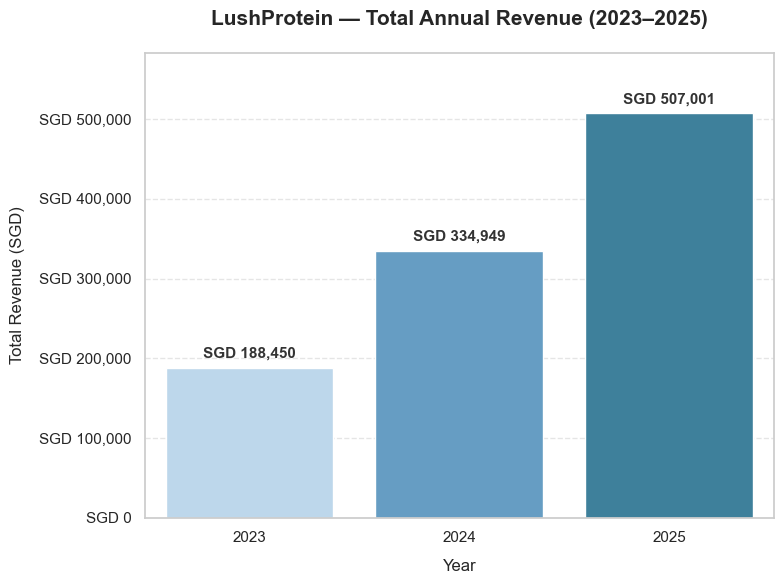

In [60]:
# ── Annual Revenue Trend (2023-2025) ──────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Ensure so_recent or so_retail exists in the workspace
if 'so_recent' not in globals():
    # If not in workspace, rebuild so_recent
    so = pd.read_parquet('medallion/silver/silver_orders.parquet')
    cf = pd.read_parquet('medallion/gold/gold_churn_features.parquet')
    co = pd.read_parquet('medallion/gold/gold_customer_orders.parquet')
    
    EXCLUDED_B2B_CUSTOMERS = {'7574631284991'}
    retail_customers = set(cf['customer_id']) - EXCLUDED_B2B_CUSTOMERS
    so_retail = so[so['Customer: ID'].isin(retail_customers)].copy()
    
    order_channel = co[['order_id', 'channel', 'processed_at']].copy()
    order_channel['processed_at'] = pd.to_datetime(order_channel['processed_at'], errors='coerce', utc=True)
    order_channel['order_year'] = order_channel['processed_at'].dt.year
    
    so_retail = so_retail.merge(
        order_channel[['order_id', 'channel', 'order_year', 'processed_at']],
        left_on='ID', right_on='order_id', how='left'
    )
    so_retail = so_retail[so_retail['Line: Type'] == 'Line Item'].copy()
    so_retail['line_revenue'] = so_retail['Line: Price'] * so_retail['Line: Quantity']
    so_recent = so_retail[so_retail['order_year'].isin([2023, 2024, 2025])].copy()

# Create a clean dataframe for annual revenue, excluding non-representative guest placeholder account
EXCLUDED_FROM_CUSTOMER_ANALYSIS = {'7888450879743'}
so_recent_plot = so_recent[~so_recent['Customer: ID'].isin(EXCLUDED_FROM_CUSTOMER_ANALYSIS)].copy()

# Handle case-sensitivity in year column
year_col = 'order_year' if 'order_year' in so_recent_plot.columns else ('Order: Year' if 'Order: Year' in so_recent_plot.columns else 'year')
if year_col not in so_recent_plot.columns and 'Processed At' in so_recent_plot.columns:
    so_recent_plot['order_year'] = pd.to_datetime(so_recent_plot['Processed At'], errors='coerce', utc=True).dt.year
    year_col = 'order_year'
elif year_col not in so_recent_plot.columns and 'processed_at' in so_recent_plot.columns:
    so_recent_plot['order_year'] = pd.to_datetime(so_recent_plot['processed_at'], errors='coerce', utc=True).dt.year
    year_col = 'order_year'

annual_rev = (
    so_recent_plot.groupby(year_col)['line_revenue']
    .sum()
    .reset_index()
)
annual_rev.columns = ['Year', 'Revenue']
annual_rev['Year'] = annual_rev['Year'].astype(int).astype(str)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Custom palette (shades of blue)
colors = ['#B6D8F2', '#57A0D3', '#2E86AB']
sns.barplot(
    data=annual_rev,
    x='Year',
    y='Revenue',
    palette=colors,
    ax=ax,
    hue='Year',
    legend=False
)

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'SGD {x:,.0f}',
        label_type='edge',
        padding=5,
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('LushProtein — Total Annual Revenue (2023–2025)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Total Revenue (SGD)', fontsize=12, labelpad=10)

# Format y-axis as currency
ax.get_yaxis().set_major_formatter(mtick.FuncFormatter(lambda x, p: f'SGD {x:,.0f}'))

# Extend y-limit slightly to fit the labels
ax.set_ylim(0, annual_rev['Revenue'].max() * 1.15)

# Adjust grids
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()

# Save the plot
import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'total_revenue_trend_2023_2025.png', dpi=300)
plt.show()


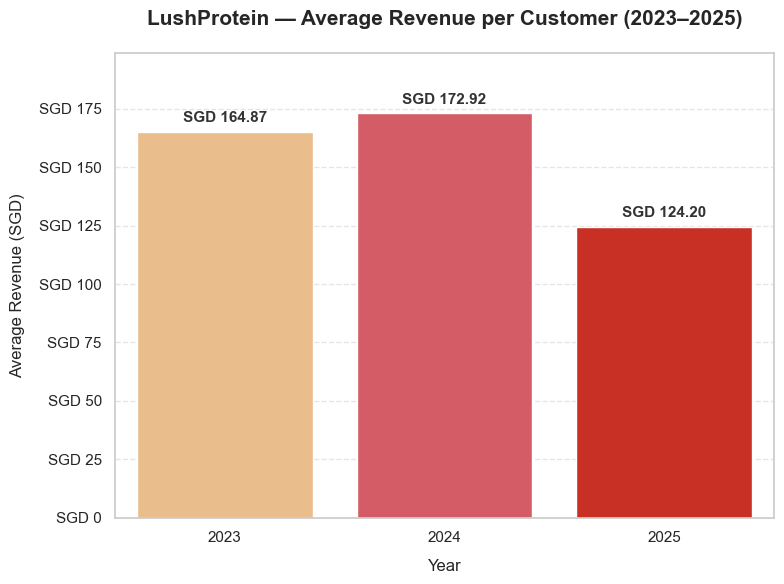

In [61]:
# ── Average Revenue per Customer (2023-2025) ──────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Ensure so_recent or so_retail exists in the workspace
if 'so_recent' not in globals():
    # If not in workspace, rebuild so_recent
    so = pd.read_parquet('medallion/silver/silver_orders.parquet')
    cf = pd.read_parquet('medallion/gold/gold_churn_features.parquet')
    co = pd.read_parquet('medallion/gold/gold_customer_orders.parquet')
    
    EXCLUDED_B2B_CUSTOMERS = {'7574631284991'}
    retail_customers = set(cf['customer_id']) - EXCLUDED_B2B_CUSTOMERS
    so_retail = so[so['Customer: ID'].isin(retail_customers)].copy()
    
    order_channel = co[['order_id', 'channel', 'processed_at']].copy()
    order_channel['processed_at'] = pd.to_datetime(order_channel['processed_at'], errors='coerce', utc=True)
    order_channel['order_year'] = order_channel['processed_at'].dt.year
    
    so_retail = so_retail.merge(
        order_channel[['order_id', 'channel', 'order_year', 'processed_at']],
        left_on='ID', right_on='order_id', how='left'
    )
    so_retail = so_retail[so_retail['Line: Type'] == 'Line Item'].copy()
    so_retail['line_revenue'] = so_retail['Line: Price'] * so_retail['Line: Quantity']
    so_recent = so_retail[so_retail['order_year'].isin([2023, 2024, 2025])].copy()

# Create a clean dataframe, excluding non-representative guest placeholder account
EXCLUDED_FROM_CUSTOMER_ANALYSIS = {'7888450879743'}
so_recent_plot = so_recent[~so_recent['Customer: ID'].isin(EXCLUDED_FROM_CUSTOMER_ANALYSIS)].copy()

# Handle case-sensitivity in year column
year_col = 'order_year' if 'order_year' in so_recent_plot.columns else ('Order: Year' if 'Order: Year' in so_recent_plot.columns else 'year')
if year_col not in so_recent_plot.columns and 'Processed At' in so_recent_plot.columns:
    so_recent_plot['order_year'] = pd.to_datetime(so_recent_plot['Processed At'], errors='coerce', utc=True).dt.year
    year_col = 'order_year'
elif year_col not in so_recent_plot.columns and 'processed_at' in so_recent_plot.columns:
    so_recent_plot['order_year'] = pd.to_datetime(so_recent_plot['processed_at'], errors='coerce', utc=True).dt.year
    year_col = 'order_year'

# Compute average revenue per customer per year
avg_rev_df = (
    so_recent_plot.groupby(year_col)
    .agg(
        total_revenue=('line_revenue', 'sum'),
        n_customers=('Customer: ID', 'nunique')
    )
    .reset_index()
)
avg_rev_df.columns = ['Year', 'Total_Revenue', 'Customers']
avg_rev_df['Avg_Revenue'] = avg_rev_df['Total_Revenue'] / avg_rev_df['Customers']
avg_rev_df['Year'] = avg_rev_df['Year'].astype(int).astype(str)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Custom palette
colors = ['#F9BE7C', '#E84855', '#E3170A']
sns.barplot(
    data=avg_rev_df,
    x='Year',
    y='Avg_Revenue',
    palette=colors,
    ax=ax,
    hue='Year',
    legend=False
)

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'SGD {x:,.2f}',
        label_type='edge',
        padding=5,
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('LushProtein — Average Revenue per Customer (2023–2025)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Average Revenue (SGD)', fontsize=12, labelpad=10)

# Format y-axis as currency
ax.get_yaxis().set_major_formatter(mtick.FuncFormatter(lambda x, p: f'SGD {x:,.0f}'))

# Extend y-limit slightly to fit the labels
ax.set_ylim(0, avg_rev_df['Avg_Revenue'].max() * 1.15)

# Adjust grids
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()

# Save the plot
import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'average_revenue_per_customer_2023_2025.png', dpi=300)
plt.show()
